# load

In [8]:
import heapq
import json
import math
import os
import random
import re
import string
import time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from IPython.display import HTML, display
from tqdm.auto import tqdm

data_dir = "/home/user/Vincent/Datasets/OCR Project Dataset/shakespeares/shakespeares"
test_filename = "romeo-and-juliet_TXT_FolgerShakespeare.txt"

bpe_filename = "/home/user/Vincent/Datasets/OCR Project Dataset/shakespeare_train_bpe.json"
train_ids_filename = "/home/user/Vincent/Datasets/OCR Project Dataset/shakespeare_train_ids.json"
test_ids_filename = "/home/user/Vincent/Datasets/OCR Project Dataset/shakespeare_test_ids.json"

vocab_size = 2048
num_merges = vocab_size - 256

train_corpus = ""
test_corpus = ""

for filename in os.listdir(data_dir):
    if filename.endswith(".txt"):
        file_path = os.path.join(data_dir, filename)
        with open(file_path, "r", encoding="utf-8") as f:
            content = f.read()
            
        if filename == test_filename:
            test_corpus += content
            print(f"[TEST SET]  Loaded {filename} ({len(content):,} chars)")
        else:
            train_corpus += content + " "

print(f"\nTotal characters in Train corpus: {len(train_corpus):,}")
print(f"Total characters in Test corpus : {len(test_corpus):,}\n")

[TEST SET]  Loaded romeo-and-juliet_TXT_FolgerShakespeare.txt (141,695 chars)

Total characters in Train corpus: 5,188,682
Total characters in Test corpus : 141,695



In [9]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids, pair, idx):
    newids = []
    i = 0
    while i < len(ids):
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids

def train_and_save_tokenizer(train_text, test_text, bpe_file, train_file, test_file):
    print("Converting train corpus to initial byte tokens...")
    train_tokens = list(train_text.encode("utf-8"))
    working_ids = list(train_tokens)
    
    merges = {}
    print(f"Training BPE for {num_merges} merges...")
    for i in tqdm(range(num_merges), desc="Training BPE"):
        stats = get_stats(working_ids)
        if not stats:
            break
        top_pair = max(stats, key=stats.get)
        new_id = 256 + i
        working_ids = merge(working_ids, top_pair, new_id)
        merges[top_pair] = new_id

    # Save merge rules
    serializable_merges = {f"{k[0]},{k[1]}": v for k, v in merges.items()}
    with open(bpe_file, "w") as f:
        json.dump(serializable_merges, f)
    print(f"Tokenizer saved to {bpe_file}")
    
    # Save training IDs
    with open(train_file, "w") as f:
        json.dump(working_ids, f)
    print(f"Compressed train token IDs saved to {train_file}")
    
    # Encode and save test set IDs using learned merges
    print("Encoding test set (Romeo and Juliet)...")
    test_ids = list(test_text.encode("utf-8"))
    for pair, new_id in merges.items():
        test_ids = merge(test_ids, pair, new_id)
        
    with open(test_file, "w") as f:
        json.dump(test_ids, f)
    print(f"Compressed test token IDs saved to {test_file}\n")

def load_tokenizer_and_ids(filename, ids_filename, test_ids_filename):
    print(f"Reading merge rules from disk ({filename})...")
    with open(filename, "r") as f:
        serialized = json.load(f)
    
    merges = {}
    for k, v in tqdm(serialized.items(), desc="Parsing BPE Merge Rules"):
        p0, p1 = map(int, k.split(","))
        merges[(p0, p1)] = v
        
    vocab = {idx: bytes([idx]) for idx in range(256)}
    for (p0, p1), idx in tqdm(merges.items(), desc="Reconstructing Vocab Dictionary"):
        vocab[idx] = vocab[p0] + vocab[p1]
        
    print(f"Reading tokenized corpus IDs from disk ({ids_filename})...")
    with open(ids_filename, "r") as f:
        loaded_ids = json.load(f)

    with open(test_ids_filename, "r") as f:
        test_ids = json.load(f)
        
    print(f"Successfully loaded tokenizer and {len(loaded_ids)} corpus token IDs.")
    return merges, vocab, loaded_ids, test_ids

# train_and_save_tokenizer(train_corpus, test_corpus, bpe_filename, train_ids_filename, test_ids_filename)
merges, vocab, train_ids, test_ids = load_tokenizer_and_ids(filename=bpe_filename, ids_filename=train_ids_filename, test_ids_filename=test_ids_filename)

def decode(ids):
    tokens = b"".join(vocab[idx] for idx in ids)
    return tokens.decode("utf-8", errors="replace")

def encode(text):
    tokens = list(text.encode("utf-8"))
    for pair, new_id in merges.items():
        tokens = merge(tokens, pair, new_id)
    return tokens

Reading merge rules from disk (/home/user/Vincent/Datasets/OCR Project Dataset/shakespeare_train_bpe.json)...


Parsing BPE Merge Rules:   0%|          | 0/1792 [00:00<?, ?it/s]

Reconstructing Vocab Dictionary:   0%|          | 0/1792 [00:00<?, ?it/s]

Reading tokenized corpus IDs from disk (/home/user/Vincent/Datasets/OCR Project Dataset/shakespeare_train_ids.json)...
Successfully loaded tokenizer and 1716134 corpus token IDs.


In [10]:
print("Top 20 Merges (The most frequent patterns found):")
for pair, new_id in list(merges.items())[:20]:
    p0 = vocab[pair[0]].decode("utf-8", errors="replace")
    p1 = vocab[pair[1]].decode("utf-8", errors="replace")
    print(f"{p0,p1}")

Top 20 Merges (The most frequent patterns found):
('e', ' ')
('t', 'h')
('t', ' ')
('s', ' ')
(',', ' ')
('d', ' ')
('e', 'r')
('o', 'u')
('i', 'n')
('a', 'n')
('y', ' ')
('o', 'r')
('\n', '\n')
('o', ' ')
('e', 'n')
('a', 'r')
('o', 'n')
('l', 'l')
(' ', 'th')
('h', 'a')


In [11]:
transition_matrix = defaultdict(lambda: defaultdict(int))

# ids is the list of encoded corpus
for i in tqdm(range(1, len(train_ids) - 1), desc="Transition Matrix"):
    prev_tok = train_ids[i-1]
    curr_tok = train_ids[i]
    next_tok = train_ids[i+1]

    # N = 1
    context = (prev_tok, next_tok)
    transition_matrix[context][curr_tok] += 1

probs_matrix = {}

for context, middle_tokens in transition_matrix.items():
    total_occurrences = sum(middle_tokens.values())
    probs_matrix[context] = {
        tok: count / total_occurrences 
        for tok, count in middle_tokens.items()
    }

Transition Matrix:   0%|          | 0/1716132 [00:00<?, ?it/s]

# Wiki PRIOR

In [12]:
# from collections import defaultdict
# import json
# import os
# from IPython.display import FileLink
# from tqdm.auto import tqdm

# # Settings
# wiki_txt_path = (
#     "/home/user/Vincent/Datasets/OCR Project Datasetcleaned_wiki.txt"
# )
# output_ids_filename = "wiki_ids.json"
# MAX_BYTES = 10 * 1024 * 1024  # Set to 10 MB (or adjust to 100 * 1024 * 1024)

# all_wiki_ids = []
# bytes_read = 0

# print("1. Encoding Wikipedia text into a SINGLE continuous stream...")

# with open(wiki_txt_path, "r", encoding="utf-8") as f:
#     with tqdm(
#         total=MAX_BYTES,
#         unit="B",
#         unit_scale=True,
#         unit_divisor=1024,
#         desc="Encoding Wiki Text",
#     ) as pbar:

#         for line in f:
#             line_byte_size = len(line.encode("utf-8"))

#             if bytes_read + line_byte_size > MAX_BYTES:
#                 break

#             bytes_read += line_byte_size
#             pbar.update(line_byte_size)

#             line_ids = encode(line)
#             all_wiki_ids.extend(line_ids)

# print(
#     f"\nTotal continuous tokens in Wikipedia corpus: {len(all_wiki_ids):,}"
# )

# print(
#     f"\n2. Saving continuous token IDs array to '{output_ids_filename}'..."
# )
# with open(output_ids_filename, "w") as f:
#     json.dump(all_wiki_ids, f)

# print(f"Successfully saved flat ID stream to '{output_ids_filename}'.")

# print("\n3. Building Transition Matrix across continuous sequence...")
# wiki_transition_matrix = defaultdict(lambda: defaultdict(int))

# for i in tqdm(
#     range(1, len(all_wiki_ids) - 1), desc="Building Transitions"
# ):
#     prev_tok = all_wiki_ids[i - 1]
#     curr_tok = all_wiki_ids[i]
#     next_tok = all_wiki_ids[i + 1]

#     context = (prev_tok, next_tok)
#     wiki_transition_matrix[context][curr_tok] += 1

# wiki_probs_matrix = {}
# for context, middle_tokens in tqdm(
#     wiki_transition_matrix.items(), desc="Computing Wiki Probabilities"
# ):
#     total_occurrences = sum(middle_tokens.values())
#     wiki_probs_matrix[context] = {
#         tok: count / total_occurrences
#         for tok, count in middle_tokens.items()
#     }

# mb_processed = bytes_read / (1024 * 1024)
# print(
#     f"\nWikipedia Prior Matrix created from {mb_processed:.2f} MB of continuous text!"
# )
# print(
#     f"Total unique (prev, next) contexts captured: {len(wiki_probs_matrix):,}"
# )

# FileLink(output_ids_filename)

In [13]:
def load_flat_id_array(ids_filename):
    path = Path(ids_filename)
    raw = path.read_text(encoding="utf-8").rstrip()

    try:
        ids = json.loads(raw)
    except json.JSONDecodeError as exc:
        if exc.pos == len(raw) and raw.startswith("[") and not raw.endswith("]"):
            print(f"Warning: {path.name} is missing its final closing bracket; recovering in memory.")
            ids = json.loads(raw + "]")
        else:
            raise

    if ids and isinstance(ids[0], list):
        print("Flattening nested list into 1D continuous stream...")
        ids = [tok for line in ids for tok in line]

    return ids


ids_filename = "/home/user/Vincent/Datasets/OCR Project Dataset/wiki_ids-2.json"

print(f"Loading pre-encoded token IDs from {ids_filename}...")
all_wiki_ids = load_flat_id_array(ids_filename)
print(f"Loaded {len(all_wiki_ids):,} continuous tokens.")

wikishort_transition_matrix = defaultdict(lambda: defaultdict(int))

for i in tqdm(
    range(1, len(all_wiki_ids) - 1), desc="Building Short Wiki Transitions"
):
    prev_tok = all_wiki_ids[i - 1]
    curr_tok = all_wiki_ids[i]
    next_tok = all_wiki_ids[i + 1]
    context = (prev_tok, next_tok)
    wikishort_transition_matrix[context][curr_tok] += 1

wikishort_probs_matrix = {}
for context, middle_tokens in tqdm(
    wikishort_transition_matrix.items(), desc="Computing Short Wiki Probabilities"
):
    total_occurrences = sum(middle_tokens.values())
    wikishort_probs_matrix[context] = {
        tok: count / total_occurrences
        for tok, count in middle_tokens.items()
    }

print(
    f"\nDone! Short Wiki Probs Matrix created with {len(wikishort_probs_matrix):,} unique contexts."
)


ids_filename = "/home/user/Vincent/Datasets/OCR Project Dataset/wiki_full_ids.txt"

print(f"Loading pre-encoded token IDs from {ids_filename}...")
all_wiki_ids = load_flat_id_array(ids_filename)
print(f"Loaded {len(all_wiki_ids):,} continuous tokens.")

wiki_transition_matrix = defaultdict(lambda: defaultdict(int))

for i in tqdm(range(1, len(all_wiki_ids) - 1), desc="Building Wiki Transitions"):
    prev_tok = all_wiki_ids[i - 1]
    curr_tok = all_wiki_ids[i]
    next_tok = all_wiki_ids[i + 1]
    context = (prev_tok, next_tok)
    wiki_transition_matrix[context][curr_tok] += 1

wiki_probs_matrix = {}
for context, middle_tokens in tqdm(
    wiki_transition_matrix.items(), desc="Computing Wiki Probabilities"
):
    total_occurrences = sum(middle_tokens.values())
    wiki_probs_matrix[context] = {
        tok: count / total_occurrences for tok, count in middle_tokens.items()
    }

print(
    f"\nDone! Wiki Probs Matrix created with {len(wiki_probs_matrix):,} unique contexts."
)


a0ids_filename = "/home/user/Vincent/Datasets/OCR Project Dataset/a0_ids.json"

print(f"Loading pre-encoded token IDs from {a0ids_filename}...")
a0_ids = load_flat_id_array(a0ids_filename)
print(f"Loaded {len(a0_ids):,} continuous tokens.")

a0_transition_matrix = defaultdict(lambda: defaultdict(int))

for i in tqdm(
    range(1, len(a0_ids) - 1), desc="Building A0 Transitions"
):
    prev_tok = a0_ids[i - 1]
    curr_tok = a0_ids[i]
    next_tok = a0_ids[i + 1]
    context = (prev_tok, next_tok)
    a0_transition_matrix[context][curr_tok] += 1

a0_probs_matrix = {}
for context, middle_tokens in tqdm(
    a0_transition_matrix.items(), desc="Computing A0 Probabilities"
):
    total_occurrences = sum(middle_tokens.values())
    a0_probs_matrix[context] = {
        tok: count / total_occurrences
        for tok, count in middle_tokens.items()
    }

print(
    f"\nDone! A0 Probs Matrix created with {len(a0_probs_matrix):,} unique contexts."
)

Loading pre-encoded token IDs from /home/user/Vincent/Datasets/OCR Project Dataset/wiki_ids-2.json...
Loaded 4,735,577 continuous tokens.


Building Short Wiki Transitions:   0%|          | 0/4735575 [00:00<?, ?it/s]

Computing Short Wiki Probabilities:   0%|          | 0/470422 [00:00<?, ?it/s]


Done! Short Wiki Probs Matrix created with 470,422 unique contexts.
Loading pre-encoded token IDs from /home/user/Vincent/Datasets/OCR Project Dataset/wiki_full_ids.txt...
Loaded 83,239,038 continuous tokens.


Building Wiki Transitions:   0%|          | 0/83239036 [00:00<?, ?it/s]

Computing Wiki Probabilities:   0%|          | 0/1221382 [00:00<?, ?it/s]


Done! Wiki Probs Matrix created with 1,221,382 unique contexts.
Loading pre-encoded token IDs from /home/user/Vincent/Datasets/OCR Project Dataset/a0_ids.json...
Loaded 37,303,709 continuous tokens.


Building A0 Transitions:   0%|          | 0/37303707 [00:00<?, ?it/s]

Computing A0 Probabilities:   0%|          | 0/1332679 [00:00<?, ?it/s]


Done! A0 Probs Matrix created with 1,332,679 unique contexts.


In [14]:
# Gather all (probability, context, middle_token) entries
all_entries = [
    (prob, context, middle_tok)
    for context, middle_map in probs_matrix.items()
    for middle_tok, prob in middle_map.items()
]

# Extract top 20 entries by probability
top_20 = heapq.nsmallest(20, all_entries, key=lambda x: x[0])

# Print formatted output
print("=== Top 20 Probabilities in probs_matrix ===")
print(f"{'Rank':<5} | {'Context (prev, next)':<35} | {'Middle Token':<15} | {'Probability':<12}")
print("-" * 75)

for rank, (prob, (prev_tok, next_tok), middle_tok) in enumerate(top_20, start=1):
    prev_str = repr(decode([prev_tok]) if isinstance(prev_tok, int) else prev_tok)
    next_str = repr(decode([next_tok]) if isinstance(next_tok, int) else next_tok)
    mid_str = repr(decode([middle_tok]) if isinstance(middle_tok, int) else middle_tok)
    
    context_str = f"({prev_str}, {next_str})"
    print(f"{rank:<5} | {context_str:<35} | {mid_str:<15} | {prob:.6f}")

=== Top 20 Probabilities in probs_matrix ===
Rank  | Context (prev, next)                | Middle Token    | Probability 
---------------------------------------------------------------------------
1     | ('Scene ', '\n=======\n[Enter ')    | '8'             | 0.003165
2     | ('Scene ', '\n=======\n[Enter ')    | '9'             | 0.003165
3     | ('.\n\n', 'A')                      | 'In '           | 0.003831
4     | ('ESS', 'G')                        | ' OF '          | 0.004630
5     | ('D', ' ')                          | 'ES'            | 0.004695
6     | ('D', ' ')                          | 'LE'            | 0.004695
7     | ('D', ' ')                          | 'OR'            | 0.004695
8     | ('OL', '  ')                        | 'F'             | 0.004808
9     | ('OL', '  ')                        | 'AS'            | 0.004808
10    | ('B', 't')                          | 'oo'            | 0.004854
11    | ('B', 't')                          | 'oun'           | 0.004854

# Prior comparison

In [15]:
shake_contexts = set(probs_matrix.keys())
wiki_contexts = set(wiki_probs_matrix.keys())

shared_contexts = shake_contexts.intersection(wiki_contexts)
shake_only = shake_contexts - wiki_contexts
wiki_only = wiki_contexts - shake_contexts

print(f"Shakespeare Total Contexts : {len(shake_contexts):,}")
print(f"Wikipedia Total Contexts   : {len(wiki_contexts):,}")
print(f"Shared Contexts            : {len(shared_contexts):,}")
print(
    f"Overlap (% Shakespeare)    : {len(shared_contexts)/len(shake_contexts)*100:.2f}%"
)


def jensen_shannon_divergence(p_dict, q_dict, vocab_size=2048):
    # Convert probability dicts to full vectors over vocab_size
    p = np.zeros(vocab_size)
    q = np.zeros(vocab_size)

    for tok, prob in p_dict.items():
        p[tok] = prob
    for tok, prob in q_dict.items():
        q[tok] = prob

    m = 0.5 * (p + q)

    # Compute KL divergence avoiding log(0)
    def kl_div(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))

    jsd = 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)
    return jsd


# Compute JSD across all shared contexts
divergences = []
for ctx in shared_contexts:
    jsd_score = jensen_shannon_divergence(
        probs_matrix[ctx], wiki_probs_matrix[ctx], vocab_size=vocab_size
    )
    divergences.append((jsd_score, ctx))

divergences.sort(key=lambda x: x[0], reverse=True)

print("--- TOP 5 MOST DIVERGENT SHARED CONTEXTS ---")
for score, ctx in divergences[:5]:
    prev_str = decode([ctx[0]])
    next_str = decode([ctx[1]])

    top_shake_tok = max(probs_matrix[ctx], key=probs_matrix[ctx].get)
    top_wiki_tok = max(wiki_probs_matrix[ctx], key=wiki_probs_matrix[ctx].get)

    shake_str = repr(decode([top_shake_tok]))
    wiki_str = repr(decode([top_wiki_tok]))

    print(
        f"\nContext: {repr(prev_str)} [ ___ ] {repr(next_str)} (JSD: {score:.4f})"
    )
    print(
        f"  - Shakespeare prefers : {shake_str} (p={probs_matrix[ctx][top_shake_tok]:.2f})"
    )
    print(
        f"  - Wikipedia prefers   : {wiki_str} (p={wiki_probs_matrix[ctx][top_wiki_tok]:.2f})"
    )

Shakespeare Total Contexts : 577,994
Wikipedia Total Contexts   : 1,221,382
Shared Contexts            : 352,653
Overlap (% Shakespeare)    : 61.01%
--- TOP 5 MOST DIVERGENT SHARED CONTEXTS ---

Context: 'ct ' [ ___ ] 'us' (JSD: 1.0000)
  - Shakespeare prefers : 'upon ' (p=0.50)
  - Wikipedia prefers   : 'ca' (p=0.17)

Context: 'est' [ ___ ] 'le' (JSD: 1.0000)
  - Shakespeare prefers : 'ra' (p=1.00)
  - Wikipedia prefers   : 'y' (p=0.80)

Context: 's, ' [ ___ ] 'tw' (JSD: 1.0000)
  - Shakespeare prefers : 'being ' (p=1.00)
  - Wikipedia prefers   : 'the ' (p=0.20)

Context: 'ain ' [ ___ ] 'de' (JSD: 1.0000)
  - Shakespeare prefers : 'un' (p=1.00)
  - Wikipedia prefers   : 'was ' (p=0.15)

Context: 'ct ' [ ___ ] 'ta' (JSD: 1.0000)
  - Shakespeare prefers : 'that I ' (p=0.50)
  - Wikipedia prefers   : 'con' (p=0.24)


In [16]:
context_totals = {context: sum(targets.values()) for context, targets in transition_matrix.items()}
top_contexts = sorted(context_totals.items(), key=lambda x: x[1], reverse=True)[980:990]

print(f"{'Context (Before, After)':<25} | {'Total Occurrences':<18}")
print("-" * 56)

for context, total in top_contexts:
    before = decode([context[0]]).replace("\n", "\\n")
    after = decode([context[1]]).replace("\n", "\\n")
    context_str = f"('{before}', '{after}')"
    
    print(f"{context_str:<25} | {total:<18}")

print(f"{'CONTEXT':<25} | {'TOP MIDDLE TOKENS (Count)':<30}")
print("=" * 70)

for context, total in top_contexts:
    before = decode([context[0]]).replace("\n", "\\n")
    after = decode([context[1]]).replace("\n", "\\n")
    context_str = f"'{before}' [?] '{after}'"
    
    targets = transition_matrix[context]
    top_targets = sorted(targets.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Format the middle tokens: "token (count)"
    target_str = ", ".join([f"'{decode([tid])}' ({c})" for tid, c in top_targets])
    
    print(f"{context_str:<25} | {target_str}")

wcontext_totals = {context: sum(targets.values()) for context, targets in wiki_transition_matrix.items()}
wtop_contexts = sorted(wcontext_totals.items(), key=lambda x: x[1], reverse=True)[980:990]

print(f"{'Context (Before, After)':<25} | {'Total Occurrences':<18}")
print("-" * 56)

for context, total in wtop_contexts:
    before = decode([context[0]]).replace("\n", "\\n")
    after = decode([context[1]]).replace("\n", "\\n")
    context_str = f"('{before}', '{after}')"
    
    print(f"{context_str:<25} | {total:<18}")

print(f"{'CONTEXT':<25} | {'TOP MIDDLE TOKENS (Count)':<30}")
print("=" * 70)

for context, total in wtop_contexts:
    before = decode([context[0]]).replace("\n", "\\n")
    after = decode([context[1]]).replace("\n", "\\n")
    context_str = f"'{before}' [?] '{after}'"
    
    targets = transition_matrix[context]
    top_targets = sorted(targets.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Format the middle tokens: "token (count)"
    target_str = ", ".join([f"'{decode([tid])}' ({c})" for tid, c in top_targets])
    
    print(f"{context_str:<25} | {target_str}")

Context (Before, After)   | Total Occurrences 
--------------------------------------------------------
('?\n\n', 'S')            | 68                
('Ma', ', ')              | 68                
('sh', 'st ')             | 68                
('ER', 'G')               | 68                
('P', 'E')                | 68                
('AN', 'EL')              | 68                
('OW', 'E  ')             | 68                
('N', 'F')                | 68                
('pra', 'se')             | 68                
('If ', 'be ')            | 68                
CONTEXT                   | TOP MIDDLE TOKENS (Count)     
'?\n\n' [?] 'S'           | 'THER' (24), 'O' (20), '[Enter ' (8)
'Ma' [?] ', '             | 'dam' (49), 'ster' (18), 'hu' (1)
'sh' [?] 'st '            | 'ould' (68)
'ER' [?] 'G'              | 'I' (61), ' ' (3), '
The ' (3)
'P' [?] 'E'               | 'AG' (35), 'RINC' (33)
'AN' [?] 'EL'             | 'G' (43), 'I' (25)
'OW' [?] 'E  '            | 'N' (68)
'N' [?

In [17]:
def print_middle_tokens(before_str, after_str, transition_matrix):
    try:
        before_id = encode(before_str)[0]
        after_id = encode(after_str)[0]
    except Exception as e:
        print(f"Encoding failed: Ensure both '{before_str}' and '{after_str}' exist in your vocabulary.")
        return

    context = (before_id, after_id)
    
    if context in transition_matrix:
        targets = transition_matrix[context]
        
        sorted_targets = sorted(targets.items(), key=lambda x: x[1], reverse=True)
        
        print("\n" + "="*50)
        print(f"CONTEXT MATCH: '{before_str}' [ ? ] '{after_str}'")
        print("="*50)
        print(f"{'Middle Token'} | {'Frequency / Count':<15}")
        print("-" * 50)
        
        # Print each valid option
        for tid, count in sorted_targets:
            # Clean up newlines for safe rendering in terminal outputs
            token_text = decode([tid]).replace("\n", "\\n")
            print(f"{token_text:<15} | {count:<15}")
            
        print("-" * 50)
        print(f"Total unique middle tokens that can fit this gap: {len(targets)}\n")
    else:
        print(f"\nNo training data found for the context pattern: '{before_str}' [ ? ] '{after_str}'")

In [20]:
import numpy as np

def levenshtein_distance(s1, s2):
    rows = len(s1) + 1
    cols = len(s2) + 1
    
    # Initialize the matrix with zeros
    dist = np.zeros((rows, cols), dtype=int)

    # Fill the first row and column (Base cases)
    for i in range(1, rows):
        dist[i, 0] = i
    for j in range(1, cols):
        dist[0, j] = j

    # Fill the rest of the matrix
    for j in range(1, cols):
        for i in range(1, rows):
            if s1[i-1] == s2[j-1]:
                cost = 0
            else:
                cost = 1
            
            dist[i, j] = min(
                dist[i-1, j] + 1,      # Deletion
                dist[i, j-1] + 1,      # Insertion
                dist[i-1, j-1] + cost  # Substitution
            )

    return dist[rows-1, cols-1]

def get_deletions(word, d):
    deletions = {word}
    queue = [word]
    
    for _ in range(d):
        new_queue = []
        for w in queue:
            if len(w) > 1:
                for i in range(len(w)):
                    # Create a new string missing character at index i
                    deletion = w[:i] + w[i+1:]
                    if deletion not in deletions:
                        deletions.add(deletion)
                        new_queue.append(deletion)
        queue = new_queue
        
    return deletions

MAX_DISTANCE = 2

deletion_table = {}

for token_id, token_bytes in vocab.items():
    word = token_bytes.decode('utf-8', errors='replace')
    
    variants = get_deletions(word, MAX_DISTANCE)
    
    for v in variants:
        if v not in deletion_table:
            deletion_table[v] = []
        deletion_table[v].append(token_id)

print(f"Deletion table built with {len(deletion_table)} keys.")

def get_neighborhood(w_ocr, deletion_table, vocab, d_max):
    # Generate all deletions for the query word
    query_deletions = get_deletions(w_ocr, d_max)
    
    # Gather candidates from the deletion table
    candidate_ids = set()
    for v in query_deletions:
        if v in deletion_table:
            candidate_ids.update(deletion_table[v])
            
    neighborhood = []
    for t_id in candidate_ids:
        # Retrieve the string from your vocab
        t_str = vocab[t_id].decode('utf-8', errors='replace')
        
        # Compute the actual distance
        dist = levenshtein_distance(w_ocr, t_str)
        
        if dist <= d_max:
            neighborhood.append((t_id, t_str, dist))
            
    return neighborhood

def visualize_tokens(text):
    ids = encode(text)
    parts = [vocab[idx].decode("utf-8", errors="replace") for idx in ids]
    print(";".join(parts))

def print_middle_tokens(before_str, after_str, transition_matrix):
    """
    Looks up a specific context window (before, after) in the transition matrix
    and prints all possible middle tokens sorted by their historical counts.
    """
    try:
        before_id = encode(before_str)[0]
        after_id = encode(after_str)[0]
    except Exception as e:
        print(f"Encoding failed: Ensure both '{before_str}' and '{after_str}' exist in your vocabulary.")
        return

    context = (before_id, after_id)
    
    if context in transition_matrix:
        targets = transition_matrix[context]
        
        sorted_targets = sorted(targets.items(), key=lambda x: x[1], reverse=True)
        
        print("\n" + "="*50)
        print(f"CONTEXT MATCH: '{before_str}' [ ? ] '{after_str}'")
        print("="*50)
        print(f"{'Middle Token'} | {'Frequency / Count':<15}")
        print("-" * 50)
        
        # Print each valid option
        for tid, count in sorted_targets:
            # Clean up newlines for safe rendering in terminal outputs
            token_text = decode([tid]).replace("\n", "\\n")
            token_display = f"'{token_text}'"
            print(f"{token_display:<15} | {count:<15}")
            
        print("-" * 50)
        print(f"Total unique middle tokens that can fit this gap: {len(targets)}\n")
    else:
        print(f"\nNo training data found for the context pattern: '{before_str}' [ ? ] '{after_str}'")

def visualiser(input_string):
    encoded_ids = encode(input_string)
    decoded_string = decode(encoded_ids)
    
    parts = [vocab[idx].decode("utf-8", errors="replace") for idx in encoded_ids]
    
    print(f"Original: {input_string}")
    print(f"Encoded:  {encoded_ids}")
    print(f"Readable: {';'.join(parts)}")
    print(f"Decoded:  {decoded_string}\n")

Deletion table built with 10587 keys.


# error matrix

In [22]:
import random
import math

def t0_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=1):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        
        # Not include self
        neighbor_list = [(n_id, d) for n_id, n_str, d in neighbors if n_id != token_id]
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            # distance 1 gets weight 1.0, distance 2 gets 0.5
            total_weight = 0
            weights = []
            for n_id, dist in neighbor_list:
                w = 1.0 / dist
                weights.append((n_id, w))
                total_weight += w
            
            T[token_id][token_id] = 1.0 - alpha
            
            # Distribute alpha based on weights
            for n_id, w in weights:
                T[token_id][n_id] = (w / total_weight) * alpha
                
    return T

def t0_random_matrix(vocab, deletion_table, max_dist=2):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T (Random)"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        neighbor_list = [(n_id, d) for n_id, n_str, d in neighbors if n_id != token_id]
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            # Collate all valid connections within max_dist (self + neighbors)
            all_ids = [token_id] + [n_id for n_id, _ in neighbor_list]
            
            # Generate strictly non-zero random weights
            raw_weights = {nid: random.uniform(0.01, 1.0) for nid in all_ids}
            total_weight = sum(raw_weights.values())
            
            # Normalize to sum to 1.0
            for nid in all_ids:
                T[token_id][nid] = raw_weights[nid] / total_weight
                
    return T

def t0_uniform_matrix(vocab, deletion_table, max_dist=2):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T (Uniform)"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        neighbor_list = [(n_id, d) for n_id, n_str, d in neighbors if n_id != token_id]
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            # Count total elements in the neighborhood including self
            all_ids = [token_id] + [n_id for n_id, _ in neighbor_list]
            num_connections = len(all_ids)
            uniform_weight = 1.0 / num_connections
            
            # Assign equal probability weights
            for nid in all_ids:
                T[token_id][nid] = uniform_weight
                
    return T

def build_inverse_T(T):
    """
    Creates a mapping: observed_id -> list of (possible_clean_id, probability)
    This allows the sampler to only check relevant candidates.
    """
    T_inv = defaultdict(list)
    for clean_id, observations in T.items():
        for observed_id, prob in observations.items():
            T_inv[observed_id].append((clean_id, prob))
    return T_inv

def true_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2, epsilon=0.3, noise_scale=0.05):
    T = {}
    
    for token_id, token_bytes in tqdm(vocab.items(), desc="Initializing T"):
        word = token_bytes.decode('utf-8', errors='replace')
        
        neighbors = get_neighborhood(word, deletion_table, vocab, max_dist)
        
        neighbor_list = []
        for n_id, n_str, d in neighbors:
            if n_id == token_id:
                continue

            if random.random() < epsilon:
                continue 
                
            neighbor_list.append((n_id, d))
        
        T[token_id] = {}
        
        if not neighbor_list:
            T[token_id][token_id] = 1.0
        else:
            total_weight = 0
            weights = []
            
            # Distance 1 gets weight 1.0, distance 2 gets 0.5, etc.
            for n_id, dist in neighbor_list:
                
                base_weight = 1.0 / dist
                noise_factor = random.uniform(1.0 - noise_scale, 1.0 + noise_scale)
                w = max(0.001, base_weight * noise_factor)
                
                weights.append((n_id, w))
                total_weight += w
            
            # Self gets the remaining probability mass
            T[token_id][token_id] = 1.0 - alpha
            
            # Distribute alpha based on weights
            for n_id, w in weights:
                T[token_id][n_id] = (w / total_weight) * alpha
                
    return T

def sanitize_matrix_dict(matrix_dict):
    clean_dict = {}
    for r, cols in matrix_dict.items():
        clean_dict[r] = {}
        for c, val in cols.items():
            # If it's NaN, heal it by turning it into a 0.0
            if math.isnan(val):
                clean_dict[r][c] = 0.0
            else:
                clean_dict[r][c] = val
    return clean_dict

T = true_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2, epsilon=0.7, noise_scale=0.05)
T = sanitize_matrix_dict(T)
T_inv = build_inverse_T(T)

T0 = t0_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2)
T0_random = t0_random_matrix(vocab, deletion_table, max_dist=2)
T0_uniform = t0_uniform_matrix(vocab, deletion_table, max_dist=2)
T0_inv = build_inverse_T(T0)
T0_inv_random = build_inverse_T(T0_random)
T0_inv_uniform = build_inverse_T(T0_uniform)


num_source_tokens = len(T)
total_connections = sum(len(transitions) for transitions in T.values())
avg_candidates = total_connections / num_source_tokens if num_source_tokens > 0 else 0

print(f"=========================================================")
print(f"Matrix T")
print(f"=========================================================")
print(f"Total Unique True Tokens (Rows)   : {num_source_tokens:,}")
print(f"Total Non-Zero Transitions (Cells): {total_connections:,}")
print(f"Avg Candidates per Token (Density): {avg_candidates:.2f}")
print(f"=========================================================")

# --------------------------------------------

num_source_tokens = len(T0)
total_connections = sum(len(transitions) for transitions in T0.values())
avg_candidates = total_connections / num_source_tokens if num_source_tokens > 0 else 0

# print(f"=========================================================")
print(f"Matrix T0")
print(f"=========================================================")
print(f"Total Unique True Tokens (Rows)   : {num_source_tokens:,}")
print(f"Total Non-Zero Transitions (Cells): {total_connections:,}")
print(f"Avg Candidates per Token (Density): {avg_candidates:.2f}")
print(f"=========================================================")

Initializing T:   0%|          | 0/2048 [00:00<?, ?it/s]

/tmp/ipykernel_1901700/1936446890.py:128: RuntimeWarning: divide by zero encountered in divide
  base_weight = 1.0 / dist
/tmp/ipykernel_1901700/1936446890.py:140: RuntimeWarning: invalid value encountered in scalar divide
  T[token_id][n_id] = (w / total_weight) * alpha


Initializing T:   0%|          | 0/2048 [00:00<?, ?it/s]

/tmp/ipykernel_1901700/1936446890.py:24: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / dist
/tmp/ipykernel_1901700/1936446890.py:32: RuntimeWarning: invalid value encountered in scalar divide
  T[token_id][n_id] = (w / total_weight) * alpha


Initializing T (Random):   0%|          | 0/2048 [00:00<?, ?it/s]

Initializing T (Uniform):   0%|          | 0/2048 [00:00<?, ?it/s]

Matrix T
Total Unique True Tokens (Rows)   : 2,048
Total Non-Zero Transitions (Cells): 52,069
Avg Candidates per Token (Density): 25.42
Matrix T0
Total Unique True Tokens (Rows)   : 2,048
Total Non-Zero Transitions (Cells): 168,320
Avg Candidates per Token (Density): 82.19


# SAEM

In [23]:
long = """How, how? Another?
You gentle gods, give me but this I have,
And cere up my embracements from a next
With bonds of death.	[(He puts the ring on his finger.)]
Remain, remain thou here,
While sense can keep it on.--And sweetest, fairest,
As I my poor self did exchange for you
To your so infinite loss, so in our trifles
I still win of you. For my sake, wear this.
[He offers a bracelet.]
It is a manacle of love. I'll place it
Upon this fairest prisoner.
And I forsooth in love! I that have been love's whip,
A very beadle to a humorous sigh,
A critic, nay, a nightwatch constable,
A domineering pedant o'er the boy,
Than whom no mortal so magnificent.
This wimpled, whining, purblind, wayward boy,
This Signior Junior, giant dwarf, Dan Cupid,
Regent of love rhymes, lord of folded arms,
Th' anointed sovereign of sighs and groans,
Liege of all loiterers and malcontents,
Dread prince of plackets, king of codpieces,
Sole imperator and great general
Of trotting paritors--O my little heart!
And I to be a corporal of his field
And wear his colors like a tumbler's hoop!
What? I love, I sue, I seek a wife?
A woman, that is like a German clock,
Still a-repairing, ever out of frame,
And never going aright, being a watch,
But being watched that it may still go right.
Nay, to be perjured, which is worst of all.
And, among three, to love the worst of all,
A whitely wanton with a velvet brow,
With two pitch-balls stuck in her face for eyes.
Ay, and by heaven, one that will do the deed
Though Argus were her eunuch and her guard.
And I to sigh for her, to watch for her,
To pray for her! Go to. It is a plague
That Cupid will impose for my neglect
Of his almighty dreadful little might.
Well, I will love, write, sigh, pray, sue, groan.
Some men must love my lady, and some Joan.
Ay, Edward will use women honorably!
Would he were wasted--marrow, bones, and all--
That from his loins no hopeful branch may spring
To cross me from the golden time I look for.
And yet, between my soul's desire and me,
The lustful Edward's title buried,
Is Clarence, Henry, and his son, young Edward,
And all the unlooked-for issue of their bodies
To take their rooms ere I can place myself.
A cold premeditation for my purpose.
Why, then, I do but dream on sovereignty
Like one that stands upon a promontory
And spies a far-off shore where he would tread,
Wishing his foot were equal with his eye,
And chides the sea that sunders him from thence,
Saying he'll lade it dry to have his way.
So do I wish the crown, being so far off,
And so I chide the means that keeps me from it,
And so, I say, I'll cut the causes off,
Flattering me with impossibilities.
My eye's too quick, my heart o'erweens too much,
Unless my hand and strength could equal them.
Well, say there is no kingdom then for Richard,
What other pleasure can the world afford?
I'll make my heaven in a lady's lap
And deck my body in gay ornaments,
And 'witch sweet ladies with my words and looks.
O miserable thought, and more unlikely
Than to accomplish twenty golden crowns!
Why, Love forswore me in my mother's womb,
And, for I should not deal in her soft laws,
She did corrupt frail Nature with some bribe
To shrink mine arm up like a withered shrub;
To make an envious mountain on my back,
Where sits Deformity to mock my body;
To shape my legs of an unequal size;
To disproportion me in every part,
Like to a chaos, or an unlicked bear-whelp,
That carries no impression like the dam.
And am I then a man to be beloved?
O monstrous fault to harbor such a thought!
Then, since this Earth affords no joy to me
But to command, to check, to o'erbear such
As are of better person than myself,
I'll make my heaven to dream upon the crown,
And, whiles I live, t' account this world but hell
Until my misshaped trunk that bears this head
Be round impaled with a glorious crown.
And yet I know not how to get the crown,
For many lives stand between me and home;
And I, like one lost in a thorny wood,
That rents the thorns and is rent with the thorns,
Seeking a way and straying from the way,
Not knowing how to find the open air,
But toiling desperately to find it out,
Torment myself to catch the English crown.
And from that torment I will free myself
Or hew my way out with a bloody axe.
Why, I can smile, and murder whiles I smile,
And cry "Content" to that which grieves my heart,
And wet my cheeks with artificial tears,
And frame my face to all occasions.
I'll drown more sailors than the mermaid shall;
I'll slay more gazers than the basilisk;
I'll play the orator as well as Nestor,
Deceive more slyly than Ulysses could,
And, like a Sinon, take another Troy.
I can add colors to the chameleon,
Change shapes with Proteus for advantages,
And set the murderous Machiavel to school.
Can I do this and cannot get a crown?
Tut, were it farther off, I'll pluck it down.
O, then I see Queen Mab hath been with you.
She is the fairies' midwife, and she comes
In shape no bigger than an agate stone
On the forefinger of an alderman,
Drawn with a team of little atomi
Over men's noses as they lie asleep.
Her wagon spokes made of long spinners' legs,
The cover of the wings of grasshoppers,
Her traces of the smallest spider web,
Her collars of the moonshine's wat'ry beams,
Her whip of cricket's bone, the lash of film,
Her wagoner a small gray-coated gnat,
Not half so big as a round little worm
Pricked from the lazy finger of a maid.
Her chariot is an empty hazelnut,
Made by the joiner squirrel or old grub,
Time out o' mind the fairies' coachmakers.
And in this state she gallops night by night
Through lovers' brains, and then they dream of love;
On courtiers' knees, that dream on cur'sies straight;
O'er lawyers' fingers, who straight dream on fees;
O'er ladies' lips, who straight on kisses dream,
Which oft the angry Mab with blisters plagues
Because their breaths with sweetmeats tainted are.
Sometime she gallops o'er a courtier's nose,
And then dreams he of smelling out a suit.
And sometime comes she with a tithe-pig's tail,
Tickling a parson's nose as he lies asleep;
Then he dreams of another benefice.
Sometime she driveth o'er a soldier's neck,
And then dreams he of cutting foreign throats,
Of breaches, ambuscadoes, Spanish blades,
Of healths five fathom deep, and then anon
Drums in his ear, at which he starts and wakes
And, being thus frighted, swears a prayer or two
And sleeps again. This is that very Mab
That plats the manes of horses in the night
And bakes the elflocks in foul sluttish hairs,
Which once untangled much misfortune bodes.
This is the hag, when maids lie on their backs,
That presses them and learns them first to bear,
Making them women of good carriage.
This is she--
Nay,'twill be this hour ere I have done weeping.
All the kind of the Lances have this very fault. I have
received my proportion like the Prodigious Son and
am going with Sir Proteus to the Imperial's court. I
think Crab my dog be the sourest-natured dog that
lives: my mother weeping, my father wailing, my
sister crying, our maid howling, our cat wringing
her hands, and all our house in a great perplexity,
yet did not this cruel-hearted cur shed one tear. He
is a stone, a very pibble stone, and has no more pity
in him than a dog. A Jew would have wept to have
seen our parting. Why, my grandam, having no
eyes, look you, wept herself blind at my parting.
Nay, I'll show you the manner of it. [He takes off his
shoes.] This shoe is my father. No, this left shoe is
my father; no, no, this left shoe is my mother. Nay,
that cannot be so neither. Yes, it is so, it is so; it hath
the worser sole. This shoe with the hole in it is my
mother; and this my father. A vengeance on 't, there
'tis! Now sir, this staff is my sister, for, look you, she
is as white as a lily and as small as a wand. This hat
is Nan, our maid. I am the dog. No, the dog is
himself, and I am the dog. O, the dog is me, and I
am myself. Ay, so, so. Now come I to my father:
"Father, your blessing." Now should not the shoe
speak a word for weeping. Now should I kiss my
father. [He kisses one shoe.] Well, he weeps on. Now
come I to my mother. O, that she could speak now
like a wold woman! Well, I kiss her. [He kisses the
other shoe.] Why, there 'tis; here's my mother's
breath up and down. Now come I to my sister. Mark
the moan she makes! Now the dog all this while
sheds not a tear nor speaks a word. But see how I
lay the dust with my tears.
Even as one heat another heat expels,
Or as one nail by strength drives out another,
So the remembrance of my former love
Is by a newer object quite forgotten.
Is it mine eye, or Valentine's praise,
Her true perfection, or my false transgression,
That makes me reasonless to reason thus?
She is fair, and so is Julia that I love--
That I did love, for now my love is thawed,
Which like a waxen image 'gainst a fire
Bears no impression of the thing it was.
Methinks my zeal to Valentine is cold,
And that I love him not as I was wont.
O, but I love his lady too too much,
And that's the reason I love him so little.
How shall I dote on her with more advice
That thus without advice begin to love her?
'Tis but her picture I have yet beheld,
And that hath dazzled my reason's light;
But when I look on her perfections,
There is no reason but I shall be blind.
If I can check my erring love, I will;
If not, to compass her I'll use my skill.
She marking them begins a wailing note
And sings extemporally a woeful ditty
How love makes young men thrall and old men dote,
How love is wise in folly, foolish witty.
  Her heavy anthem still concludes in woe,
  And still the choir of echoes answer so.

Her song was tedious and outwore the night,
For lovers' hours are long, though seeming short.
If pleased themselves, others they think delight
In suchlike circumstance with suchlike sport.
  Their copious stories, oftentimes begun,
  End without audience and are never done.

For who hath she to spend the night withal
But idle sounds resembling parasits,
Like shrill-tongued tapsters answering every call,
Soothing the humor of fantastic wits?
  She says, "'Tis so," they answer all, "'Tis so,"
  And would say after her if she said "No."

Lo, here the gentle lark, weary of rest,
From his moist cabinet mounts up on high
And wakes the morning, from whose silver breast
The sun ariseth in his majesty,
  Who doth the world so gloriously behold
  That cedar tops and hills seem burnished gold.

Venus salutes him with this fair good morrow:
"O thou clear god and patron of all light,
From whom each lamp and shining star doth borrow
The beauteous influence that makes him bright,
  There lives a son that sucked an earthly mother
  May lend thee light, as thou dost lend to other."

This said, she hasteth to a myrtle grove,
Musing the morning is so much o'erworn,
And yet she hears no tidings of her love;
She hearkens for his hounds and for his horn.
  Anon she hears them chant it lustily,
  And all in haste she coasteth to the cry.

And as she runs, the bushes in the way
Some catch her by the neck, some kiss her face,
Some twined about her thigh to make her stay.
She wildly breaketh from their strict embrace,
  Like a milch doe whose swelling dugs do ache,
  Hasting to feed her fawn hid in some brake.

By this she hears the hounds are at a bay,
Whereat she starts like one that spies an adder
Wreathed up in fatal folds just in his way,
The fear whereof doth make him shake and shudder;
  Even so the timorous yelping of the hounds
  Appalls her senses and her spirit confounds.

For now she knows it is no gentle chase,
But the blunt boar, rough bear, or lion proud,
Because the cry remaineth in one place,
Where fearfully the dogs exclaim aloud.
  Finding their enemy to be so curst,
  They all strain court'sy who shall cope him first.

This dismal cry rings sadly in her ear,
Through which it enters to surprise her heart,
Who, overcome by doubt and bloodless fear,
With cold-pale weakness numbs each feeling part.
  Like soldiers when their captain once doth yield,
  They basely fly and dare not stay the field.

Thus stands she in a trembling ecstasy,
Till, cheering up her senses all dismayed,
She tells them 'tis a causeless fantasy
And childish error that they are afraid,
  Bids them leave quaking, bids them fear no more--
  And with that word she spied the hunted boar,

Whose frothy mouth bepainted all with red,
Like milk and blood being mingled both together,
A second fear through all her sinews spread,
Which madly hurries her she knows not whither;
  This way she runs, and now she will no further
  But back retires to rate the boar for murder.

A thousand spleens bear her a thousand ways;
She treads the path that she untreads again;
Her more than haste is mated with delays,
Like the proceedings of a drunken brain,
  Full of respects, yet naught at all respecting,
  In hand with all things, naught at all effecting.

Here kenneled in a brake she finds a hound
And asks the weary caitiff for his master,
And there another licking of his wound,
'Gainst venomed sores the only sovereign plaster,
  And here she meets another, sadly scowling,
  To whom she speaks, and he replies with howling.

When he hath ceased his ill-resounding noise,
Another flapmouthed mourner, black and grim,
Against the welkin volleys out his voice;
Another and another answer him,
  Clapping their proud tails to the ground below,
  Shaking their scratched ears, bleeding as they go.

Look how the world's poor people are amazed
At apparitions, signs, and prodigies,
Whereon with fearful eyes they long have gazed,
Infusing them with dreadful prophecies;
  So she at these sad signs draws up her breath
  And, sighing it again, exclaims on Death.

"Hard-favored tyrant, ugly, meager, lean,
Hateful divorce of love!"--thus chides she Death--
"Grim-grinning ghost, earth's worm, what dost thou mean
To stifle beauty and to steal his breath,
  Who, when he lived, his breath and beauty set
  Gloss on the rose, smell to the violet?

"If he be dead--O no, it cannot be,
Seeing his beauty, thou shouldst strike at it!
O yes, it may; thou hast no eyes to see,
But hatefully at random dost thou hit.
  Thy mark is feeble age, but thy false dart
  Mistakes that aim and cleaves an infant's heart.

"Hadst thou but bid beware, then he had spoke,
And hearing him, thy power had lost his power.
The Destinies will curse thee for this stroke;
They bid thee crop a weed, thou pluck'st a flower.
  Love's golden arrow at him should have fled,
  And not Death's ebon dart to strike him dead.

"Dost thou drink tears, that thou provok'st such weeping?
What may a heavy groan advantage thee?
Why hast thou cast into eternal sleeping
Those eyes that taught all other eyes to see?
  Now Nature cares not for thy mortal vigor
  Since her best work is ruined with thy rigor."

Here overcome as one full of despair,
She vailed her eyelids, who, like sluices, stopped
The crystal tide that from her two cheeks fair
In the sweet channel of her bosom dropped;
  But through the flood-gates breaks the silver rain,
  And with his strong course opens them again.

O, how her eyes and tears did lend and borrow!
Her eye seen in the tears, tears in her eye,
Both crystals, where they viewed each other's sorrow,
Sorrow that friendly sighs sought still to dry;
  But, like a stormy day, now wind, now rain,
  Sighs dry her cheeks, tears make them wet again.

Variable passions throng her constant woe
As striving who should best become her grief;
All entertained, each passion labors so
That every present sorrow seemeth chief,
  But none is best; then join they all together
  Like many clouds consulting for foul weather.

By this, far off she hears some huntsman hallow;
A nurse's song ne'er pleased her babe so well.
The dire imagination she did follow
This sound of hope doth labor to expel,
  For now reviving joy bids her rejoice
  And flatters her it is Adonis' voice,

Whereat her tears began to turn their tide,
Being prisoned in her eye like pearls in glass,
Yet sometimes falls an orient drop beside,
Which her cheek melts as scorning it should pass
  To wash the foul face of the sluttish ground,
  Who is but drunken when she seemeth drowned.
"""

In [24]:
def compute_intermediate_matrix(clean_input, noisy_input):
    counts = defaultdict(lambda: defaultdict(float))
    for m_id, k_id in zip(clean_input, noisy_input):
        counts[m_id][k_id] += 1.0
        
    T_intermediate = {}
    clean_tokens = set(clean_input)
    
    for m_id in clean_tokens:
        T_intermediate[m_id] = {}
        noisy_dict = counts[m_id]
        row_total = sum(noisy_dict.values())
        
        if row_total > 0:
            num_candidates = len(noisy_dict)
            for k_id, c in noisy_dict.items():
                T_intermediate[m_id][k_id] = c / row_total
        else:
            T_intermediate[m_id] = {m_id: 1.0}
            
    return T_intermediate

def generate_noise(clean_input, T):
    clean_tokens = list(encode(clean_input))
    noisy_tokens = []
    
    for token_id in tqdm(clean_tokens, desc="Noise"):
        if token_id in T:
            candidates = list(T[token_id].keys())
            probabilities = list(T[token_id].values())
            
            prob_sum = sum(probabilities)
            if prob_sum > 0:
                probabilities = [p / prob_sum for p in probabilities]
            else:
                probabilities = 1.0
        
            noisy_id = np.random.choice(candidates, p=probabilities)
            noisy_tokens.append(noisy_id)
        else:
            noisy_tokens.append(token_id)
            
    # noisy_string = decode(noisy_tokens)
    return noisy_tokens

In [25]:
def initialize_global_stats(encoded_noisy, T0_inv):
    S_global = defaultdict(lambda: defaultdict(float))
    
    noisy_counts = Counter(encoded_noisy)
    
    for k_id, total_observed_count in noisy_counts.items():
        if k_id in T0_inv:
            for m_id, prob_clean_given_noisy in T0_inv[k_id]:
                expected_count = total_observed_count * prob_clean_given_noisy
                S_global[m_id][k_id] = expected_count
                
    return S_global

def dict_to_tensor(nested_dict, vocab_size, device):
    tensor = torch.zeros((vocab_size, vocab_size), dtype=torch.float32, device='cpu')
    for row_id, cols in nested_dict.items():
        if row_id >= vocab_size: continue
        for col_id, val in cols.items():
            if col_id < vocab_size:
                tensor[row_id, col_id] = val
    return tensor.to(device)

def tensor_to_dict(tensor, threshold=0.0):
    # 1. Pull the entire matrix to CPU memory in ONE shot
    matrix = tensor.cpu().numpy()
    nested_dict = {}
    
    # 2. Find coordinates that meet our threshold filter
    rows, cols = np.where(matrix > threshold)
    
    # 3. Populate the dictionary rapidly using local CPU memory
    for r, c in zip(rows, cols):
        r_id, c_id = int(r), int(c)
        if r_id not in nested_dict:
            nested_dict[r_id] = {}
        nested_dict[r_id][c_id] = float(matrix[r_id, c_id])
        
    return nested_dict

def compute_local_stats_pt(Z_tensor, X_tensor, vocab_size):
    indices = Z_tensor * vocab_size + X_tensor
    counts = torch.bincount(indices, minlength=vocab_size * vocab_size)
    return counts.view(vocab_size, vocab_size).float()

def update_model_pt(S_global, alpha_t, vocab_size=2048):
    device = S_global.device
    
    # 1. Create a binary mask of valid sparse candidates
    mask = (S_global > 0).float()
    
    # 2. Count active candidates and row sums
    num_candidates = mask.sum(dim=1, keepdim=True)
    row_total_count = S_global.sum(dim=1, keepdim=True)
    
    # 3. Compute smoothed probabilities strictly within masked cells
    numerator = S_global + (mask * alpha_t)
    denominator = row_total_count + (num_candidates * alpha_t)
    
    # Avoid division by zero for unobserved rows
    zero_rows = (row_total_count == 0).squeeze(-1)
    denominator = torch.where(denominator > 0, denominator, torch.ones_like(denominator))
    
    T_tensor = numerator / denominator
    
    # 4. Handle unobserved row fallbacks (Identity matrix assignment)
    if zero_rows.any():
        T_tensor[zero_rows] = 0.0
        T_tensor[zero_rows, torch.arange(vocab_size, device=device)[zero_rows]] = 1.0
        
    return T_tensor

def calculate_distances_pt(T_tensor, T_target_tensor):
    l1 = torch.abs(T_tensor - T_target_tensor).sum(dim=1).mean().item()
    l2 = torch.sqrt(((T_tensor - T_target_tensor) ** 2).sum(dim=1)).mean().item()
    
    # Hellinger Distance
    h_diff = (torch.sqrt(T_tensor) - torch.sqrt(T_target_tensor)) ** 2
    hellinger = (1 / np.sqrt(2)) * torch.sqrt(h_diff.sum(dim=1)).mean().item()
    return l1, l2, hellinger

def calculate_distance_intermediate(T_tensor, T_intermediate_tensor):
    mask = T_intermediate_tensor > 0
    active_rows = mask.sum(dim=1) > 0
    
    if not active_rows.any():
        return 0.0, 0.0, 0.0
    
    # L1 Distance
    abs_diff = torch.abs(T_tensor - T_intermediate_tensor)
    masked_abs_diff = torch.where(mask, abs_diff, torch.zeros_like(T_tensor))
    l1 = masked_abs_diff.sum(dim=1)[active_rows].mean().item()
    
    # L2 Distance
    sq_diff = (T_tensor - T_intermediate_tensor) ** 2
    masked_sq_diff = torch.where(mask, sq_diff, torch.zeros_like(T_tensor))
    l2 = torch.sqrt(masked_sq_diff.sum(dim=1))[active_rows].mean().item()
    
    # Hellinger Distance
    h_diff = (torch.sqrt(T_tensor) - torch.sqrt(T_intermediate_tensor)) ** 2
    masked_h_diff = torch.where(mask, h_diff, torch.zeros_like(T_tensor))
    hellinger = ((1 / np.sqrt(2)) * torch.sqrt(masked_h_diff.sum(dim=1))[active_rows].mean()).item()
    
    return l1, l2, hellinger

In [26]:
def gibbs_parallel_step_pt(indices, Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, vocab_size, device):
    if len(indices) == 0:
        return Z

    left_neighbors = Z[indices - 1]
    right_neighbors = Z[indices + 1]
    x_targets = X[indices]

    flat_ids = left_neighbors * vocab_size + right_neighbors
    compact_indices = pair_mapping_tensor[flat_ids]
    p_prior = prior_tensor_compact[compact_indices, :]  
    
    p_emission = T_tensor[:, x_targets].T  
    scores = p_prior * p_emission
    valid_mask = scores.sum(dim=-1) > 0
    
    if valid_mask.any():
        valid_scores = scores[valid_mask]
        
        probs = valid_scores / valid_scores.sum(dim=-1, keepdim=True)
        sampled_states = torch.multinomial(probs, num_samples=1).squeeze(-1)
        
        actual_indices = indices[valid_mask]
        Z[actual_indices] = sampled_states

    return Z

def update_boundaries_pt(Z, X, T_tensor, vocab_size):
    # """Updates sequence edges cleanly using emission parameters."""
    # # Boundary tokens lack an immediate complete left/right context pair,
    # # so we rely on the emission matrix distribution to adjust them.
    
    # # --- Update First Token Z[0] ---
    # x_target_first = X[0]
    # scores_first = T_tensor[:, x_target_first].clone()
    # scores_first = torch.nan_to_num(scores_first, nan=0.0, posinf=0.0, neginf=0.0)
    # scores_first = torch.clamp(scores_first, min=0.0) + 1e-10
    # Z[0] = torch.multinomial(scores_first / scores_first.sum(), 1).item()

    # # --- Update Last Token Z[-1] ---
    # x_target_last = X[-1]
    # scores_last = T_tensor[:, x_target_last].clone()
    # scores_last = torch.nan_to_num(scores_last, nan=0.0, posinf=0.0, neginf=0.0)
    # scores_last = torch.clamp(scores_last, min=0.0) + 1e-10
    # Z[-1] = torch.multinomial(scores_last / scores_last.sum(), 1).item()
    
    return Z

def gibbs_sweep_pure_pt(Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, odd_indices, even_indices, vocab_size, device):
    Z = gibbs_parallel_step_pt(odd_indices, Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, vocab_size, device)
    Z = gibbs_parallel_step_pt(even_indices, Z, X, prior_tensor_compact, pair_mapping_tensor, T_tensor, vocab_size, device)
    Z = update_boundaries_pt(Z, X, T_tensor, vocab_size)
    return Z

def sample_text_pure_pt(Z_tensor, X_tensor, prior_tensor_compact, pair_mapping_tensor, T_tensor, steps=5, vocab_size=2048, device='cpu'):
    N = Z_tensor.size(0)
    all_indices = torch.arange(1, N - 1, device=device)
    odd_indices = all_indices[all_indices % 2 != 0]
    even_indices = all_indices[all_indices % 2 == 0]

    for _ in range(steps):
        Z_tensor = gibbs_sweep_pure_pt(
            Z_tensor, X_tensor, prior_tensor_compact, pair_mapping_tensor, T_tensor,
            odd_indices, even_indices, vocab_size, device
        )
    return Z_tensor

# def dict_to_prior_tensors(prior_matrix, vocab_size, device):
#     pairs = list(prior_matrix.keys())
#     num_pairs = len(pairs)
    
#     # 1. Create a compact 2D tensor. 
#     # We add +1 row at the bottom to act as a uniform fallback for unseen pairs.
#     prior_tensor_compact = torch.full((num_pairs + 1, vocab_size), 0.1, dtype=torch.float32, device='cpu')
    
#     # 2. Create a flat 1D coordinate mapping array (V * V)
#     # Default everything to point to the fallback index (num_pairs)
#     pair_mapping_tensor = torch.full((vocab_size * vocab_size,), num_pairs, dtype=torch.long, device='cpu')
    
#     for idx, pair in enumerate(pairs):
#         if pair[0] >= vocab_size or pair[1] >= vocab_size:
#             continue
        
#         # Flatten the 2D coordinate (prev, next) into a 1D index
#         flat_id = pair[0] * vocab_size + pair[1]
#         pair_mapping_tensor[flat_id] = idx
        
#         cols = prior_matrix[pair]
#         for col_id, val in cols.items():
#             if col_id < vocab_size:
#                 prior_tensor_compact[idx, col_id] = val
                
#     prior_tensor_compact[num_pairs] = torch.full((vocab_size,), 0.1, dtype=torch.float32)
#     return prior_tensor_compact.to(device), pair_mapping_tensor.to(device)

def dict_to_prior_tensors(prior_matrix, vocab_size, device="cpu"):
    pairs = list(prior_matrix.keys())
    num_pairs = len(pairs)

    prior_tensor_compact = torch.full((num_pairs + 1, vocab_size), fill_value=0.01, dtype=torch.float32)
    pair_mapping_tensor = torch.full((vocab_size * vocab_size,), fill_value=num_pairs, dtype=torch.long)

    for idx, pair in enumerate(pairs):
        if pair[0] >= vocab_size or pair[1] >= vocab_size:
            continue

        flat_id = pair[0] * vocab_size + pair[1]
        pair_mapping_tensor[flat_id] = idx

        cols = prior_matrix[pair]
        for col_id, val in cols.items():
            if col_id < vocab_size:
                prior_tensor_compact[idx, col_id] += val

    prior_tensor_compact /= prior_tensor_compact.sum(dim=-1, keepdim=True)

    return prior_tensor_compact.to(device), pair_mapping_tensor.to(device)

In [27]:
def train_saem_pure_pt(encoded_initial, encoded_noisy, prior_matrix, initial_T, T_true, T_intermediate, T0_inv, alpha_start, alpha_end, num_iterations=100):
    V = 2048
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    history = {
        'iterations': [], 'mobility': [], 'entropy': [],
        'true_l1': [], 'true_l2': [], 'true_hellinger': [],
        'int_l1': [], 'int_l2': [], 'int_hellinger': [],
        'nonzero_l1':[], 'nonzero_l2':[], 'nonzero_hel':[]
    }
    
    profiler = {
        'to_tensor_init': 0.0,
        'sample_text_gibbs': 0.0,
        'compute_local_stats': 0.0,
        'update_global_stats': 0.0,
        'update_model': 0.0,
        'metrics_and_evaluation': 0.0,
        'convert_to_dict': 0.0
    }
    
    # Convert dict to tensor
    t0 = time.perf_counter()
    T_tensor = dict_to_tensor(initial_T, V, device)
    T_true_tensor = dict_to_tensor(T_true, V, device)
    T_int_tensor = dict_to_tensor(T_intermediate, V, device)
    
    prior_tensor_compact, pair_mapping_tensor = dict_to_prior_tensors(prior_matrix, V, device)
    
    S_global_dict = initialize_global_stats(encoded_noisy, T0_inv)
    S_global = dict_to_tensor(S_global_dict, V, device)
    profiler['to_tensor_init'] += (time.perf_counter() - t0)
    
    Z_tensor = torch.tensor(encoded_initial, dtype=torch.long, device=device)
    X_tensor = torch.tensor(encoded_noisy, dtype=torch.long, device=device)
    N = Z_tensor.size(0)

    
    # --- PHASE 2: PURE TENSOR TRAINING LOOP ---
    for t in tqdm(range(1, num_iterations + 1), desc="SAEM (Tensor)"):
        theta = 0.01
        alpha_t = alpha_start * (alpha_end / alpha_start) ** ((t - 1) / (num_iterations - 1))
        previous_Z = Z_tensor.clone()
        
        # Gibbs Sampling
        t0 = time.perf_counter()
        
        Z_tensor = sample_text_pure_pt(
            Z_tensor, X_tensor, 
            prior_tensor_compact, pair_mapping_tensor, 
            T_tensor, steps=5, vocab_size=V, device=device
        )
        
        profiler['sample_text_gibbs'] += (time.perf_counter() - t0)
        
        # Update Local stats
        t0 = time.perf_counter()
        s_local = compute_local_stats_pt(Z_tensor, X_tensor, V)
        profiler['compute_local_stats'] += (time.perf_counter() - t0)
        
        # Update Global stats
        t0 = time.perf_counter()
        S_global = (1.0 - theta) * S_global + theta * s_local
        profiler['update_global_stats'] += (time.perf_counter() - t0)
        
        # Update model
        t0 = time.perf_counter()
        T_tensor = update_model_pt(S_global, alpha_t)
        profiler['update_model'] += (time.perf_counter() - t0)

        # Calculate metrics
        t0 = time.perf_counter()
        changes = torch.sum(previous_Z != Z_tensor).item()
        mobility_pct = (changes / N) * 100
        
        # Entropy
        entropy_vals = -torch.sum(T_tensor * torch.log2(T_tensor + 1e-10), dim=1)
        mean_entropy = entropy_vals.mean().item()
            
        t_l1, t_l2, t_hel = calculate_distances_pt(T_tensor, T_true_tensor)
        i_l1, i_l2, i_hel = calculate_distances_pt(T_tensor, T_int_tensor)
        nonzero_l1, nonzero_l2, nonzero_hel = calculate_distance_intermediate(T_tensor, T_int_tensor)

        history['iterations'].append(t)
        history['mobility'].append(mobility_pct)
        history['entropy'].append(mean_entropy)
        history['true_l1'].append(t_l1)
        history['true_l2'].append(t_l2)
        history['true_hellinger'].append(t_hel)
        history['int_l1'].append(i_l1)
        history['int_l2'].append(i_l2)
        history['int_hellinger'].append(i_hel)
        history['nonzero_l1'].append(nonzero_l1)
        history['nonzero_l2'].append(nonzero_l2)
        history['nonzero_hel'].append(nonzero_hel)
        profiler['metrics_and_evaluation'] += (time.perf_counter() - t0)
    
    t0 = time.perf_counter()
    estimated_T_dict = tensor_to_dict(T_tensor, threshold=0.0)
    profiler['convert_to_dict'] += (time.perf_counter() - t0)

    print("\n" + "="*50)
    print(f" SAEM Time Report ({num_iterations} Iterations)")
    print("="*50)
    total_tracked_time = sum(profiler.values())
    for step_name, total_duration in profiler.items():
        avg_duration = total_duration / num_iterations
        percentage = (total_duration / max(1e-9, total_tracked_time)) * 100
        print(f"{step_name:<23} | Avg: {avg_duration:7.4f}s | Total: {total_duration:6.2f}s ({percentage:4.1f}%)")
    print("="*50 + "\n")
    
    return estimated_T_dict, history

In [28]:
def plot_saem(history, alpha_start, alpha_end, title):
    history_iterations = history['iterations']
    history_mobility = history['mobility']
    history_entropy = history['entropy']
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(f"SAEM Metrics. Alpha:[{alpha_start}, {alpha_end}] {title}", fontsize=14, fontweight='bold')
    
    # Panel 1: Sampler Mobility (mixing diagnostic)
    axes[0].plot(history_iterations, history_mobility, color='crimson', lw=1)
    axes[0].set_ylabel('Sequence Mobility (%)', fontweight='bold')
    axes[0].set_title('Percentage of tokens that changed from t−1')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Panel 2: Mean Row Entropy (structural restriction tracking)
    axes[1].plot(history_iterations, history_entropy, color='darkblue', lw=1)
    axes[1].set_ylabel('Mean Shannon Entropy (Bits)', fontweight='bold')
    axes[1].set_title('Entropy')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def plot_saem_distance(history, alpha_start, alpha_end, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
    fig.suptitle(f"SAEM Distance, Alpha:[{alpha_start}, {alpha_end}] {title}", fontsize=14, fontweight='bold')
    
    iters = history['iterations']
    
    # Panel 1: Distance to True Matrix T
    axes[0].plot(iters, history['true_l1'], color='crimson', lw=2, label='$L_1$ Distance')
    axes[0].plot(iters, history['true_l2'], color='darkblue', lw=2, label='$L_2$ Distance')
    axes[0].plot(iters, history['true_hellinger'], color='forestgreen', lw=2, label='Hellinger Distance')
    axes[0].set_title('Mean Error Relative to $T_{true}$')
    axes[0].set_xlabel('Iterations ($t$)', fontweight='bold')
    axes[0].set_ylabel('Mean Row Error Distance', fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper right')
    
    # Panel 2: Distance to Intermediate Matrix T_int
    axes[1].plot(iters, history['int_l1'], color='crimson', lw=2, linestyle='--')
    axes[1].plot(iters, history['int_l2'], color='darkblue', lw=2, linestyle='--')
    axes[1].plot(iters, history['int_hellinger'], color='forestgreen', lw=2, linestyle='--')
    axes[1].set_title('Mean Error Relative to $T_{intermediate}$')
    axes[1].set_xlabel('Iterations ($t$)', fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(iters, history['nonzero_l1'], color='crimson', lw=2.5, linestyle='-', label='$L_1$ Distance nonzero')
    plt.plot(iters, history['nonzero_l2'], color='darkblue', lw=2.5, linestyle='-', label='$L_2$ Distance nonzero')
    plt.plot(iters, history['nonzero_hel'], color='forestgreen', lw=2.5, linestyle='-', label='Hellinger Distance nonzero')
    
    plt.title(f"SAEM Distance nonzero, Alpha:[{alpha_start}, {alpha_end}] {title}", fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Iterations ($t$)', fontweight='bold')
    plt.ylabel('Mean Row Error Distance', fontweight='bold')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    
    plt.tight_layout()
    plt.show()
    
    plt.tight_layout()
    plt.show()

# debugging

In [29]:
rnj="""But soft, what light through yonder window breaks?
It is the East, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief
That thou, her maid, art far more fair than she.
Be not her maid since she is envious.
Her vestal livery is but sick and green,
And none but fools do wear it. Cast it off.
It is my lady. O, it is my love!
O, that she knew she were!
She speaks, yet she says nothing. What of that?
Her eye discourses; I will answer it.
I am too bold. 'Tis not to me she speaks.
Two of the fairest stars in all the heaven,
Having some business, do entreat her eyes
To twinkle in their spheres till they return.
What if her eyes were there, they in her head?
The brightness of her cheek would shame those
stars
As daylight doth a lamp; her eye in heaven
Would through the airy region stream so bright
That birds would sing and think it were not night.
See how she leans her cheek upon her hand.
O, that I were a glove upon that hand,
That I might touch that cheek!

JULIET  Ay me.

ROMEO, [aside]  She speaks.
O, speak again, bright angel, for thou art
As glorious to this night, being o'er my head,
As is a winged messenger of heaven
Unto the white-upturned wond'ring eyes
Of mortals that fall back to gaze on him
When he bestrides the lazy puffing clouds
And sails upon the bosom of the air.

JULIET
O Romeo, Romeo, wherefore art thou Romeo?
Deny thy father and refuse thy name,
Or, if thou wilt not, be but sworn my love,
And I'll no longer be a Capulet.

ROMEO, [aside]
Shall I hear more, or shall I speak at this?

JULIET
'Tis but thy name that is my enemy.
Thou art thyself, though not a Montague.
What's Montague? It is nor hand, nor foot,
Nor arm, nor face. O, be some other name
Belonging to a man.
What's in a name? That which we call a rose
By any other word would smell as sweet.
So Romeo would, were he not Romeo called,
Retain that dear perfection which he owes
Without that title. Romeo, doff thy name,
And, for thy name, which is no part of thee,
Take all myself.

ROMEO  I take thee at thy word.
Call me but love, and I'll be new baptized.
Henceforth I never will be Romeo.

JULIET
What man art thou that, thus bescreened in night,
So stumblest on my counsel?

ROMEO  By a name
I know not how to tell thee who I am.
My name, dear saint, is hateful to myself
Because it is an enemy to thee.
Had I it written, I would tear the word.

JULIET
My ears have yet not drunk a hundred words
Of thy tongue's uttering, yet I know the sound.
Art thou not Romeo, and a Montague?

ROMEO
Neither, fair maid, if either thee dislike.

JULIET
How camest thou hither, tell me, and wherefore?
The orchard walls are high and hard to climb,
And the place death, considering who thou art,
If any of my kinsmen find thee here.

ROMEO
With love's light wings did I o'erperch these walls,
For stony limits cannot hold love out,
And what love can do, that dares love attempt.
Therefore thy kinsmen are no stop to me.

JULIET
If they do see thee, they will murder thee.

ROMEO
Alack, there lies more peril in thine eye
Than twenty of their swords. Look thou but sweet,
And I am proof against their enmity.

JULIET
I would not for the world they saw thee here.

ROMEO
I have night's cloak to hide me from their eyes,
And, but thou love me, let them find me here.
My life were better ended by their hate
Than death prorogued, wanting of thy love.

JULIET
By whose direction found'st thou out this place?

ROMEO
By love, that first did prompt me to inquire.
He lent me counsel, and I lent him eyes.
I am no pilot; yet, wert thou as far
As that vast shore washed with the farthest sea,
I should adventure for such merchandise.

JULIET
Thou knowest the mask of night is on my face,
Else would a maiden blush bepaint my cheek
For that which thou hast heard me speak tonight.
Fain would I dwell on form; fain, fain deny
What I have spoke. But farewell compliment.
Dost thou love me? I know thou wilt say "Ay,"
And I will take thy word. Yet, if thou swear'st,
Thou mayst prove false. At lovers' perjuries,
They say, Jove laughs. O gentle Romeo,
If thou dost love, pronounce it faithfully.
Or, if thou thinkest I am too quickly won,
I'll frown and be perverse and say thee nay,
So thou wilt woo, but else not for the world.
In truth, fair Montague, I am too fond,
And therefore thou mayst think my havior light.
But trust me, gentleman, I'll prove more true
Than those that have more coying to be strange.
I should have been more strange, I must confess,
But that thou overheard'st ere I was ware
My true-love passion. Therefore pardon me,
And not impute this yielding to light love,
Which the dark night hath so discovered.

ROMEO
Lady, by yonder blessed moon I vow,
That tips with silver all these fruit-tree tops--

JULIET
O, swear not by the moon, th' inconstant moon,
That monthly changes in her circled orb,
Lest that thy love prove likewise variable.

ROMEO
What shall I swear by?

JULIET  Do not swear at all.
Or, if thou wilt, swear by thy gracious self,
Which is the god of my idolatry,
And I'll believe thee.

ROMEO  If my heart's dear love--

JULIET
Well, do not swear. Although I joy in thee,
I have no joy of this contract tonight.
It is too rash, too unadvised, too sudden,
Too like the lightning, which doth cease to be
Ere one can say "It lightens." Sweet, good night.
This bud of love, by summer's ripening breath,
May prove a beauteous flower when next we meet.
Good night, good night. As sweet repose and rest
Come to thy heart as that within my breast.

ROMEO
O, wilt thou leave me so unsatisfied?

JULIET
What satisfaction canst thou have tonight?

ROMEO
Th' exchange of thy love's faithful vow for mine.

JULIET
I gave thee mine before thou didst request it,
And yet I would it were to give again.

ROMEO
Wouldst thou withdraw it? For what purpose, love?

JULIET
But to be frank and give it thee again.
And yet I wish but for the thing I have.
My bounty is as boundless as the sea,
My love as deep. The more I give to thee,
The more I have, for both are infinite.
[Nurse calls from within.]
I hear some noise within. Dear love, adieu.--
Anon, good nurse.--Sweet Montague, be true.
Stay but a little; I will come again.	[She exits.]

ROMEO
O blessed, blessed night! I am afeard,
Being in night, all this is but a dream,
Too flattering sweet to be substantial.

[Reenter Juliet above.]


JULIET
Three words, dear Romeo, and good night indeed.
If that thy bent of love be honorable,
Thy purpose marriage, send me word tomorrow,
By one that I'll procure to come to thee,
Where and what time thou wilt perform the rite,
And all my fortunes at thy foot I'll lay
And follow thee my lord throughout the world.

NURSE, [within]  Madam.

JULIET
I come anon.--But if thou meanest not well,
I do beseech thee--

NURSE, [within]  Madam.

JULIET  By and by, I come.--
To cease thy strife and leave me to my grief.
Tomorrow will I send.

ROMEO  So thrive my soul--

JULIET  A thousand times good night.	[She exits.]"""

short = """But soft, what light through yonder window breaks?
It is the East, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief
That thou, her maid, art far more fair than she.
Be not her maid since she is envious.
Her vestal livery is but sick and green,
And none but fools do wear it. Cast it off.
It is my lady. O, it is my love!
O, that she knew she were!
She speaks, yet she says nothing. What of that?
Her eye discourses; I will answer it.
I am too bold. 'Tis not to me she speaks.
Two of the fairest stars in all the heaven,
Having some business, do entreat her eyes
To twinkle in their spheres till they return.
What if her eyes were there, they in her head?
The brightness of her cheek would shame those
stars"""

In [30]:
def analyze_missing_contexts(sequence, prior_matrix):
    total_evaluations = len(sequence) - 2
    missing_occurrences = 0
    missing_context_counts = Counter()
    all_observed_contexts = set()
    
    # Convert dict keys to set for O(1) lookup if needed
    known_contexts = set(prior_matrix.keys()) if isinstance(prior_matrix, dict) else set(prior_matrix)

    for i in range(1, len(sequence) - 1):
        ctx = (sequence[i - 1], sequence[i + 1])
        all_observed_contexts.add(ctx)
        
        if ctx not in known_contexts:
            missing_occurrences += 1
            missing_context_counts[ctx] += 1
            
    pct_missing_tokens = (missing_occurrences / total_evaluations) * 100
    unique_missing_contexts = len(missing_context_counts)
    pct_missing_unique = (unique_missing_contexts / len(all_observed_contexts)) * 100

    print("================ CONTEXT COVERAGE ANALYSIS ================")
    print(f"Total sequence positions evaluated: {total_evaluations:,}")
    print(f"Missing context occurrences:        {missing_occurrences:,} ({pct_missing_tokens:.2f}% of all tokens)")
    print(f"Total unique contexts in text:      {len(all_observed_contexts):,}")
    print(f"Unique unseen contexts:             {unique_missing_contexts:,} ({pct_missing_unique:.2f}% of unique contexts)")
    print("===========================================================\n")
    num=50
    # Display top 5 most frequent missing context pairs
    print(f"Top {num} Most Frequent Missing Context Pairs:")
    for ctx, count in missing_context_counts.most_common(num):
        print(f"  Context (left={decode([ctx[0]])!r}, right={decode([ctx[1]])!r}): {count} occurrences")

    return missing_context_counts

In [31]:
# print("-Romeo and Juliet-")
# missing_stats = analyze_missing_contexts(encode(test_corpus), probs_matrix)
print("-One Scene Shakespeare-")
missing_stats = analyze_missing_contexts(encode(rnj), probs_matrix)

print("-One Scene Wiki Simple-")
missing_stats = analyze_missing_contexts(encode(rnj), wiki_probs_matrix)
# print("-Short-")
# missing_stats = analyze_missing_contexts(encode(short), probs_matrix)

-One Scene Shakespeare-


================ CONTEXT COVERAGE ANALYSIS ================
Total sequence positions evaluated: 2,278
Missing context occurrences:        397 (17.43% of all tokens)
Total unique contexts in text:      2,102
Unique unseen contexts:             390 (18.55% of unique contexts)

Top 50 Most Frequent Missing Context Pairs:
  Context (left='M', right='O  '): 4 occurrences
  Context (left='Ju', right='et '): 2 occurrences
  Context (left='Rom', right='o '): 2 occurrences
  Context (left='O', right='lov'): 2 occurrences
  Context (left='dam', right='J'): 2 occurrences
  Context (left='thr', right='y'): 1 occurrences
  Context (left='on', right='wind'): 1 occurrences
  Context (left='der ', right='ow '): 1 occurrences
  Context (left='\nIt ', right='E'): 1 occurrences
  Context (left='st', right='Ju'): 1 occurrences
  Context (left='li', right='is the '): 1 occurrences
  Context (left='et ', right='sun'): 1 occurrences
  Context (left='is the ', right='.\n'): 1 occurrences
  Context (left='se, 

In [32]:
def plot_missing_contexts_and_tokens(sequence, prior_matrix, bins, title):
    # 1. Setup known contexts
    known_contexts = (
        set(prior_matrix.keys())
        if isinstance(prior_matrix, dict)
        else set(prior_matrix)
    )

    # 2. Setup known target tokens (if not explicitly provided)
    known_tokens = set()
    if isinstance(prior_matrix, dict):
        for subdict in prior_matrix.values():
            if isinstance(subdict, dict):
                known_tokens.update(subdict.keys())

    missing_context_counts = Counter()
    missing_token_counts = Counter()

    # 3. Evaluate context missingness and target token missingness independently
    for i in range(1, len(sequence) - 1):
        prev_tok = sequence[i - 1]
        curr_tok = sequence[i]
        next_tok = sequence[i + 1]

        # BLUE: Context pair missing check
        ctx = (prev_tok, next_tok)
        if ctx not in known_contexts:
            missing_context_counts[ctx] += 1

        # RED: Target token missing check (context is completely ignored)
        if curr_tok not in known_tokens:
            missing_token_counts[curr_tok] += 1

    raw_context_counts = list(missing_context_counts.values())
    raw_token_counts = list(missing_token_counts.values())

    if not raw_context_counts and not raw_token_counts:
        print(f"[{title}] No missing contexts or target tokens found!")
        return

    plt.figure(figsize=(10, 5))

    # 4. Compute shared bin edges so bars align cleanly along X
    all_counts = raw_context_counts + raw_token_counts
    if isinstance(bins, int):
        max_val = max(all_counts) if all_counts else 1
        bin_edges = np.linspace(1, max_val, bins + 1)
    else:
        bin_edges = bins
        
    counts_blue = np.zeros(len(bin_edges) - 1)
    if raw_context_counts:
        counts_blue, _, _ = plt.hist(
            raw_context_counts,
            bins=bin_edges,
            color="#1f77b4",  # Blue
            edgecolor="black",
            alpha=0.5,
            label=f"Missing Context Pairs (Unique: {len(missing_context_counts):,})",
        )

    # 6. Plot Red: Missing Target Tokens
    counts_red = np.zeros(len(bin_edges) - 1)
    if raw_token_counts:
        counts_red, _, _ = plt.hist(
            raw_token_counts,
            bins=bin_edges,
            color="#d62728",  # Red
            edgecolor="black",
            alpha=0.5,
            label=f"Missing Target Tokens (Unique: {len(missing_token_counts):,})",
        )
    for i in range(len(bin_edges) - 1):
        edge_left = bin_edges[i]
        edge_right = bin_edges[i + 1]
        bin_center = (edge_left + edge_right) / 2

        c_blue = int(counts_blue[i]) if len(counts_blue) > 0 else 0
        c_red = int(counts_red[i]) if len(counts_red) > 0 else 0

        # Annotate Blue Bar Count
        if c_blue > 0:
            plt.text(
                bin_center,
                c_blue * 1.35,  # Log-scale vertical offset
                f"{c_blue:,}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#1f77b4",
                fontweight="bold",
            )

        # Annotate Red Bar Count (Offset slightly higher if blue exists in same bin)
        if c_red > 0:
            offset_mult = 2.0 if (c_blue > 0 and c_red <= c_blue) else 1.35
            plt.text(
                bin_center,
                c_red * offset_mult,
                f"{c_red:,}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#d62728",
                fontweight="bold",
            )
    
    # Formatting
    plt.xlabel(
        "Times Missing Item Appears in Test Sequence (X)", fontsize=11
    )
    plt.ylabel("Number of Unique Items (Log Scale)", fontsize=11)
    plt.title(title, fontsize=12)
    plt.yscale("log")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.show()

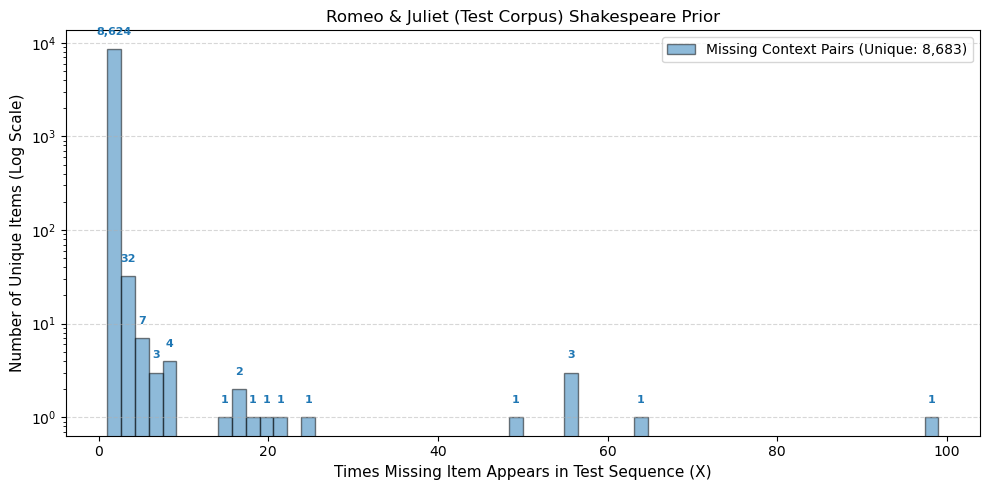

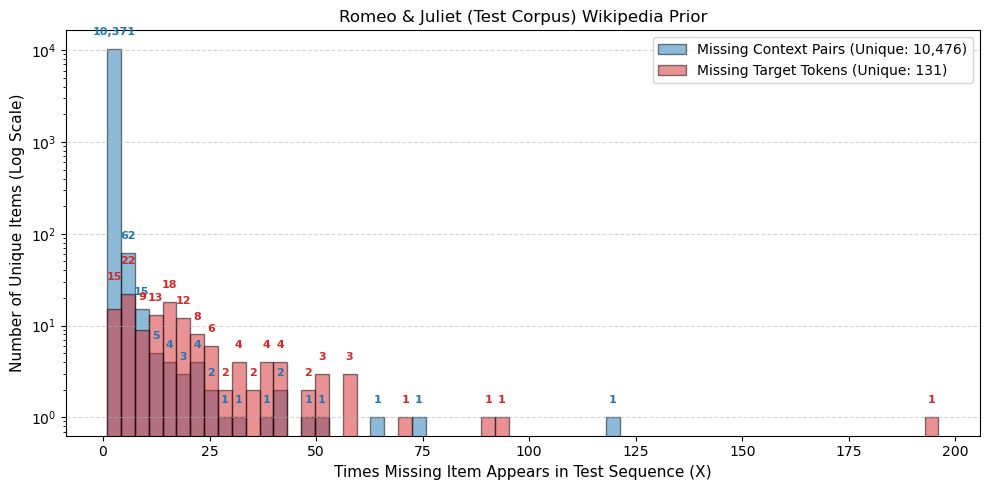

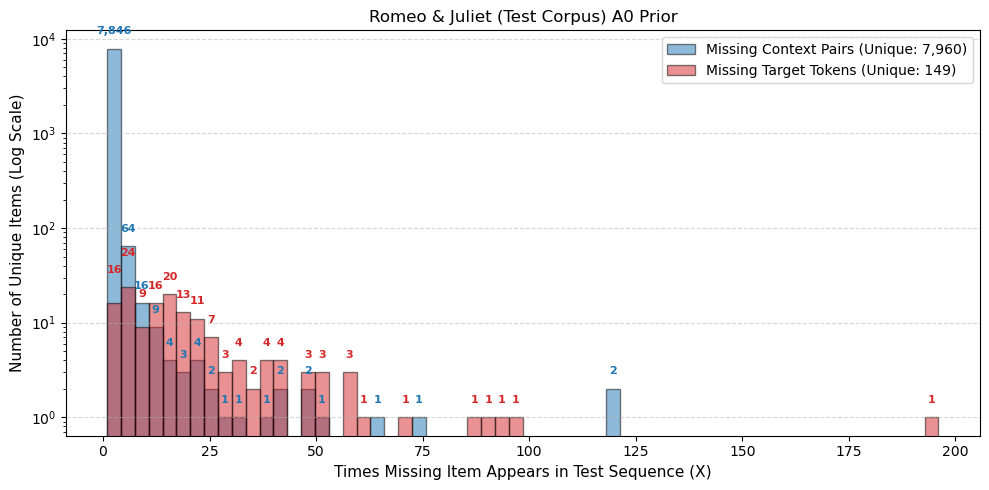

In [33]:
t = encode(test_corpus)
plot_missing_contexts_and_tokens(
    t, probs_matrix, bins=60, 
    title="Romeo & Juliet (Test Corpus) Shakespeare Prior"
)

plot_missing_contexts_and_tokens(
    t, wiki_probs_matrix, bins=60, 
    title="Romeo & Juliet (Test Corpus) Wikipedia Prior"
)

plot_missing_contexts_and_tokens(
    t, a0_probs_matrix, bins=60, 
    title="Romeo & Juliet (Test Corpus) A0 Prior"
)

# plot_missing_contexts_and_tokens(
#     encode(rnj), probs_matrix, bins=60, 
#     title="One Scene"
# )
# plot_missing_contexts_and_tokens(
#     encode(short), probs_matrix,  bins=60, 
#     title="Short Sample"
# )

In [34]:
test_contexts = set(
    (test_ids[i - 1], test_ids[i + 1]) for i in range(1, len(test_ids) - 1)
)

shake_contexts = set(probs_matrix.keys())
a0_contexts = set(a0_probs_matrix.keys())

missing_in_shake = test_contexts - shake_contexts
missing_in_a0 = test_contexts - a0_contexts

recovered_by_a0 = missing_in_shake.intersection(a0_contexts)
missing_in_both = test_contexts - (shake_contexts | a0_contexts)
covered_by_either = test_contexts.intersection(shake_contexts | a0_contexts)

total_test_ctx = len(test_contexts)

print("=== TEST SET CONTEXT COVERAGE ANALYSIS ===")
print(f"Total Unique Contexts in Test Set : {total_test_ctx:,}\n")

print(
    f"Missing in Shakespeare Prior      : {len(missing_in_shake):,} "
    f"({len(missing_in_shake)/total_test_ctx*100:.2f}%)"
)
print(
    f"Missing in A0 Prior        : {len(missing_in_a0):,} "
    f"({len(missing_in_a0)/total_test_ctx*100:.2f}%)"
)
print(
    f"Recovered by A0 Prior      : {len(recovered_by_a0):,} "
    f"({len(recovered_by_a0)/total_test_ctx*100:.2f}% of test set"
)
print(
    f"Missing in BOTH Priors            : {len(missing_in_both):,} "
    f"({len(missing_in_both)/total_test_ctx*100:.2f}%)\n"
)

print(
    f"Covered by AT LEAST ONE Prior    : {len(covered_by_either):,} "
    f"({len(covered_by_either)/total_test_ctx*100:.2f}%)"
)

=== TEST SET CONTEXT COVERAGE ANALYSIS ===
Total Unique Contexts in Test Set : 36,967

Missing in Shakespeare Prior      : 8,683 (23.49%)
Missing in A0 Prior        : 7,960 (21.53%)
Recovered by A0 Prior      : 5,660 (15.31% of test set
Missing in BOTH Priors            : 3,023 (8.18%)

Covered by AT LEAST ONE Prior    : 33,944 (91.82%)


In [35]:
test_contexts = set(
    (test_ids[i - 1], test_ids[i + 1]) for i in range(1, len(test_ids) - 1)
)

shake_contexts = set(probs_matrix.keys())
wiki_contexts = set(wiki_probs_matrix.keys())

missing_in_shake = test_contexts - shake_contexts
missing_in_wiki = test_contexts - wiki_contexts

recovered_by_wiki = missing_in_shake.intersection(wiki_contexts)
missing_in_both = test_contexts - (shake_contexts | wiki_contexts)
covered_by_either = test_contexts.intersection(shake_contexts | wiki_contexts)

total_test_ctx = len(test_contexts)

print("=== TEST SET CONTEXT COVERAGE ANALYSIS ===")
print(f"Total Unique Contexts in Test Set : {total_test_ctx:,}\n")

print(
    f"Missing in Shakespeare Prior      : {len(missing_in_shake):,} "
    f"({len(missing_in_shake)/total_test_ctx*100:.2f}%)"
)
print(
    f"Missing in Wikipedia Prior        : {len(missing_in_wiki):,} "
    f"({len(missing_in_wiki)/total_test_ctx*100:.2f}%)"
)
print(
    f"Recovered by Wikipedia Prior      : {len(recovered_by_wiki):,} "
    f"({len(recovered_by_wiki)/total_test_ctx*100:.2f}% of test set"
)
print(
    f"Missing in BOTH Priors            : {len(missing_in_both):,} "
    f"({len(missing_in_both)/total_test_ctx*100:.2f}%)\n"
)

print(
    f"Covered by AT LEAST ONE Prior    : {len(covered_by_either):,} "
    f"({len(covered_by_either)/total_test_ctx*100:.2f}%)"
)

print("\n--- SAMPLE CONTEXTS MISSING IN BOTH PRIORS ---")
samples_shown = 0

for i in range(1, len(test_ids) - 1):
    ctx = (test_ids[i - 1], test_ids[i + 1])

    if ctx in missing_in_both:
        prev_str = repr(decode([ctx[0]]))
        next_str = repr(decode([ctx[1]]))
        actual_mid = repr(decode([test_ids[i]]))

        print(
            f"  {samples_shown+1}. Context: {prev_str} [ ___ ] {next_str}  "
            f"-> Actual token in test set: {actual_mid}"
        )

        samples_shown += 1
        if samples_shown >= 30:
            break

missing_triplet_counts = Counter()

for i in range(1, len(test_ids) - 1):
    prev_tok = test_ids[i - 1]
    curr_tok = test_ids[i]
    next_tok = test_ids[i + 1]

    context = (prev_tok, next_tok)
    if context in missing_in_both:
        missing_triplet_counts[(prev_tok, curr_tok, next_tok)] += 1

total_missing_occurrences = sum(missing_triplet_counts.values())

print("\nTop Most Frequent Missing Triplets in Test Set:\n")
for idx, ((prev_tok, curr_tok, next_tok), count) in enumerate(
    missing_triplet_counts.most_common(10), 1
):
    prev_str = repr(decode([prev_tok]))
    curr_str = repr(decode([curr_tok]))
    next_str = repr(decode([next_tok]))

    print(
        f"{idx:2d}. Context: {prev_str:<12} [ {curr_str:<8} ] {next_str:<12} "
        f"-> Appeared {count} time(s)"
    )

=== TEST SET CONTEXT COVERAGE ANALYSIS ===
Total Unique Contexts in Test Set : 36,967

Missing in Shakespeare Prior      : 8,683 (23.49%)
Missing in Wikipedia Prior        : 10,476 (28.34%)
Recovered by Wikipedia Prior      : 4,809 (13.01% of test set
Missing in BOTH Priors            : 3,874 (10.48%)

Covered by AT LEAST ONE Prior    : 33,093 (89.52%)

--- SAMPLE CONTEXTS MISSING IN BOTH PRIORS ---
  1. Context: '==' [ ___ ] 'RO'  -> Actual token in test set: '\n'
  2. Context: 'mother' [ ___ ] 'EN'  -> Actual token in test set: '\nB'
  3. Context: '\nB' [ ___ ] 'V'  -> Actual token in test set: 'EN'
  4. Context: 'EN' [ ___ ] 'OL'  -> Actual token in test set: 'V'
  5. Context: 'gu' [ ___ ] 'serv'  -> Actual token in test set: 'e '
  6. Context: 'ing' [ ___ ] '\nB'  -> Actual token in test set: 'man'
  7. Context: 'AR' [ ___ ] 'Rom'  -> Actual token in test set: ', '
  8. Context: 'I' [ ___ ] '\nC'  -> Actual token in test set: 'ET'
  9. Context: 'ET' [ ___ ] 'AP'  -> Actual token in

In [36]:
from collections import Counter
import re
import string

RJ_NAMES_AND_TAGS = {
    "romeo",
    "juliet",
    "capulet",
    "montague",
    "benvolio",
    "mercutio",
    "tybalt",
    "paris",
    "friar",
    "nurse",
    "sampson",
    "gregory",
    "abraham",
    "balthasar",
    "escalus",
    "prince",
    "chorus",
    "apothecary",
    "petruchio",
    "lady",
    "ro",
    "rom",
    "jul",
    "ben",
    "mer",
    "tyb",
    "par",
    "cap",
    "mon",
    "nur",
    "sam",
    "greg",
    "prin",
    "cho",
}


def classify_missing_triplet(prev_str: str, curr_str: str, next_str: str) -> str:
    combined = prev_str + curr_str + next_str

    has_stage_direction = any(
        marker in combined
        for marker in ["[", "]", "==", "exits", "Exit", "Enter"]
    )
    is_pure_punctuation = (
        all(c in string.punctuation or c in "\n\t " for c in combined)
        and len(combined.strip()) > 0
    )

    if has_stage_direction or is_pure_punctuation:
        return "Formatting / Punctuation"

    has_two_consec_caps = bool(re.search(r"[A-Z]{2,}", combined))

    words = re.findall(r"\b[A-Za-z']+\b", combined)
    has_rj_name = any(w.lower() in RJ_NAMES_AND_TAGS for w in words)

    if has_two_consec_caps or has_rj_name:
        return "Name / Speaker Tag"

    return "Actual Word / Syntax"


def analyze_missing_priors(
    token_ids: list[int],
    missing_contexts: set[tuple[int, int]],
    decode_fn=decode,
    max_samples_per_cat: int = 20,
    print_summary: bool = True,
) -> dict:
    missing_category_counts = Counter()
    category_samples = {
        "Name / Speaker Tag": [],
        "Formatting / Punctuation": [],
        "Actual Word / Syntax": [],
    }

    total_missing_instances = 0

    for i in range(1, len(token_ids) - 1):
        prev_tok = token_ids[i - 1]
        curr_tok = token_ids[i]
        next_tok = token_ids[i + 1]

        ctx = (prev_tok, next_tok)

        if ctx in missing_contexts:
            prev_str = decode_fn([prev_tok])
            curr_str = decode_fn([curr_tok])
            next_str = decode_fn([next_tok])

            cat = classify_missing_triplet(prev_str, curr_str, next_str)
            missing_category_counts[cat] += 1
            total_missing_instances += 1

            if len(category_samples[cat]) < max_samples_per_cat:
                category_samples[cat].append(
                    f"Context: {repr(prev_str)} [ {repr(curr_str)} ] {repr(next_str)}"
                )

    if print_summary:
        print("=== MISSING PRIORS BREAKDOWN ===")
        print(
            f"Total Missing Prior Occurrences: {total_missing_instances:,}\n"
        )

        for cat, count in missing_category_counts.most_common():
            pct = (
                (count / total_missing_instances) * 100
                if total_missing_instances > 0
                else 0
            )
            print(f"• {cat:<26}: {count:5,} occurrences ({pct:5.2f}%)")

        print("\n--- SAMPLE BREAKDOWN BY CATEGORY ---")
        for cat, samples in category_samples.items():
            print(f"\n[{cat.upper()}]")
            for s in samples:
                print(f"  - {s}")

    return {
        "counts": missing_category_counts,
        "samples": category_samples,
        "total": total_missing_instances,
    }

p = list(encode(short))
# --- EXAMPLE USAGE ---
analysis_results = analyze_missing_priors(
    token_ids=p,
    missing_contexts=missing_in_both,
    decode_fn=decode
)

=== MISSING PRIORS BREAKDOWN ===
Total Missing Prior Occurrences: 20

• Actual Word / Syntax      :    20 occurrences (100.00%)

--- SAMPLE BREAKDOWN BY CATEGORY ---

[NAME / SPEAKER TAG]

[FORMATTING / PUNCTUATION]

[ACTUAL WORD / SYNTAX]
  - Context: '\nIt ' [ 'is the ' ] 'E'
  - Context: 'f' [ '\nThat ' ] 'thou'
  - Context: 'thou' [ ', ' ] 'her '
  - Context: ' than ' [ 'sh' ] 'e.\n'
  - Context: 'she ' [ 'w' ] 'ere'
  - Context: 'ere' [ '!' ] '\nS'
  - Context: '\nS' [ 'he ' ] 'speak'
  - Context: 'speak' [ 's, ' ] 'yet '
  - Context: 'ses' [ '; ' ] 'I will '
  - Context: '; ' [ 'I will ' ] 'answ'
  - Context: 'old' [ '. ' ] "'Tis "
  - Context: 's in ' [ 'all the ' ] 'heaven'
  - Context: 'heaven' [ ',\n' ] 'Ha'
  - Context: 'Ha' [ 'ving ' ] 'some '
  - Context: 'ving ' [ 'some ' ] 'busin'
  - Context: 'eyes' [ '\nTo ' ] 'tw'
  - Context: 'urn' [ '.\n' ] 'What '
  - Context: 'eyes ' [ 'were ' ] 'ther'
  - Context: 'head' [ '?' ] '\nThe '
  - Context: '?' [ '\nThe ' ] 'bri'


In [37]:
from collections import Counter
import string


def classify_token(token_str: str) -> str:
    """Classifies a token into one of the 5 subword roles based on string boundaries."""
    if not token_str:
        return "PUNCT_SP"

    # Normalize BPE/SentencePiece space characters
    cleaned = token_str.replace("Ġ", " ").replace(" ", " ")

    if all(c.isspace() or c in string.punctuation for c in cleaned):
        return "PUNCT_SP"

    starts_boundary = (
        cleaned[0].isspace() or cleaned[0] in string.punctuation
    )
    ends_boundary = (
        cleaned[-1].isspace() or cleaned[-1] in string.punctuation
    )

    if starts_boundary and ends_boundary:
        return "WORD_FULL"
    elif starts_boundary:
        return "WORD_START"
    elif ends_boundary:
        return "WORD_END"
    else:
        return "WORD_MIDDLE"


def is_valid_bigram(t_left_str: str, t_right_str: str) -> bool:
    """Returns True if t_right can legally attach to t_left."""
    cat_left = classify_token(t_left_str)
    cat_right = classify_token(t_right_str)

    # Continuation subwords (WORD_MIDDLE, WORD_END) CANNOT follow a boundary or finished word
    if cat_right in ("WORD_MIDDLE", "WORD_END"):
        if cat_left in ("PUNCT_SP", "WORD_END", "WORD_FULL"):
            return False

    return True


# --- EVALUATION LOOP ---
total_missing = 0
invalid_missing = 0
valid_missing = 0

violation_types = Counter()
invalid_samples = []

for i in range(1, len(test_ids) - 1):
    prev_tok = test_ids[i - 1]
    curr_tok = test_ids[i]
    next_tok = test_ids[i + 1]

    ctx = (prev_tok, next_tok)  # Adjust to (prev_tok, curr_tok, next_tok) if checking full 3-gram contexts

    if ctx in missing_in_both:
        prev_str = decode([prev_tok])
        curr_str = decode([curr_tok])
        next_str = decode([next_tok])

        total_missing += 1

        valid_left = is_valid_bigram(prev_str, curr_str)
        valid_right = is_valid_bigram(curr_str, next_str)

        if not (valid_left and valid_right):
            invalid_missing += 1

            if not valid_left:
                violation_types["Left Transition Illegal (T1 -> T2)"] += 1
            if not valid_right:
                violation_types["Right Transition Illegal (T2 -> T3)"] += 1

            if len(invalid_samples) < 100:
                invalid_samples.append(
                    f"Triplet: {repr(prev_str)} [ {repr(curr_str)} ] {repr(next_str)} "
                    f"| Categories: ({classify_token(prev_str)}, {classify_token(curr_str)}, {classify_token(next_str)})"
                )
        else:
            valid_missing += 1

# --- SUMMARY STATISTICS ---
pct_invalid = (
    (invalid_missing / total_missing * 100) if total_missing > 0 else 0.0
)
pct_valid = (
    (valid_missing / total_missing * 100) if total_missing > 0 else 0.0
)

print("=== MISSING PRIOR STRUCTURAL VALIDITY RESULTS ===")
print(f"Total Missing Prior Occurrences : {total_missing:,}")
print(
    f"Structurally Invalid (Impossible): {invalid_missing:,} ({pct_invalid:.2f}%)"
)
print(f"Structurally Valid (True Gaps)  : {valid_missing:,} ({pct_valid:.2f}%)\n")

print("--- VIOLATION TYPE BREAKDOWN ---")
for vtype, count in violation_types.most_common():
    print(f"• {vtype:<35}: {count:5,} ({count/total_missing*100:5.2f}%)")

print("\n--- SAMPLE IMPOSSIBLE MISSING TRIPLETS ---")
for sample in invalid_samples:
    print(f"  - {sample}")

=== MISSING PRIOR STRUCTURAL VALIDITY RESULTS ===
Total Missing Prior Occurrences : 4,140
Structurally Invalid (Impossible): 3,261 (78.77%)
Structurally Valid (True Gaps)  : 879 (21.23%)

--- VIOLATION TYPE BREAKDOWN ---
• Right Transition Illegal (T2 -> T3): 2,309 (55.77%)
• Left Transition Illegal (T1 -> T2) : 1,968 (47.54%)

--- SAMPLE IMPOSSIBLE MISSING TRIPLETS ---
  - Triplet: '==' [ '\n' ] 'RO' | Categories: (PUNCT_SP, PUNCT_SP, WORD_MIDDLE)
  - Triplet: 'gu' [ 'e ' ] 'serv' | Categories: (WORD_MIDDLE, WORD_END, WORD_MIDDLE)
  - Triplet: 'AR' [ ', ' ] 'Rom' | Categories: (WORD_MIDDLE, PUNCT_SP, WORD_MIDDLE)
  - Triplet: 'her ' [ 'mother' ] '\nN' | Categories: (WORD_END, WORD_MIDDLE, WORD_START)
  - Triplet: '\n  ' [ 'S' ] 'AM' | Categories: (PUNCT_SP, WORD_MIDDLE, WORD_MIDDLE)
  - Triplet: 'men' [ '\n' ] 'ES' | Categories: (WORD_MIDDLE, PUNCT_SP, WORD_MIDDLE)
  - Triplet: 'US' [ ', ' ] 'Prin' | Categories: (WORD_MIDDLE, PUNCT_SP, WORD_MIDDLE)
  - Triplet: 'IS' [ ', the ' ] 'Prin

# start loop

In [38]:
encoded_noisy_text = generate_noise(rnj, T)
# test_corpus
encoded_clean_text = list(encode(rnj))

initial_sequence_guess = list(encoded_noisy_text)

history = []

T_intermediate = compute_intermediate_matrix(encoded_clean_text, encoded_noisy_text)

Noise:   0%|          | 0/2280 [00:00<?, ?it/s]

## Noisy Prior

In [39]:
noisy_transition_matrix = defaultdict(lambda: defaultdict(int))

for i in tqdm(
    range(1, len(initial_sequence_guess) - 1), desc="Building Transitions"
):
    prev_tok = initial_sequence_guess[i - 1]
    curr_tok = initial_sequence_guess[i]
    next_tok = initial_sequence_guess[i + 1]

    context = (prev_tok, next_tok)
    noisy_transition_matrix[context][curr_tok] += 1

# 2. Normalize counts to probability distributions
noisy_probs_matrix = {}
for context, middle_tokens in tqdm(
    noisy_transition_matrix.items(), desc="Computing Wiki Probabilities"
):
    total_occurrences = sum(middle_tokens.values())
    noisy_probs_matrix[context] = {
        tok: count / total_occurrences
        for tok, count in middle_tokens.items()
    }

print(
    f"\nDone! Noisy Probs Matrix created with {len(noisy_probs_matrix):,} unique contexts."
)

Building Transitions:   0%|          | 0/2278 [00:00<?, ?it/s]

Computing Wiki Probabilities:   0%|          | 0/2139 [00:00<?, ?it/s]


Done! Noisy Probs Matrix created with 2,139 unique contexts.


In [40]:
lambda_shake = 0.5
# wiki_probs_matrix

# NOISY
all_contexts = set(probs_matrix.keys()) | set(noisy_probs_matrix.keys())
combinedn_probs_matrix = {}

for ctx in tqdm(all_contexts, desc=f"Building Linear Interpolation (λ={lambda_shake})"):
    shake_dist = probs_matrix.get(ctx)
    noisy_dist = noisy_probs_matrix.get(ctx)

    if shake_dist and noisy_dist:
        all_tokens = set(shake_dist.keys()) | set(noisy_dist.keys())
        blended = {}
        for tok in all_tokens:
            p_s = shake_dist.get(tok, 0.0)
            p_w = noisy_dist.get(tok, 0.0)
            blended[tok] = (lambda_shake * p_s) + ((1 - lambda_shake) * p_w)
            
        combinedn_probs_matrix[ctx] = blended

    elif shake_dist:
        combinedn_probs_matrix[ctx] = shake_dist

    else:
        combinedn_probs_matrix[ctx] = noisy_dist

print(
    f"\ncombined_probs_matrix created successfully with {len(combinedn_probs_matrix):,} contexts!"
)

# english books
all_contexts = set(probs_matrix.keys()) | set(a0_probs_matrix.keys())
combined_probs_matrix = {}

for ctx in tqdm(all_contexts, desc=f"Building Linear Interpolation (λ={lambda_shake})"):
    shake_dist = probs_matrix.get(ctx)
    wiki_dist = a0_probs_matrix.get(ctx)

    if shake_dist and wiki_dist:
        all_tokens = set(shake_dist.keys()) | set(wiki_dist.keys())
        blended = {}
        for tok in all_tokens:
            p_s = shake_dist.get(tok, 0.0)
            p_w = wiki_dist.get(tok, 0.0)
            blended[tok] = (lambda_shake * p_s) + ((1 - lambda_shake) * p_w)
            
        combined_probs_matrix[ctx] = blended

    elif shake_dist:
        combined_probs_matrix[ctx] = shake_dist

    else:
        combined_probs_matrix[ctx] = wiki_dist

print(
    f"\ncombined_probs_matrix created successfully with {len(combined_probs_matrix):,} contexts!"
)

Building Linear Interpolation (λ=0.5):   0%|          | 0/578543 [00:00<?, ?it/s]


combined_probs_matrix created successfully with 578,543 contexts!


Building Linear Interpolation (λ=0.5):   0%|          | 0/1498070 [00:00<?, ?it/s]


combined_probs_matrix created successfully with 1,498,070 contexts!


# START SAEM

Using Noisy


SAEM (Tensor):   0%|          | 0/10000 [00:00<?, ?it/s]


 SAEM Time Report (10000 Iterations)
to_tensor_init          | Avg:  0.0010s | Total:  10.02s (17.2%)
sample_text_gibbs       | Avg:  0.0033s | Total:  32.83s (56.3%)
compute_local_stats     | Avg:  0.0001s | Total:   0.61s ( 1.0%)
update_global_stats     | Avg:  0.0000s | Total:   0.17s ( 0.3%)
update_model            | Avg:  0.0003s | Total:   3.30s ( 5.7%)
metrics_and_evaluation  | Avg:  0.0011s | Total:  11.38s (19.5%)
convert_to_dict         | Avg:  0.0000s | Total:   0.04s ( 0.1%)



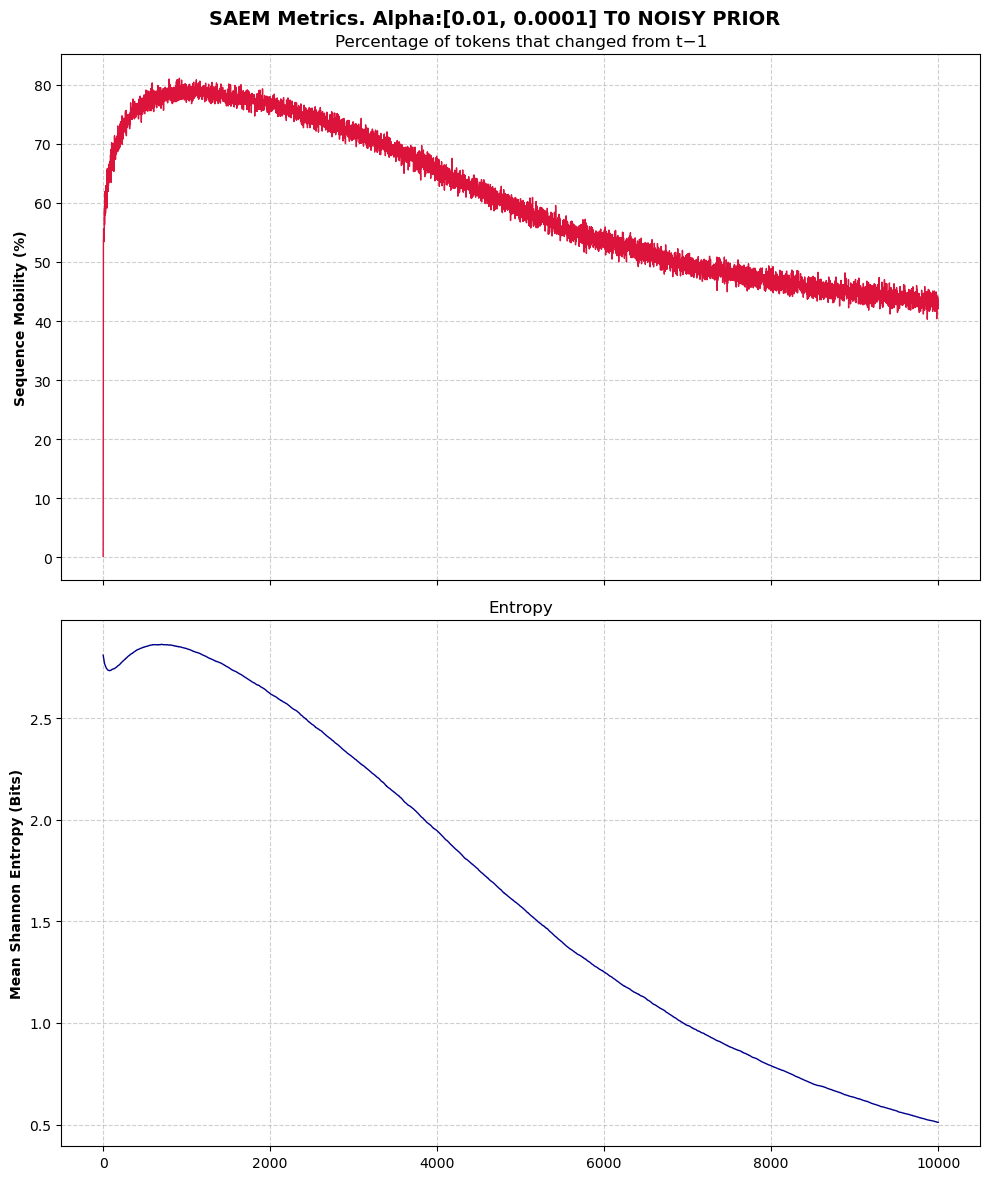

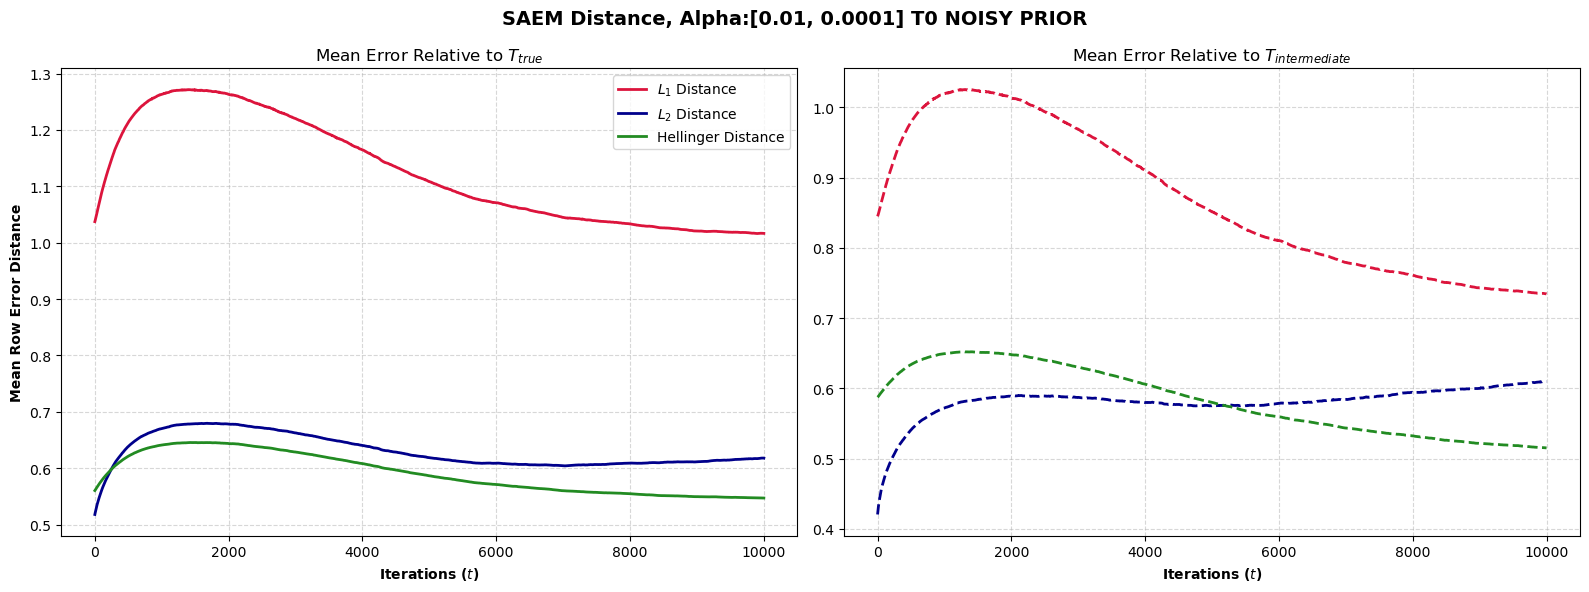

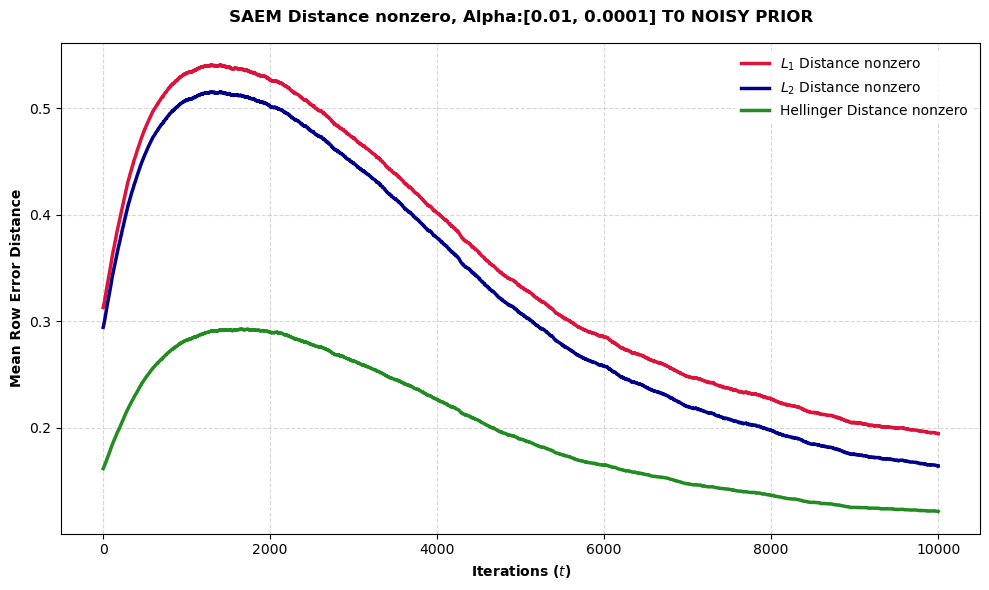

<Figure size 640x480 with 0 Axes>

SAEM (Tensor):   0%|          | 0/10000 [00:00<?, ?it/s]


 SAEM Time Report (10000 Iterations)
to_tensor_init          | Avg:  0.0010s | Total:   9.68s (16.8%)
sample_text_gibbs       | Avg:  0.0033s | Total:  32.57s (56.5%)
compute_local_stats     | Avg:  0.0001s | Total:   0.60s ( 1.0%)
update_global_stats     | Avg:  0.0000s | Total:   0.17s ( 0.3%)
update_model            | Avg:  0.0003s | Total:   3.26s ( 5.7%)
metrics_and_evaluation  | Avg:  0.0011s | Total:  11.36s (19.7%)
convert_to_dict         | Avg:  0.0000s | Total:   0.04s ( 0.1%)



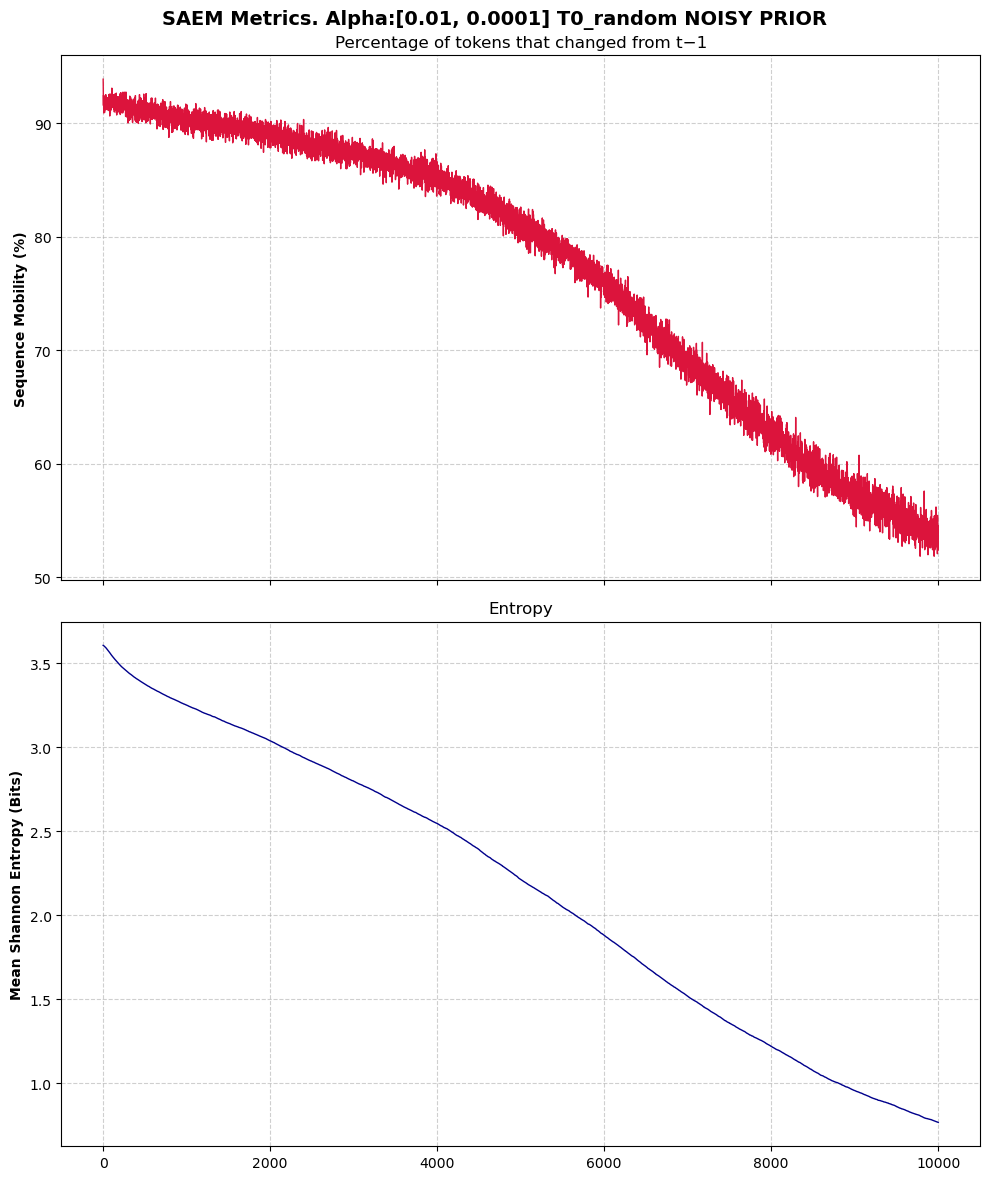

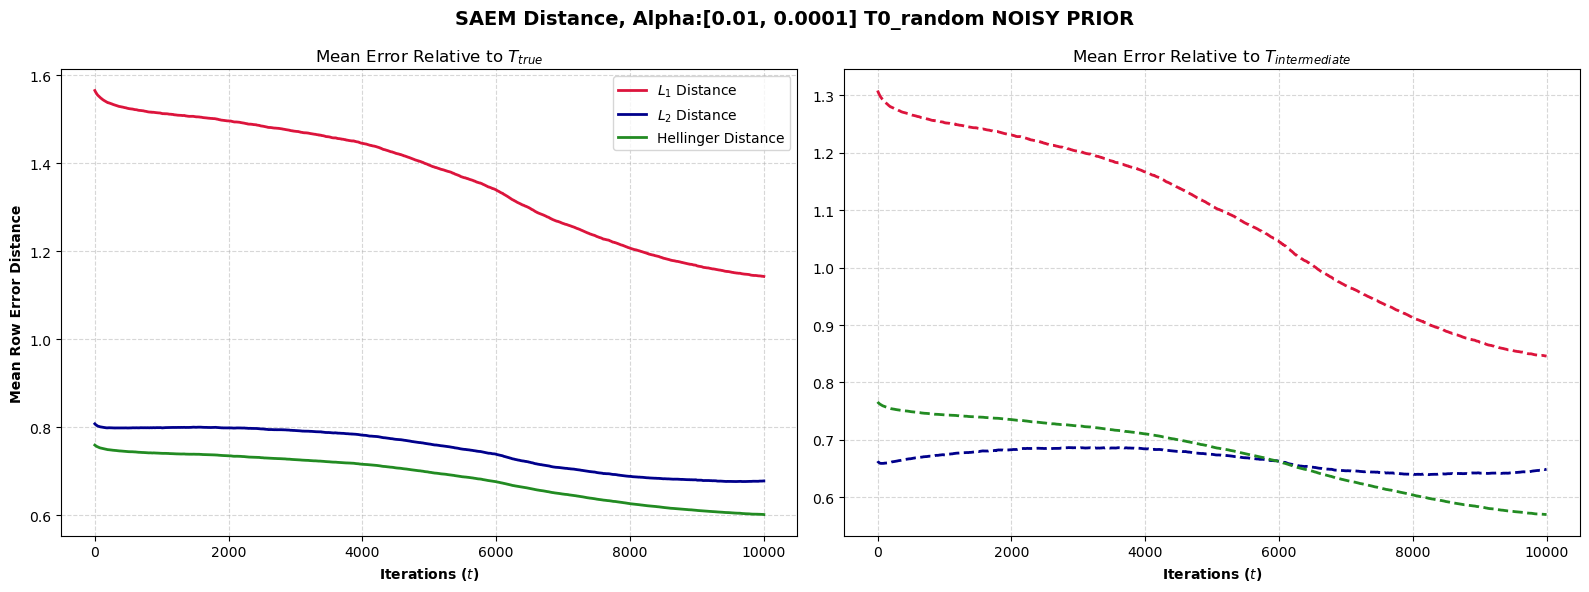

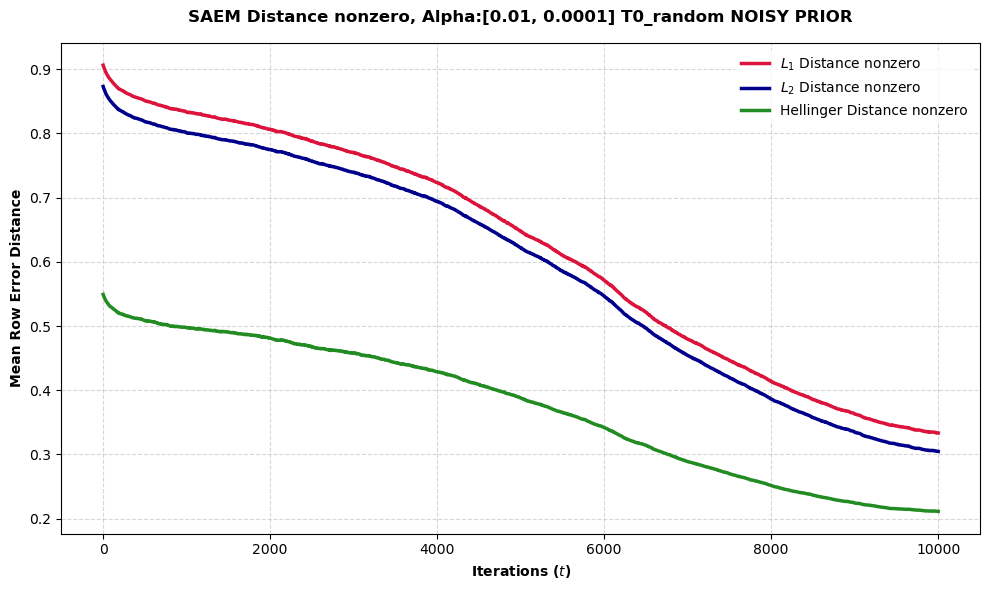

<Figure size 640x480 with 0 Axes>

In [41]:
alpha_start = 0.01
alpha_end = 0.0001
num_iter = 10000

print("Using Noisy")
estimated_T_dict_t0n, history_t0n = train_saem_pure_pt(
    encoded_initial=initial_sequence_guess, 
    encoded_noisy=encoded_noisy_text, 
    # prior_matrix=probs_matrix, 
    prior_matrix=combinedn_probs_matrix,
    initial_T=T0,
    T_true=T, 
    T_intermediate=T_intermediate,
    T0_inv=T0_inv,
    alpha_start=alpha_start,
    alpha_end=alpha_end, 
    num_iterations=num_iter
)

plot_saem(history_t0n, alpha_start, alpha_end, title="T0 NOISY PRIOR")
plot_saem_distance(history_t0n, alpha_start, alpha_end, title="T0 NOISY PRIOR")

estimated_T_dict_t0_randomn, history_t0_randomn = train_saem_pure_pt(
    encoded_initial=initial_sequence_guess, 
    encoded_noisy=encoded_noisy_text, 
    # prior_matrix=probs_matrix, 
    prior_matrix=combinedn_probs_matrix,
    initial_T=T0_random,
    T_true=T, 
    T_intermediate=T_intermediate,
    T0_inv=T0_inv_random,
    alpha_start=alpha_start,
    alpha_end=alpha_end, 
    num_iterations=num_iter
)

plot_saem(history_t0_randomn, alpha_start, alpha_end, title="T0_random NOISY PRIOR")
plot_saem_distance(history_t0_randomn, alpha_start, alpha_end, title="T0_random NOISY PRIOR")

Using A0 Old English Books


SAEM (Tensor):   0%|          | 0/10000 [00:00<?, ?it/s]


 SAEM Time Report (10000 Iterations)
to_tensor_init          | Avg:  0.0059s | Total:  59.06s (54.9%)
sample_text_gibbs       | Avg:  0.0033s | Total:  32.76s (30.4%)
compute_local_stats     | Avg:  0.0001s | Total:   0.61s ( 0.6%)
update_global_stats     | Avg:  0.0000s | Total:   0.17s ( 0.2%)
update_model            | Avg:  0.0003s | Total:   3.22s ( 3.0%)
metrics_and_evaluation  | Avg:  0.0012s | Total:  11.81s (11.0%)
convert_to_dict         | Avg:  0.0000s | Total:   0.04s ( 0.0%)



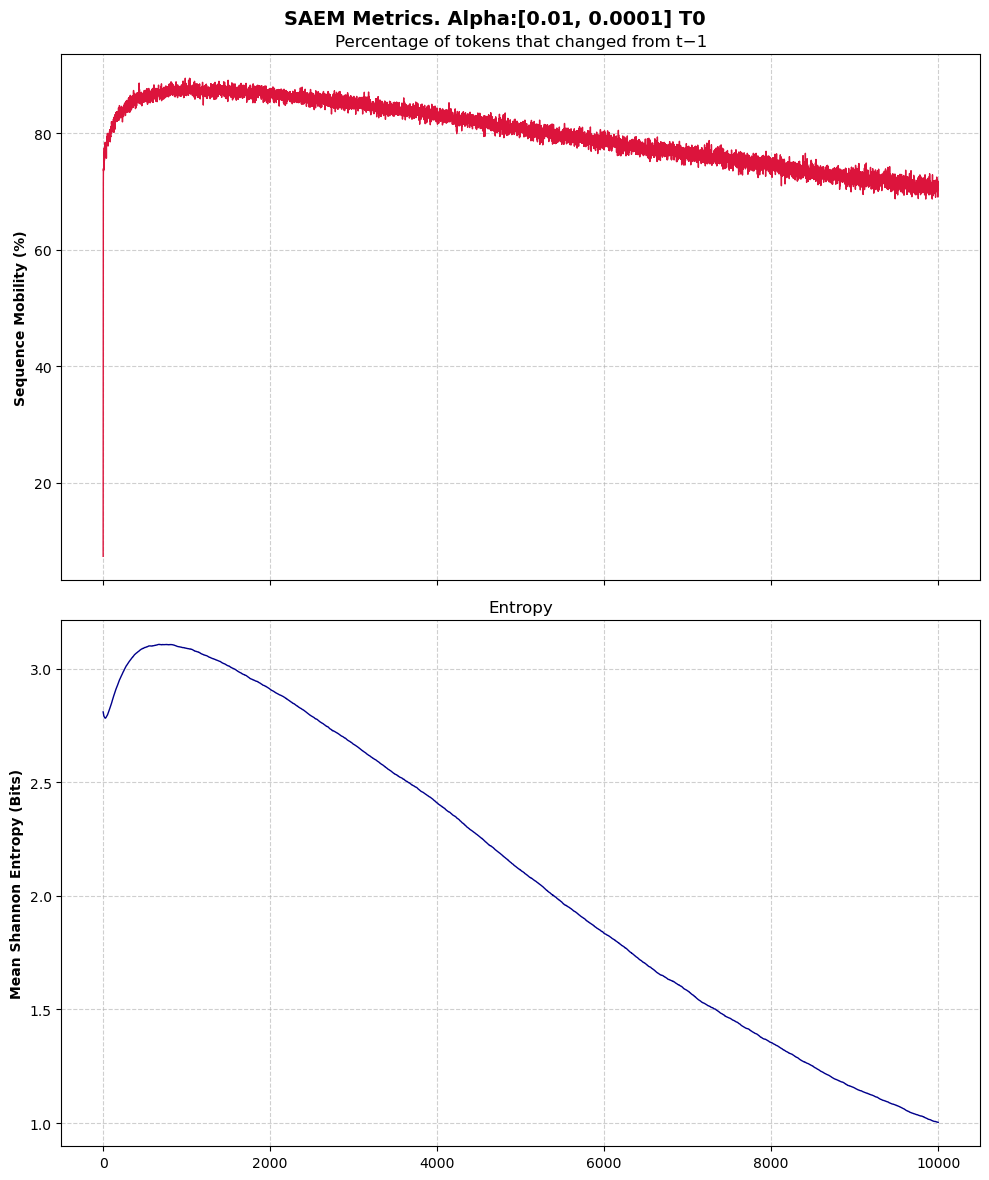

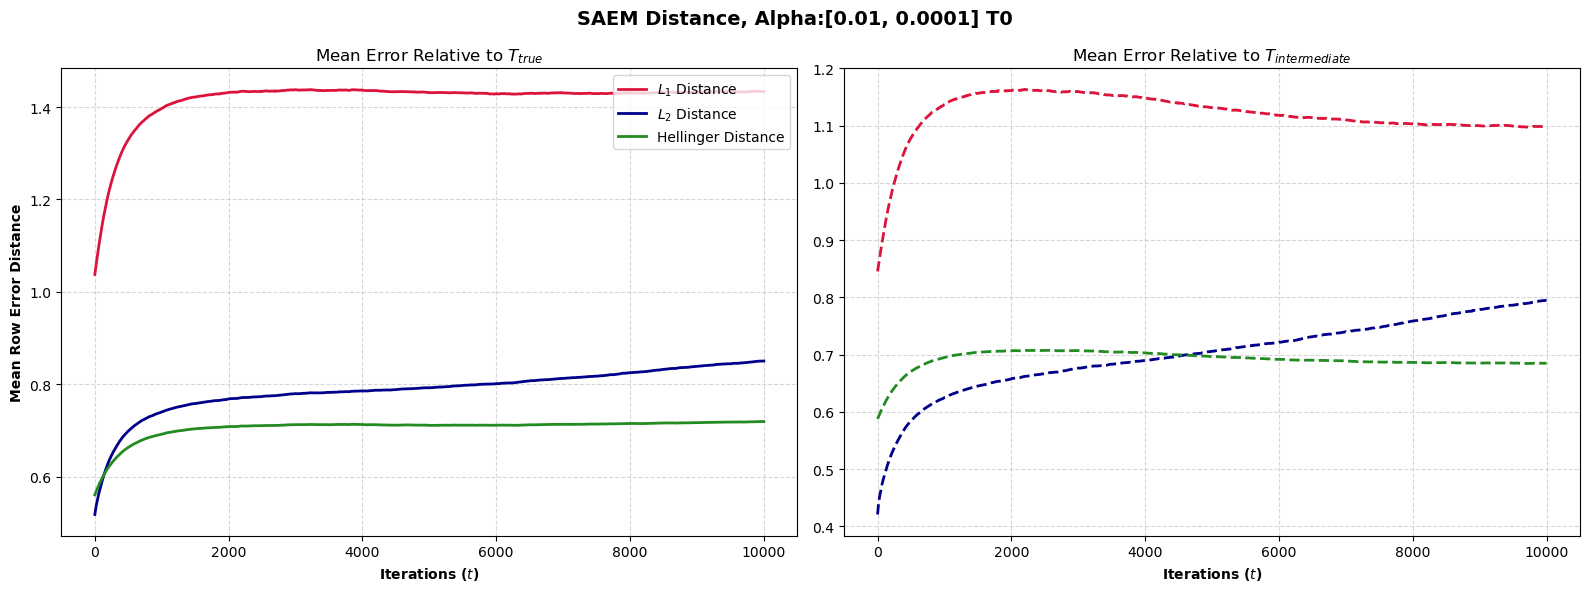

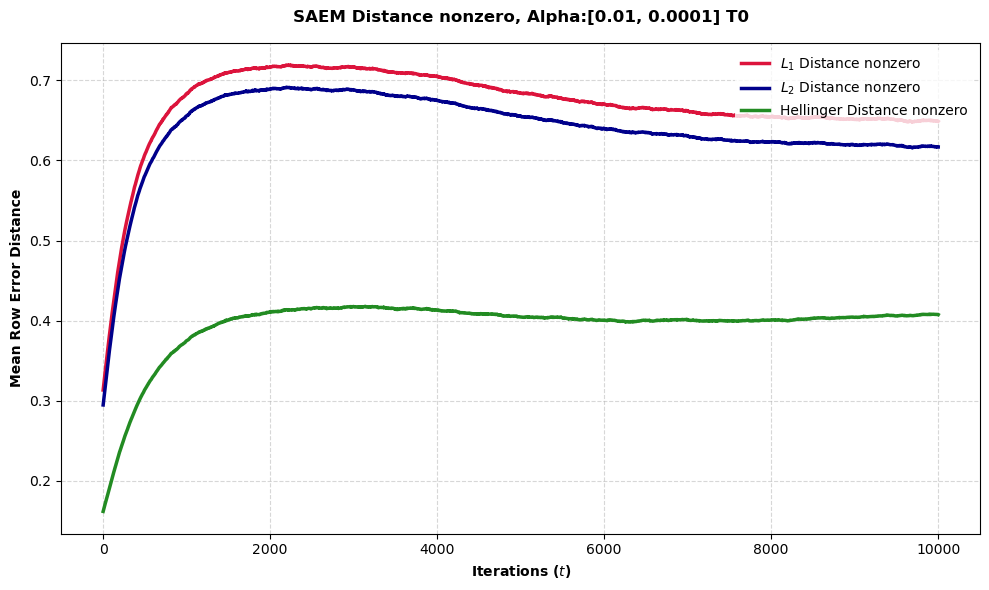

<Figure size 640x480 with 0 Axes>

SAEM (Tensor):   0%|          | 0/10000 [00:00<?, ?it/s]


 SAEM Time Report (10000 Iterations)
to_tensor_init          | Avg:  0.0069s | Total:  68.95s (57.2%)
sample_text_gibbs       | Avg:  0.0035s | Total:  35.01s (29.1%)
compute_local_stats     | Avg:  0.0001s | Total:   0.70s ( 0.6%)
update_global_stats     | Avg:  0.0000s | Total:   0.19s ( 0.2%)
update_model            | Avg:  0.0003s | Total:   3.42s ( 2.8%)
metrics_and_evaluation  | Avg:  0.0012s | Total:  12.19s (10.1%)
convert_to_dict         | Avg:  0.0000s | Total:   0.05s ( 0.0%)



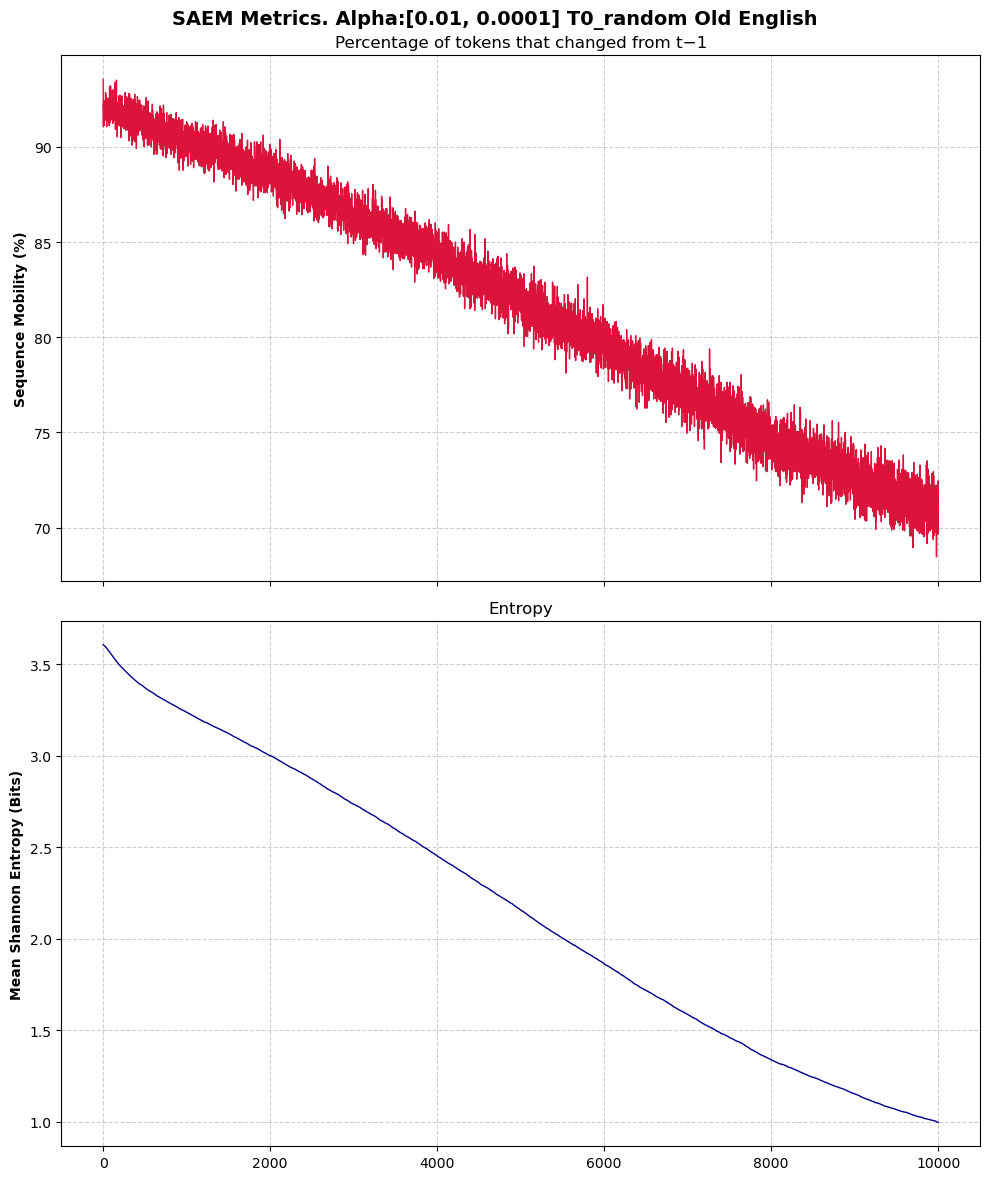

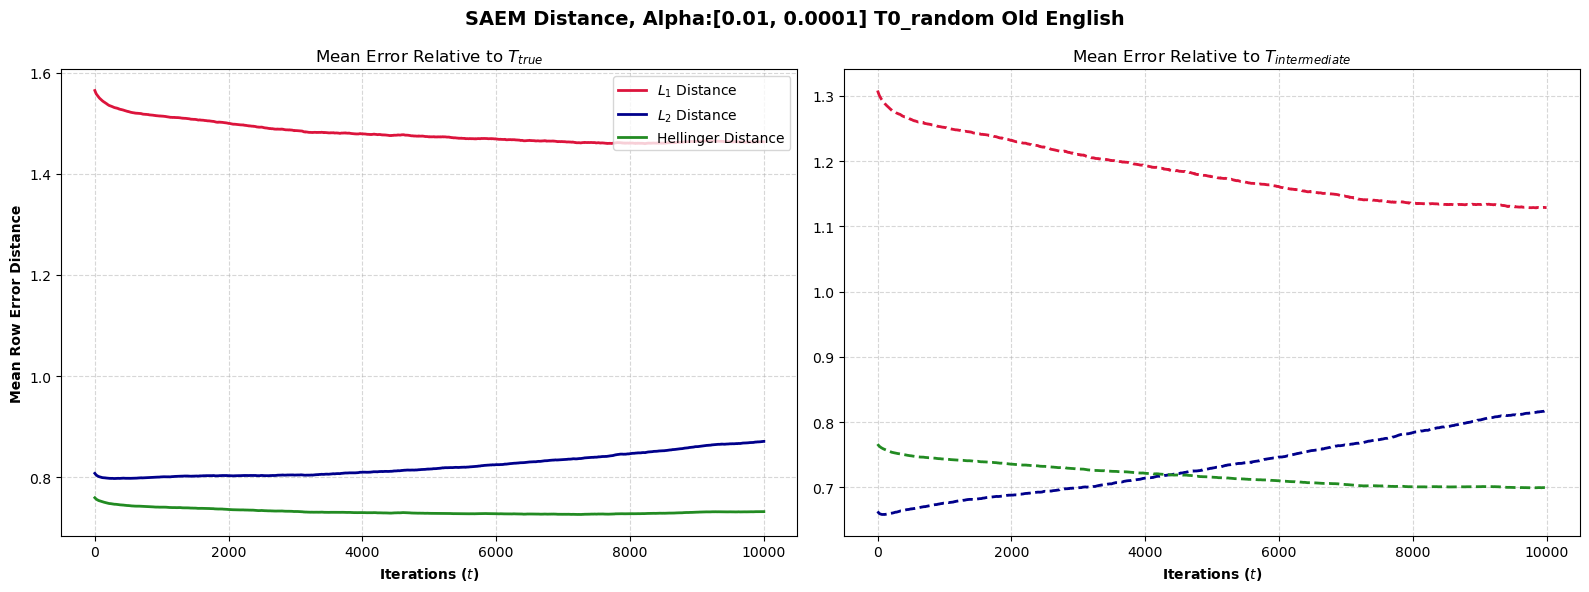

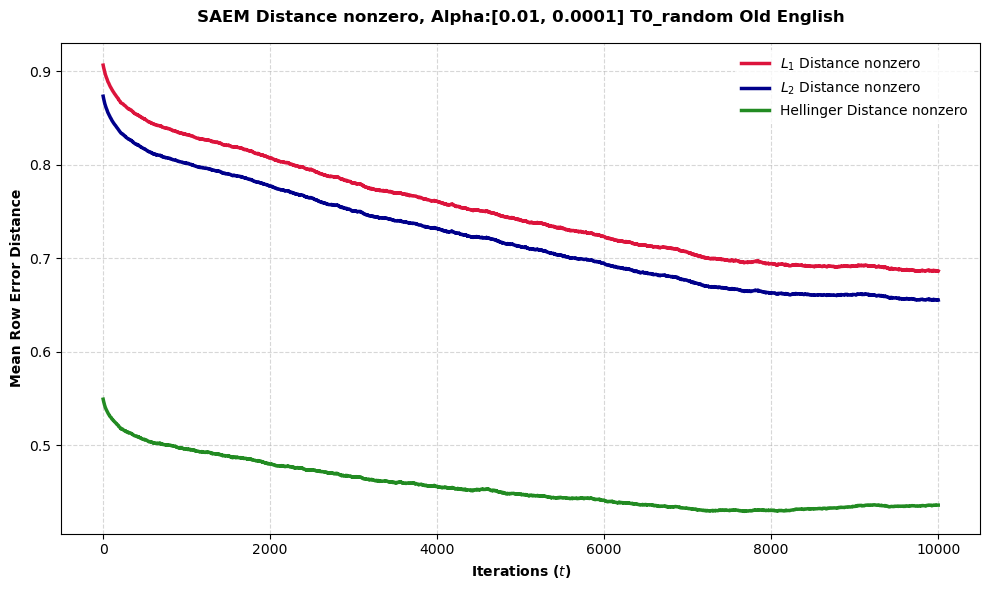

<Figure size 640x480 with 0 Axes>

In [42]:
print("Using A0 Old English Books")
estimated_T_dict_t0, history_t0 = train_saem_pure_pt(
    encoded_initial=initial_sequence_guess, 
    encoded_noisy=encoded_noisy_text, 
    # prior_matrix=probs_matrix, 
    prior_matrix=combined_probs_matrix,
    initial_T=T0,
    T_true=T, 
    T_intermediate=T_intermediate,
    T0_inv=T0_inv,
    alpha_start=alpha_start,
    alpha_end=alpha_end, 
    num_iterations=num_iter
)

plot_saem(history_t0, alpha_start, alpha_end, title="T0")
plot_saem_distance(history_t0, alpha_start, alpha_end, title="T0")

estimated_T_dict_t0_random, history_t0_random = train_saem_pure_pt(
    encoded_initial=initial_sequence_guess, 
    encoded_noisy=encoded_noisy_text, 
    # prior_matrix=probs_matrix, 
    prior_matrix=combined_probs_matrix,
    initial_T=T0_random,
    T_true=T, 
    T_intermediate=T_intermediate,
    T0_inv=T0_inv_random,
    alpha_start=alpha_start,
    alpha_end=alpha_end, 
    num_iterations=num_iter
)

plot_saem(history_t0_random, alpha_start, alpha_end, title="T0_random Old English")
plot_saem_distance(history_t0_random, alpha_start, alpha_end, title="T0_random Old English")

# estimated_T_dict_t0_uniform, history_t0_uniform = train_saem_pure_pt(
#     encoded_initial=initial_sequence_guess, 
#     encoded_noisy=encoded_noisy_text, 
#     prior_matrix=probs_matrix, 
#     initial_T=T0_uniform,
#     T_true=T, 
#     T_intermediate=T_intermediate,
#     T0_inv=T0_inv_uniform,
#     alpha_start=alpha_start,
#     alpha_end=alpha_end, 
#     num_iterations=num_iter
# )

# plot_saem(history_t0_uniform, alpha_start, alpha_end, title="T0_uniform")
# plot_saem_distance(history_t0_uniform, alpha_start, alpha_end, title="T0_uniform")

In [43]:
def plot_alpha_metric_comparison(results_dict):
    metrics = ['L1 Distance', 'L2 Distance', 'Hellinger']
    configs = list(results_dict.keys())
    num_configs = len(configs)
    
    # Layout configuration for grouped bars
    x_indexes = np.arange(len(metrics))
    total_group_width = 0.8
    bar_width = total_group_width / num_configs
    
    # Choose a cohesive color palette (using plt.get_cmap for version compatibility)
    colors = plt.get_cmap('viridis', num_configs)
    
    # Create 3-panel plot: True Matrix vs Intermediate Matrix vs Non-zero Intermediate Matrix
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    ref_keys = [
        ('true', 'True Transition Matrix (T_true)'), 
        ('int', 'Intermediate Matrix (T_intermediate)'),
        ('nonzero', 'Non-Zero Transitions only (T_intermediate)')
    ]
    
    for subplot_idx, (prefix, title_suffix) in enumerate(ref_keys):
        ax = axes[subplot_idx]
        
        # Generate bars for each alpha profile configuration
        for config_idx, config_label in enumerate(configs):
            # Compute position offset relative to base category index
            offset = (config_idx - (num_configs - 1) / 2) * bar_width
            
            # Fetch stored scalar values
            data = results_dict[config_label]
            values = [
                data[f'{prefix}_l1'], 
                data[f'{prefix}_l2'], 
                data[f'{prefix}_hellinger']
            ]
            
            # Plot individual configuration bar groups
            ax.bar(
                x_indexes + offset, 
                values, 
                width=bar_width, 
                label=config_label,
                color=colors(config_idx),
                edgecolor='black',
                linewidth=0.7,
                alpha=0.9
            )
            
        # Decorate the axes
        ax.set_title(f"Error Relative to:\n{title_suffix}", fontsize=12, pad=12, fontweight='semibold')
        ax.set_xticks(x_indexes)
        ax.set_xticklabels(metrics, fontsize=10)
        ax.set_ylabel("Distance Metric Value", fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.6)
        
        # Show legend only on the first plot to avoid clutter
        if subplot_idx == 0:
            ax.legend(title="Alpha Profiles", loc='upper right', framealpha=0.9)
            
    plt.tight_layout()
    plt.show()

def compare_matrices(T_true, T_intermediate, T_estimated, vocab, precision=4, limit=100):
    print("=" * 80)
    print(f"{'True Token':<15} | {'Noisy Candidate':<15} | {'True P':<12} | {'Int P':<12} | {'Est P':<12}")
    print("=" * 80)
    
    # Helper to clean and decode token IDs safely
    def get_token_str(token_id):
        if token_id in vocab:
            token_val = vocab[token_id]
            if isinstance(token_val, bytes):
                return repr(token_val.decode('utf-8', errors='replace'))
            return repr(token_val)
        return f"ID:{token_id}"

    # Base our loop iteration off the superset of tracking keys across all structures
    all_true_ids = sorted(list(set(T_intermediate.keys()) | set(T_estimated.keys())))
    cnt = 0
    
    for m_id in all_true_ids:
        if cnt > limit:
            break
        cnt += 1
        true_token_str = get_token_str(m_id)
        
        true_targets = T_true.get(m_id, {})
        int_targets = T_intermediate.get(m_id, {})
        est_targets = T_estimated.get(m_id, {})
        
        # Combine candidate spaces across all three matrices to avoid missing structural paths
        all_possible_noisy_targets = sorted(list(
            set(true_targets.keys()) | 
            set(int_targets.keys()) | 
            set(est_targets.keys())
        ))
        
        header_printed = False
        
        for k_id in all_possible_noisy_targets:
            p_true = true_targets.get(k_id, 0.0)
            p_int = int_targets.get(k_id, 0.0)
            p_est = est_targets.get(k_id, 0.0)
                
            noisy_token_str = get_token_str(k_id)
            row_label = true_token_str if not header_printed else ""
            
            print(f"{row_label:<15} | {noisy_token_str:<15} | "
                  f"{p_true:<12.{precision}f} | "
                  f"{p_int:<12.{precision}f} | "
                  f"{p_est:<12.{precision}f} | ")
            header_printed = True
            
        if header_printed:
            print("-" * 80)

def compare_matrices_nonzero(T_true, T_intermediate, T_estimated, vocab, precision=4, limit=100):
    print("=" * 80)
    print(f"{'True Token':<15} | {'Noisy Candidate':<15} | {'True P':<12} | {'Int P':<12} | {'Est P':<12}")
    print("=" * 80)
    
    # Helper to clean and decode token IDs safely
    def get_token_str(token_id):
        if token_id in vocab:
            token_val = vocab[token_id]
            if isinstance(token_val, bytes):
                return repr(token_val.decode('utf-8', errors='replace'))
            return repr(token_val)
        return f"ID:{token_id}"

    # Base our loop iteration off the superset of tracking keys across all structures
    all_true_ids = sorted(list(set(T_intermediate.keys())))
    cnt = 0
    
    for m_id in all_true_ids:
        if cnt > limit:
            break
        cnt += 1
        true_token_str = get_token_str(m_id)
        
        true_targets = T_true.get(m_id, {})
        int_targets = T_intermediate.get(m_id, {})
        est_targets = T_estimated.get(m_id, {})
        
        # Combine candidate spaces across all three matrices to avoid missing structural paths
        all_possible_noisy_targets = sorted(list(
            set(true_targets.keys()) | 
            set(int_targets.keys()) | 
            set(est_targets.keys())
        ))
        
        header_printed = False
        
        for k_id in all_possible_noisy_targets:
            p_true = true_targets.get(k_id, 0.0)
            p_int = int_targets.get(k_id, 0.0)
            p_est = est_targets.get(k_id, 0.0)
                
            noisy_token_str = get_token_str(k_id)
            row_label = true_token_str if not header_printed else ""
            
            print(f"{row_label:<15} | {noisy_token_str:<15} | "
                  f"{p_true:<12.{precision}f} | "
                  f"{p_int:<12.{precision}f} | "
                  f"{p_est:<12.{precision}f} | ")
            header_printed = True
            
        if header_printed:
            print("-" * 80)

Using A0 Old English Books


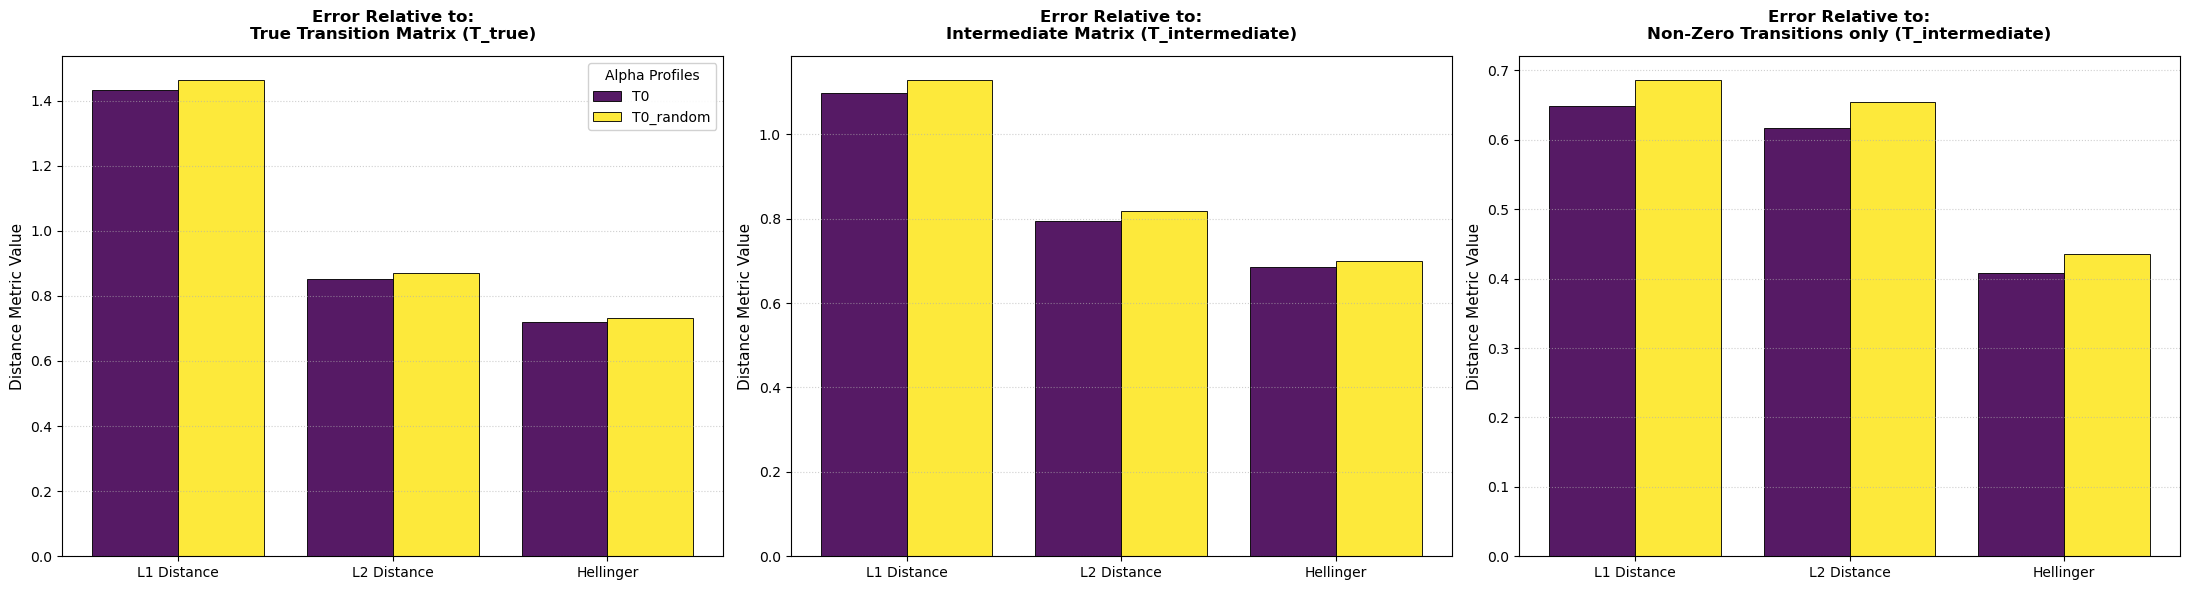

In [44]:
print("Using A0 Old English Books")
sweep_results = {}

sweep_results['T0'] = {
    'true_l1': history_t0['true_l1'][-1],
    'true_l2': history_t0['true_l2'][-1],
    'true_hellinger': history_t0['true_hellinger'][-1],
    'int_l1': history_t0['int_l1'][-1],
    'int_l2': history_t0['int_l2'][-1],
    'int_hellinger': history_t0['int_hellinger'][-1],
    'nonzero_l1': history_t0['nonzero_l1'][-1],
    'nonzero_l2': history_t0['nonzero_l2'][-1],
    'nonzero_hellinger': history_t0['nonzero_hel'][-1]
}

sweep_results['T0_random'] = {
    'true_l1': history_t0_random['true_l1'][-1],
    'true_l2': history_t0_random['true_l2'][-1],
    'true_hellinger': history_t0_random['true_hellinger'][-1],
    'int_l1': history_t0_random['int_l1'][-1],
    'int_l2': history_t0_random['int_l2'][-1],
    'int_hellinger': history_t0_random['int_hellinger'][-1],
    'nonzero_l1': history_t0_random['nonzero_l1'][-1],
    'nonzero_l2': history_t0_random['nonzero_l2'][-1],
    'nonzero_hellinger': history_t0_random['nonzero_hel'][-1]
}

# sweep_results['T0_uniform'] = {
#     'true_l1': history_t0_uniform['true_l1'][-1],
#     'true_l2': history_t0_uniform['true_l2'][-1],
#     'true_hellinger': history_t0_uniform['true_hellinger'][-1],
#     'int_l1': history_t0_uniform['int_l1'][-1],
#     'int_l2': history_t0_uniform['int_l2'][-1],
#     'int_hellinger': history_t0_uniform['int_hellinger'][-1],
#     'nonzero_l1': history_t0_uniform['nonzero_l1'][-1],
#     'nonzero_l2': history_t0_uniform['nonzero_l2'][-1],
#     'nonzero_hellinger': history_t0_uniform['nonzero_hel'][-1]
# }

plot_alpha_metric_comparison(sweep_results)

Using Noisy Prior


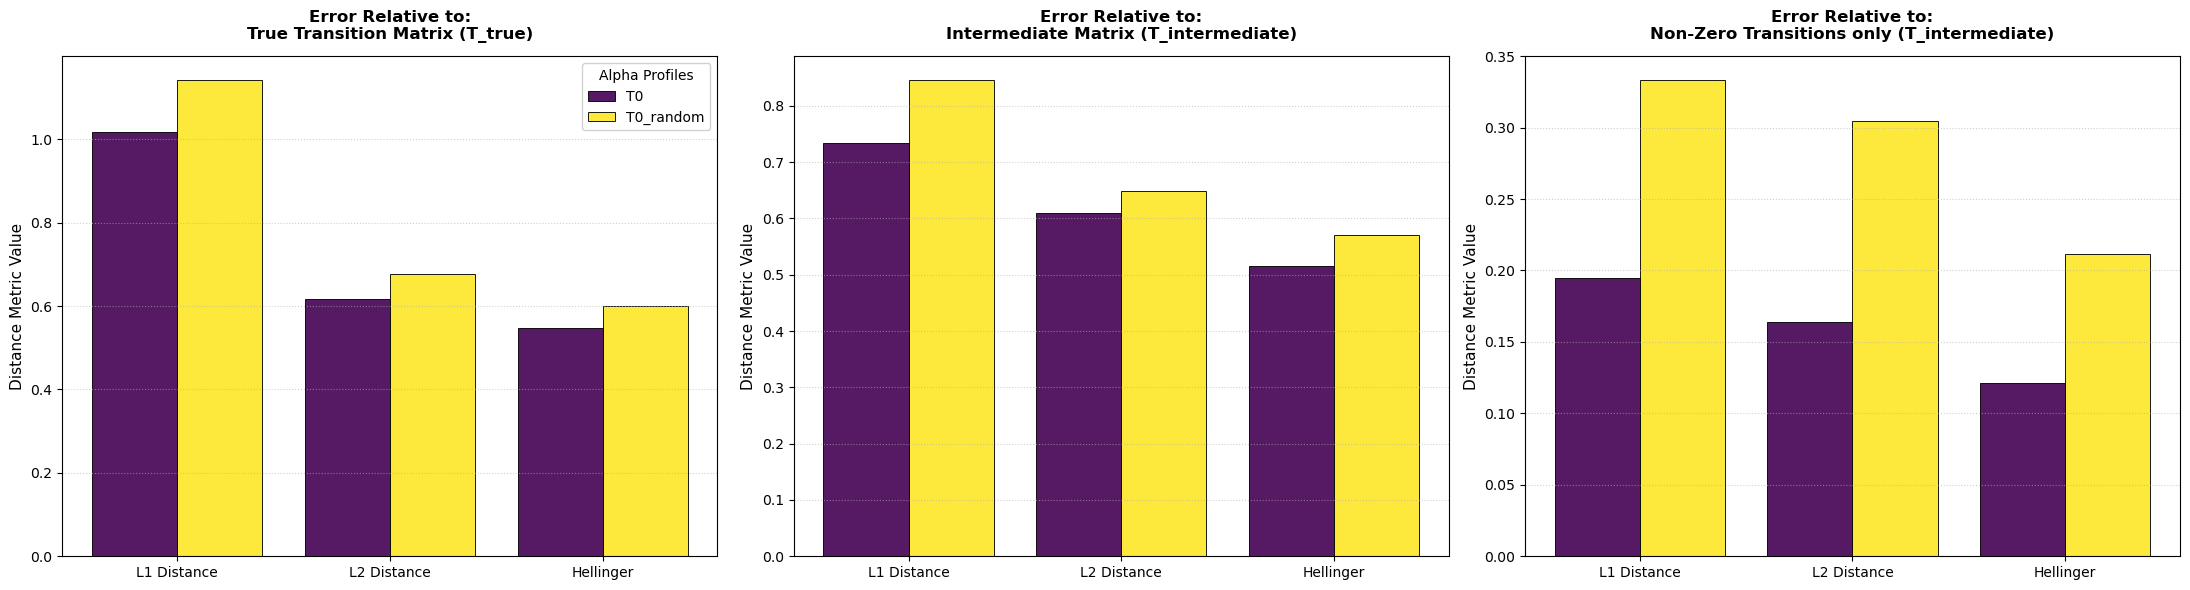

In [45]:
print("Using Noisy Prior")
sweep_resultsn = {}

sweep_resultsn['T0'] = {
    'true_l1': history_t0n['true_l1'][-1],
    'true_l2': history_t0n['true_l2'][-1],
    'true_hellinger': history_t0n['true_hellinger'][-1],
    'int_l1': history_t0n['int_l1'][-1],
    'int_l2': history_t0n['int_l2'][-1],
    'int_hellinger': history_t0n['int_hellinger'][-1],
    'nonzero_l1': history_t0n['nonzero_l1'][-1],
    'nonzero_l2': history_t0n['nonzero_l2'][-1],
    'nonzero_hellinger': history_t0n['nonzero_hel'][-1]
}

sweep_resultsn['T0_random'] = {
    'true_l1': history_t0_randomn['true_l1'][-1],
    'true_l2': history_t0_randomn['true_l2'][-1],
    'true_hellinger': history_t0_randomn['true_hellinger'][-1],
    'int_l1': history_t0_randomn['int_l1'][-1],
    'int_l2': history_t0_randomn['int_l2'][-1],
    'int_hellinger': history_t0_randomn['int_hellinger'][-1],
    'nonzero_l1': history_t0_randomn['nonzero_l1'][-1],
    'nonzero_l2': history_t0_randomn['nonzero_l2'][-1],
    'nonzero_hellinger': history_t0_randomn['nonzero_hel'][-1]
}

plot_alpha_metric_comparison(sweep_resultsn)

In [ ]:
# compare_matrices_nonzero(
#     T_true=T,
#     T_intermediate=T_intermediate,
#     T_estimated=estimated_T_dict_t0,
#     vocab=vocab,
#     precision=7,
#     limit=100
# )
# compare_matrices(
#     T_true=T,
#     T_intermediate=T_intermediate,
#     T_estimated=estimated_T_dict_t0_random,
#     vocab=vocab,
#     precision=7,
#     limit=20
# )

# DECODING

In [ ]:
# def belief_propagation_decode(noisy_tokens, T_matrix, prior_matrix, vocab):
#     N = len(noisy_tokens)
#     if N == 0:
#         return []
#     if N == 1:
#         # Fallback for single token: take the most likely clean token emitting it
#         x = noisy_tokens[0]
#         best_token = x
#         best_prob = -1
#         for clean_id, emissions in T_matrix.items():
#             if x in emissions and emissions[x] > best_prob:
#                 best_prob = emissions[x]
#                 best_token = clean_id
#         return [best_token]

#     # 1. Invert T_matrix locally to find valid candidates for each observed token quickly
#     T_inv = defaultdict(list)
#     for clean_id, observations in T_matrix.items():
#         for observed_id, prob in observations.items():
#             if prob > 0:
#                 T_inv[observed_id].append((clean_id, prob))

#     # Helper to fetch valid candidates for each position
#     def get_candidates(x_id):
#         cands = [clean_id for clean_id, _ in T_inv[x_id]]
#         # Fallback if no valid candidates exist in the matrix mapping
#         return cands if cands else ([x_id] if x_id in vocab else [0])

#     # Pre-calculate candidates for each position in the text sequence
#     candidates_per_step = [get_candidates(x) for x in noisy_tokens]

#     # 2. Initialize Viterbi table at t=0 over paired states (z_0, z_1)
#     # V maps (z_t, z_{t+1}) -> max_log_prob
#     V = {}
#     C_0 = candidates_per_step[0]
#     C_1 = candidates_per_step[1]
#     x_0 = noisy_tokens[0]
#     x_1 = noisy_tokens[1]

#     for z_0 in C_0:
#         e_0 = T_matrix.get(z_0, {}).get(x_0, 0.0)
#         if e_0 == 0: continue
#         for z_1 in C_1:
#             e_1 = T_matrix.get(z_1, {}).get(x_1, 0.0)
#             if e_1 == 0: continue
#             V[(z_0, z_1)] = math.log(e_0) + math.log(e_1)

#     # 3. Message Passing / Forward Step
#     backpointers = []  # List of dicts: backpointers[t-1][(z_t, z_{t+1})] = z_{t-1}

#     for t in tqdm(range(1, N - 1),desc="forward"):
#         C_prev = candidates_per_step[t - 1]
#         C_curr = candidates_per_step[t]
#         C_next = candidates_per_step[t + 1]
#         x_next = noisy_tokens[t + 1]
        
#         V_next = {}
#         B_t = {}  # Backpointers for this step

#         for z_t in C_curr:
#             for z_next in C_next:
#                 e_next = T_matrix.get(z_next, {}).get(x_next, 0.0)
#                 if e_next == 0:
#                     continue

#                 best_score = -float('inf')
#                 best_prev = None

#                 for z_prev in C_prev:
#                     prev_pair_score = V.get((z_prev, z_t), -float('inf'))
#                     if prev_pair_score == -float('inf'):
#                         continue

#                     prior_p = prior_matrix.get((z_prev, z_next), {}).get(z_t, 0.0)
#                     if prior_p == 0:
#                         prior_p = 0.01  # Uniform smoothing fallback for unseen trigrams

#                     score = prev_pair_score + math.log(prior_p)
#                     if score > best_score:
#                         best_score = score
#                         best_prev = z_prev

#                 if best_prev is not None:
#                     V_next[(z_t, z_next)] = best_score + math.log(e_next)
#                     B_t[(z_t, z_next)] = best_prev

#         V = V_next
#         backpointers.append(B_t)

#     # 4. Termination & Backtracking
#     if not V or max(V.values()) == -float('inf'):
#         print("Warning: Decoding path broken due to zero probabilities. Falling back to noisy tokens.")
#         return noisy_tokens

#     # Find the optimal final pair
#     best_pair = max(V, key=V.get)
    
#     # Initialize decoded array
#     decoded_ids = [0] * N
#     decoded_ids[N - 2] = best_pair[0]
#     decoded_ids[N - 1] = best_pair[1]

#     # Backtrack down to index 0
#     for i in tqdm(range(len(backpointers) - 1, -1, -1), desc="back"):
#         t = i + 1
#         z_t = decoded_ids[t]
#         z_next = decoded_ids[t + 1]
#         decoded_ids[t - 1] = backpointers[i][(z_t, z_next)]

#     return decoded_ids


def belief_propagation_decode(noisy_tokens, T_matrix, prior_matrix, vocab):
    N = len(noisy_tokens)
    if N == 0:
        return [], []
    if N == 1:
        x = noisy_tokens[0]
        best_token = x
        best_prob = -1.0
        for clean_id, emissions in T_matrix.items():
            if x in emissions and emissions[x] > best_prob:
                best_prob = emissions[x]
                best_token = clean_id
        log_p = math.log(best_prob) if best_prob > 0 else -100.0
        return [best_token], [log_p]

    # 1. Invert T_matrix locally
    T_inv = defaultdict(list)
    for clean_id, observations in T_matrix.items():
        for observed_id, prob in observations.items():
            if prob > 0:
                T_inv[observed_id].append((clean_id, prob))

    def get_candidates(x_id):
        cands = [clean_id for clean_id, _ in T_inv[x_id]]
        return cands if cands else ([x_id] if x_id in vocab else [0])

    candidates_per_step = [get_candidates(x) for x in noisy_tokens]

    # 2. Initialize Viterbi table at t=0
    V = {}
    C_0 = candidates_per_step[0]
    C_1 = candidates_per_step[1]
    x_0 = noisy_tokens[0]
    x_1 = noisy_tokens[1]

    for z_0 in C_0:
        e_0 = T_matrix.get(z_0, {}).get(x_0, 0.0)
        if e_0 == 0:
            continue
        for z_1 in C_1:
            e_1 = T_matrix.get(z_1, {}).get(x_1, 0.0)
            if e_1 == 0:
                continue
            V[(z_0, z_1)] = math.log(e_0) + math.log(e_1)

    # 3. Message Passing / Forward Step
    backpointers = []

    for t in tqdm(range(1, N - 1), desc="forward"):
        C_prev = candidates_per_step[t - 1]
        C_curr = candidates_per_step[t]
        C_next = candidates_per_step[t + 1]
        x_next = noisy_tokens[t + 1]

        V_next = {}
        B_t = {}

        for z_t in C_curr:
            for z_next in C_next:
                e_next = T_matrix.get(z_next, {}).get(x_next, 0.0)
                if e_next == 0:
                    continue

                best_score = -float("inf")
                best_prev = None

                for z_prev in C_prev:
                    prev_pair_score = V.get((z_prev, z_t), -float("inf"))
                    if prev_pair_score == -float("inf"):
                        continue

                    prior_p = (
                        prior_matrix.get((z_prev, z_next), {}).get(z_t, 0.0)
                    )
                    if prior_p == 0:
                        prior_p = 0.01  # Uniform smoothing fallback

                    score = prev_pair_score + math.log(prior_p)
                    if score > best_score:
                        best_score = score
                        best_prev = z_prev

                if best_prev is not None:
                    V_next[(z_t, z_next)] = best_score + math.log(e_next)
                    B_t[(z_t, z_next)] = best_prev

        V = V_next
        backpointers.append(B_t)

    # 4. Termination & Backtracking
    if not V or max(V.values()) == -float("inf"):
        print(
            "Warning: Decoding path broken due to zero probabilities. Falling back to noisy tokens."
        )
        return noisy_tokens, [0.0] * N

    best_pair = max(V, key=V.get)

    decoded_ids = [0] * N
    decoded_ids[N - 2] = best_pair[0]
    decoded_ids[N - 1] = best_pair[1]

    for i in tqdm(range(len(backpointers) - 1, -1, -1), desc="back"):
        t = i + 1
        z_t = decoded_ids[t]
        z_next = decoded_ids[t + 1]
        decoded_ids[t - 1] = backpointers[i][(z_t, z_next)]

    # 5. Extract Step-Level Log Probabilities Along Chosen Path
    step_log_probs = [0.0] * N
    for t in range(N):
        z_t = decoded_ids[t]
        x_t = noisy_tokens[t]

        # Emission score
        e_prob = T_matrix.get(z_t, {}).get(x_t, 1e-12)
        log_e = math.log(e_prob if e_prob > 0 else 1e-12)

        # Transition prior score for interior positions
        if 1 <= t <= N - 2:
            z_prev = decoded_ids[t - 1]
            z_next = decoded_ids[t + 1]
            prior_p = prior_matrix.get((z_prev, z_next), {}).get(z_t, 0.01)
            if prior_p == 0:
                prior_p = 0.01
            log_prior = math.log(prior_p)
            step_log_probs[t] = log_e + log_prior
        else:
            step_log_probs[t] = log_e

    return decoded_ids, step_log_probs

In [ ]:
from IPython.display import HTML, display
import seaborn as sns
import pandas as pd

def visualize_token_diff(clean_tokens, decoded_tokens):
    html_output = ["<div style='font-family: monospace; line-height: 1.8; font-size: 14px;'>"]
    
    for c_id, d_id in zip(clean_tokens, decoded_tokens):
        c_str = decode([c_id])
        d_str = decode([d_id])
        
        if c_id == d_id:
            html_output.append(f"<span style='color: #2e7d32; background-color: #e8f5e9; padding: 2px;'>{d_str}</span>")
        else:
            # Show what was decoded, and what it *should* have been in a subscript/bracket
            html_output.append(f"<span style='color: #c62828; background-color: #ffebee; padding: 2px; font-weight: bold;'>{d_str} [{c_str}]</span>")
            
    html_output.append("</div>")
    display(HTML("".join(html_output)))

def plot_confidence_vs_errors(sequence_log_probs, clean_tokens, decoded_tokens):
    """
    Args:
        sequence_log_probs (list or np.array): The max log-prob at each step t from Viterbi.
        clean_tokens, decoded_tokens: Arrays of token IDs.
    """
    steps = np.arange(len(sequence_log_probs))
    errors = np.array([0 if c == d else 1 for c, d in zip(clean_tokens, decoded_tokens)])
    
    fig, ax1 = plt.subplots(figsize=(15, 4))
    
    # Plot max log probability path
    ax1.plot(steps, sequence_log_probs, color='blue', label='BP Path Log-Probability', alpha=0.7)
    ax1.set_xlabel('Token Sequence Index (t)')
    ax1.set_ylabel('Log-Probability Score', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Overlay error markers
    ax2 = ax1.twinx()
    error_indices = np.where(errors == 1)[0]
    ax2.scatter(error_indices, errors[error_indices], color='red', marker='x', s=50, label='Decoding Error')
    ax2.set_yticks([]) # Hide the binary 0/1 tick marks
    
    plt.title("Sequence Decoding Confidence vs. Actual Error Locations")
    fig.tight_layout()
    plt.show()

In [ ]:
CATEGORY_CONFIG = {
    "correct → correct": {
        "bg": "#e8f5e9",
        "text": "#2e7d32",
        "plot": "#4caf50",
    },  # Soft Green
    "wrong → correct": {
        "bg": "#e0f2f1",
        "text": "#00695c",
        "plot": "#009688",
    },  # Teal (Fixed)
    "wrong → wrong": {
        "bg": "#ffebee",
        "text": "#c62828",
        "plot": "#f44336",
    },  # Red (Unfixed)
    "correct → wrong": {
        "bg": "#fff3e0",
        "text": "#ef6c00",
        "plot": "#ff9800",
    },  # Orange (Regression)
}


def _classify_token_transitions(clean_tokens, noisy_tokens, decoded_tokens):
    """Classifies each token into one of four transition states."""
    categories = []
    for c, n, d in zip(clean_tokens, noisy_tokens, decoded_tokens):
        was_correct = n == c
        is_correct = d == c

        if was_correct and is_correct:
            categories.append("correct → correct")
        elif not was_correct and is_correct:
            categories.append("wrong → correct")
        elif not was_correct and not is_correct:
            categories.append("wrong → wrong")
        else:
            categories.append("correct → wrong")
    return categories


def visualize_token_diff(clean_tokens, noisy_tokens, decoded_tokens):
    """Renders HTML-highlighted text showing token transitions:

    - correct → correct: Green
    - wrong → correct: Teal (shows original noisy token)
    - wrong → wrong: Red (shows true clean token)
    - correct → wrong: Orange (shows true clean token)
    """
    categories = _classify_token_transitions(
        clean_tokens, noisy_tokens, decoded_tokens
    )
    html_output = [
        "<div style='font-family: monospace; line-height: 2.2; font-size: 14px; word-wrap: break-word;'>"
    ]

    for c_id, n_id, d_id, cat in zip(
        clean_tokens, noisy_tokens, decoded_tokens, categories
    ):
        c_str = decode([c_id])
        n_str = decode([n_id])
        d_str = decode([d_id])

        cfg = CATEGORY_CONFIG[cat]
        style = f"background-color: {cfg['bg']}; color: {cfg['text']}; padding: 3px 5px; margin: 1px; border-radius: 3px;"

        if cat == "correct → correct":
            html_output.append(f"<span style='{style}'>{d_str}</span>")

        elif cat == "wrong → correct":
            # Highlight successful repair
            html_output.append(
                f"<span style='{style} font-weight: bold;'>{d_str} <sub style='font-size: 10px; opacity: 0.85;'>[fixed: {n_str}]</sub></span>"
            )

        elif cat == "wrong → wrong":
            # Highlight remaining error
            html_output.append(
                f"<span style='{style} font-weight: bold;'>{d_str} <sub style='font-size: 10px; opacity: 0.85;'>[true: {c_str}]</sub></span>"
            )

        elif cat == "correct → wrong":
            # Highlight introduced regression
            html_output.append(
                f"<span style='{style} font-weight: bold;'>{d_str} <sub style='font-size: 10px; opacity: 0.85;'>[broke: {c_str}]</sub></span>"
            )

    html_output.append("</div>")
    display(HTML("".join(html_output)))


def plot_confidence_vs_errors(
    sequence_log_probs, clean_tokens, noisy_tokens, decoded_tokens
):
    """Plots Viterbi confidence score along the sequence and displays a distribution

    bar chart of the four transition states below it.
    """
    categories = _classify_token_transitions(
        clean_tokens, noisy_tokens, decoded_tokens
    )
    steps = np.arange(len(sequence_log_probs))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 8), gridspec_kw={"height_ratios": [2.5, 1]}
    )

    # --- Top Plot: Log Probability Path with Category Scatter Overlay ---
    ax1.plot(
        steps,
        sequence_log_probs,
        color="#3f51b5",
        label="Path Log-Probability",
        alpha=0.6,
        linewidth=1.5,
    )

    # Scatter points along log-prob curve color-coded by transition state
    for cat, cfg in CATEGORY_CONFIG.items():
        indices = [i for i, c in enumerate(categories) if c == cat]
        if indices:
            ax1.scatter(
                steps[indices],
                np.array(sequence_log_probs)[indices],
                color=cfg["plot"],
                label=cat,
                s=35,
                zorder=3,
            )

    ax1.set_xlabel("Token Sequence Index (t)")
    ax1.set_ylabel("Log-Probability Score")
    ax1.set_title(
        "Decoding Confidence Path & Token Transition States",
        fontsize=12,
        fontweight="bold",
    )
    ax1.legend(loc="lower left", frameon=True)
    ax1.grid(True, linestyle="--", alpha=0.4)

    # --- Bottom Plot: Percentage Distribution Bar Chart ---
    ordered_labels = [
        "correct → wrong",
        "correct → correct",
        "wrong → wrong",
        "wrong → correct",
    ]

    total_tokens = len(categories)
    counts = pd.Series(categories).value_counts().reindex(ordered_labels, fill_value=0)
    percentages = (counts / total_tokens) * 100

    bar_colors = [CATEGORY_CONFIG[cat]["plot"] for cat in ordered_labels]

    bars = ax2.bar(ordered_labels, percentages, color=bar_colors, width=0.55)

    # Add percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
        )

    ax2.set_ylabel("Percentage (%)")
    ax2.set_ylim(0, max(percentages.max() * 1.18, 10))  # Headroom for annotations
    ax2.set_title(
        "Transition Category Distribution", fontsize=11, fontweight="bold"
    )
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [ ]:
# decoded_token_ids = belief_propagation_decode(
#     noisy_tokens=encoded_noisy_text, 
#     T_matrix=T,
#     prior_matrix=probs_matrix, 
#     vocab=vocab
# )

print("Using A0 Old English Books")
decoded_token_ids_T0, log_probs_T0 = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=estimated_T_dict_t0,
    # prior_matrix=probs_matrix, 
    prior_matrix=combined_probs_matrix,
    vocab=vocab
)

decoded_token_ids_T0_random, log_probs_T0_random = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=estimated_T_dict_t0_random,
    # prior_matrix=probs_matrix, 
    prior_matrix=combined_probs_matrix,
    vocab=vocab
)

print("Using Noisy Prior")
decoded_token_ids_T0n, log_probs_T0n = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=estimated_T_dict_t0n,
    prior_matrix=noisy_probs_matrix,
    vocab=vocab
)

decoded_token_ids_T0_randomn, log_probs_T0_randomn = belief_propagation_decode(
    noisy_tokens=encoded_noisy_text, 
    T_matrix=estimated_T_dict_t0_randomn,
    prior_matrix=noisy_probs_matrix,
    vocab=vocab
)

# decoded_token_ids_T0_uniform = belief_propagation_decode(
#     noisy_tokens=encoded_noisy_text, 
#     T_matrix=estimated_T_dict_t0_uniform,
#     prior_matrix=probs_matrix, 
#     vocab=vocab
# )

# decoded_token_ids_T_inter = belief_propagation_decode(
#     noisy_tokens=encoded_noisy_text, 
#     T_matrix=T_intermediate,
#     prior_matrix=probs_matrix, 
#     vocab=vocab
# )

Using A0 Old English Books


forward:   0%|          | 0/2278 [00:00<?, ?it/s]

back:   0%|          | 0/2278 [00:00<?, ?it/s]

forward:   0%|          | 0/2278 [00:00<?, ?it/s]

back:   0%|          | 0/2278 [00:00<?, ?it/s]

Using Noisy Prior


forward:   0%|          | 0/2278 [00:00<?, ?it/s]

back:   0%|          | 0/2278 [00:00<?, ?it/s]

forward:   0%|          | 0/2278 [00:00<?, ?it/s]

back:   0%|          | 0/2278 [00:00<?, ?it/s]

In [ ]:
# decoded_token_ids_T0_initial = belief_propagation_decode(
#     noisy_tokens=encoded_noisy_text, 
#     T_matrix=T0,
#     # prior_matrix=probs_matrix, 
#     prior_matrix=combined_probs_matrix,
#     vocab=vocab
# )

T = true_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2, epsilon=0.7, noise_scale=0.05)
A0 PRIOR
Decoding Method                     | Accuracy  
------------------------------------------------------------
1. Raw Noisy                        | 90.35%
3. Good T0                          | 39.34%
4. T0 Random                        | 35.96%
=====
T0


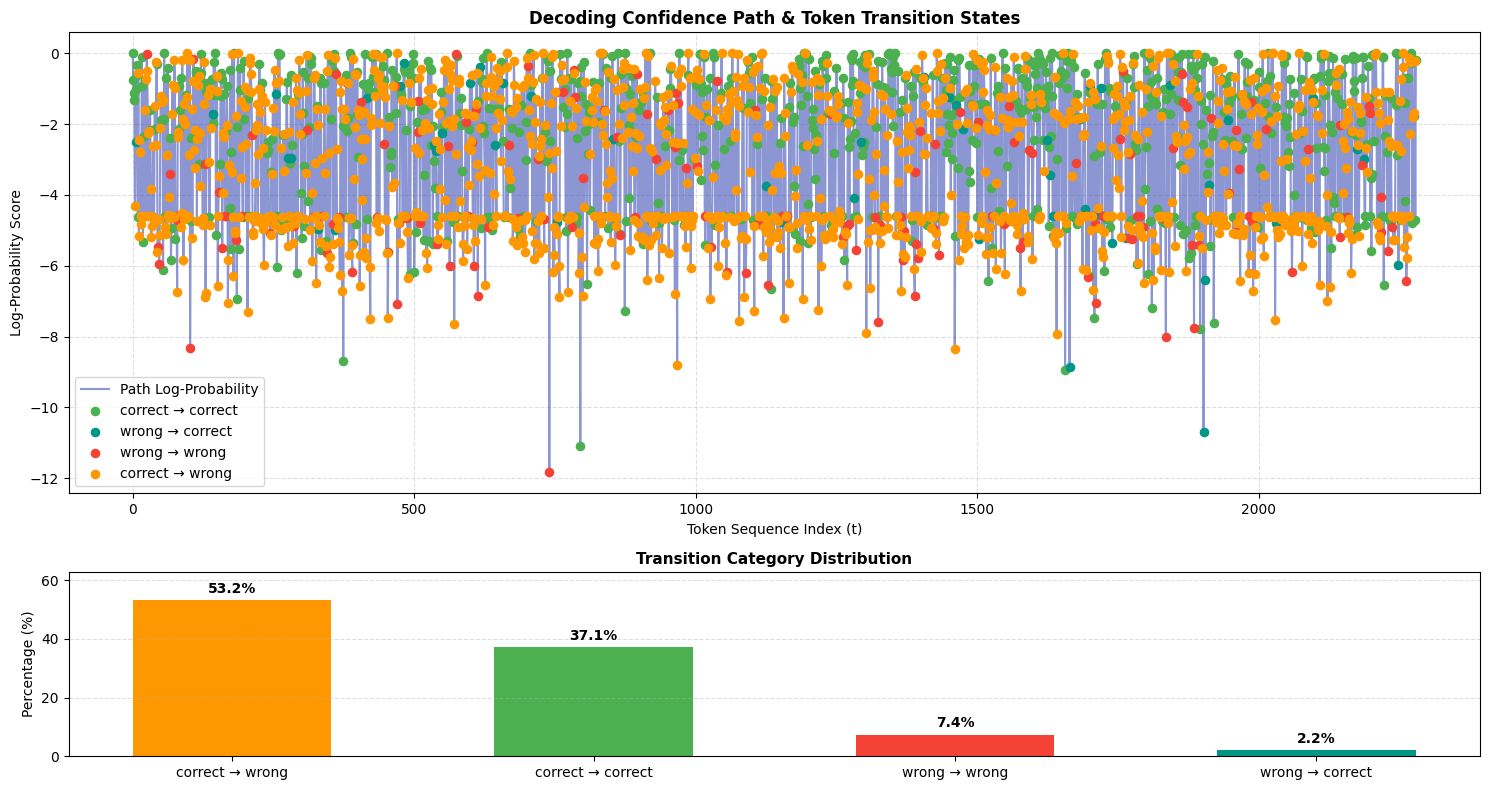

=====
T0 Random


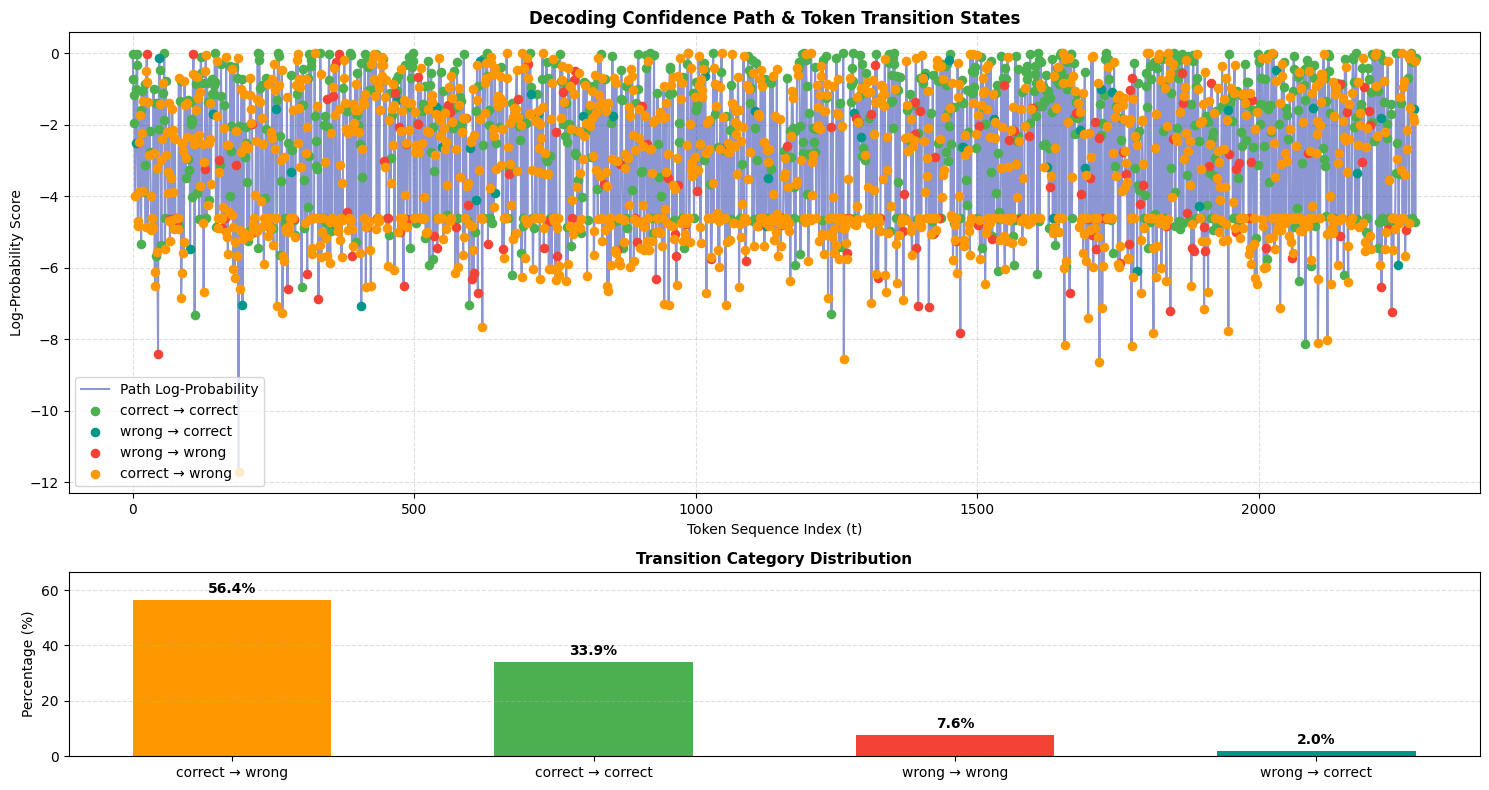

In [ ]:
print("""T = true_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2, epsilon=0.7, noise_scale=0.05)
A0 PRIOR""")
def calculate_accuracy(pred, target):
    return sum(1 for p, t in zip(pred, target) if p == t) / len(target) * 100

acc_noisy = calculate_accuracy(encoded_noisy_text, encoded_clean_text) #noisy text

# acc_true = calculate_accuracy(decoded_token_ids, encoded_clean_text) #using T_true
acc_t0  = calculate_accuracy(decoded_token_ids_T0, encoded_clean_text) #using T_0 good guess
acc_t0_random = calculate_accuracy(decoded_token_ids_T0_random, encoded_clean_text) #using T_0 random initial
# acc_t0_init = calculate_accuracy(decoded_token_ids_T0_initial, encoded_clean_text) #using T_0 initial
# acc_t0_uniform = calculate_accuracy(decoded_token_ids_T0_uniform, encoded_clean_text) #using T_0 uniform initial
# acc_t_inter = calculate_accuracy(decoded_token_ids_T_inter, encoded_clean_text)

print("=" * 60)
print(f"{'Decoding Method':<35} | {'Accuracy':<10}")
print("-" * 60)
print(f"{'1. Raw Noisy':<35} | {acc_noisy:.2f}%")
# print(f"{'2. True T':<35} | {acc_true:.2f}%")
print(f"{'3. Good T0':<35} | {acc_t0:.2f}%")
print(f"{'4. T0 Random':<35} | {acc_t0_random:.2f}%")
# print(f"{'4. T0 First Guess':<35} | {acc_t0_init:.2f}%")
# print(f"{'5. T0 uniform':<35} | {acc_t0_uniform:.2f}%")
# print(f"{'6. T Intermediate':<35} | {acc_t_inter:.2f}%")
print("=" * 60)

# print("T")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids
# )
print("=====")
print("T0")
visualize_token_diff(
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0
)

plot_confidence_vs_errors(
    sequence_log_probs = log_probs_T0,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0,
)

print("=====")

print("T0 Random")
visualize_token_diff(
    clean_tokens=encoded_clean_text, 
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_random
)

plot_confidence_vs_errors(
    sequence_log_probs= log_probs_T0_random,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_random,
)
# print("=====")
# print("T0 Initial")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids_T0_initial
# )
# print("=====")
# print("T0 Uniform")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids_T0_uniform
# )
# print("=====")
# print("T Intermediate")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids_T_inter
# )

Noisy PRIOR
Decoding Method                     | Accuracy  
------------------------------------------------------------
1. Raw Noisy                        | 90.35%
3. Good T0                          | 89.78%
4. T0 Random                        | 88.86%
=====
T0


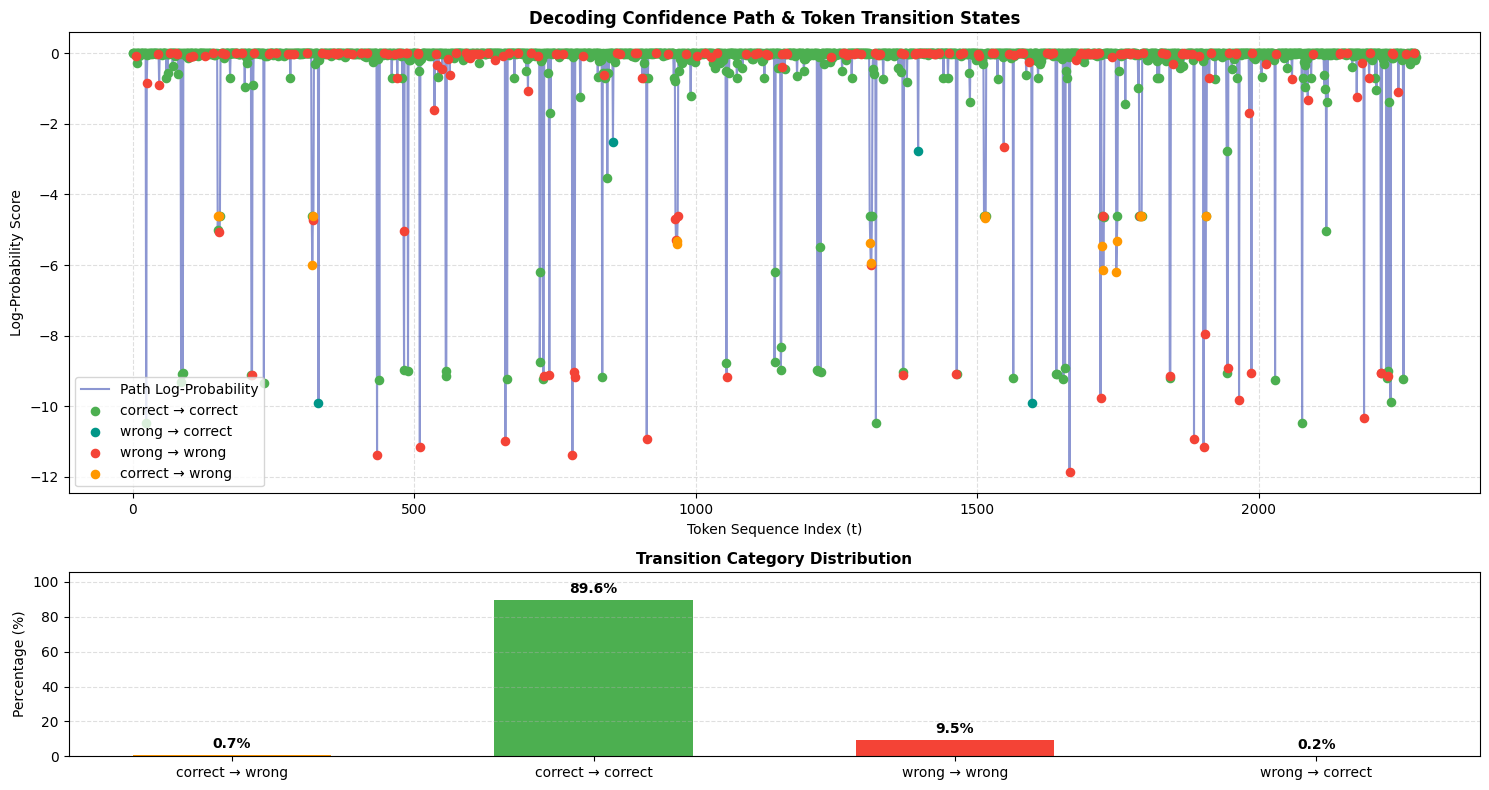

=====
T0 Random


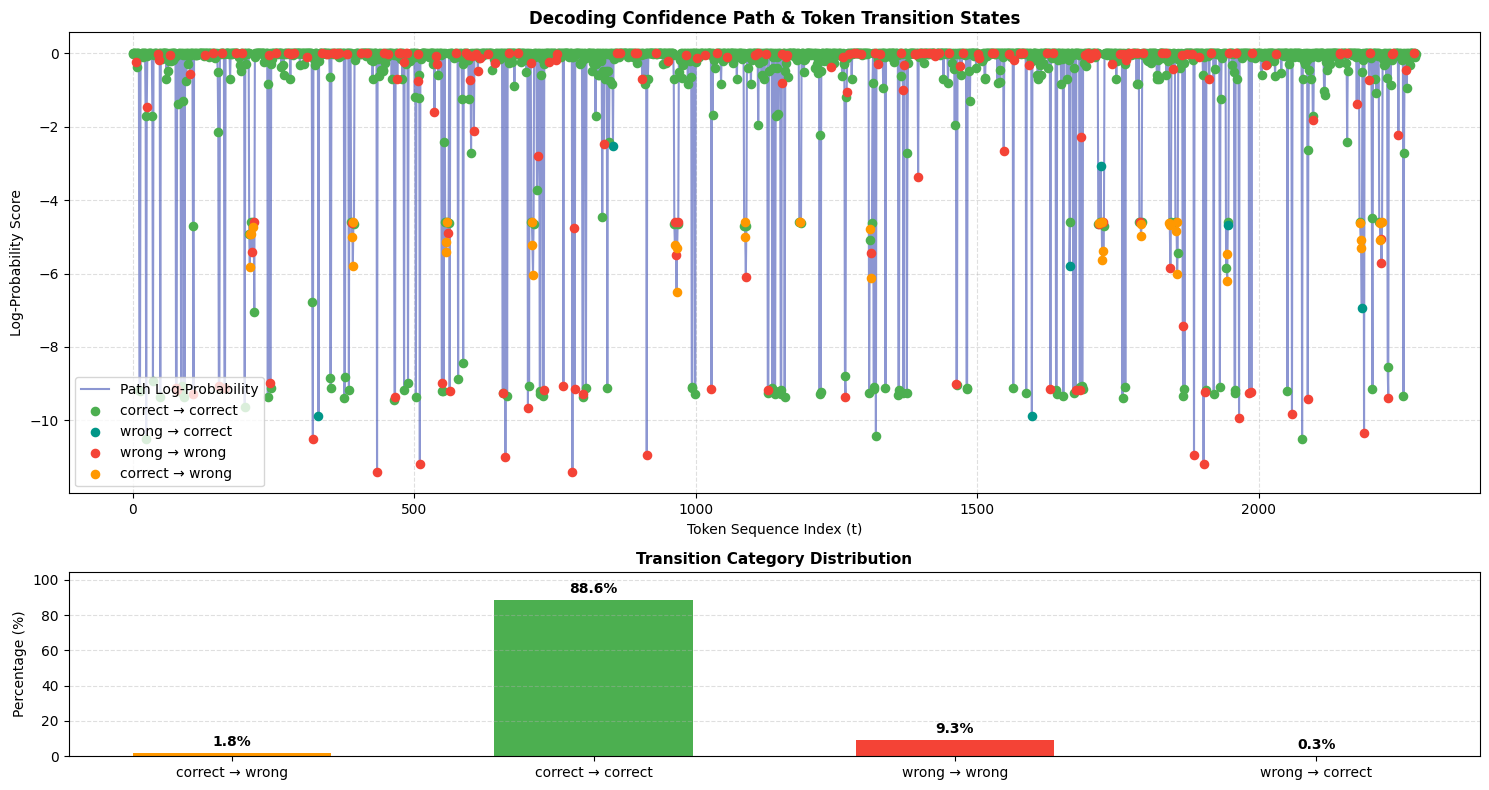

In [ ]:
print("""Noisy PRIOR""")
acc_noisy = calculate_accuracy(encoded_noisy_text, encoded_clean_text) #noisy text

acc_t0n  = calculate_accuracy(decoded_token_ids_T0n, encoded_clean_text) #using T_0 good guess
acc_t0_randomn = calculate_accuracy(decoded_token_ids_T0_randomn, encoded_clean_text) #using T_0 random initial


print("=" * 60)
print(f"{'Decoding Method':<35} | {'Accuracy':<10}")
print("-" * 60)
print(f"{'1. Raw Noisy':<35} | {acc_noisy:.2f}%")
# print(f"{'2. True T':<35} | {acc_true:.2f}%")
print(f"{'3. Good T0':<35} | {acc_t0n:.2f}%")
print(f"{'4. T0 Random':<35} | {acc_t0_randomn:.2f}%")
# print(f"{'4. T0 First Guess':<35} | {acc_t0_init:.2f}%")
# print(f"{'5. T0 uniform':<35} | {acc_t0_uniform:.2f}%")
# print(f"{'6. T Intermediate':<35} | {acc_t_inter:.2f}%")
print("=" * 60)

print("=====")
print("T0")
visualize_token_diff(
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0n
)

plot_confidence_vs_errors(
    sequence_log_probs= log_probs_T0n,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0n,
)

print("=====")

print("T0 Random")
visualize_token_diff(
    clean_tokens=encoded_clean_text, 
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_randomn
)

plot_confidence_vs_errors(
    sequence_log_probs= log_probs_T0_randomn,
    clean_tokens=encoded_clean_text,
    noisy_tokens=initial_sequence_guess,
    decoded_tokens=decoded_token_ids_T0_randomn,
)

In [ ]:
# T = true_error_matrix(vocab, deletion_table, alpha=0.5, max_dist=2, epsilon=0.9, noise_scale=0.05)
# T = sanitize_matrix_dict(T)
# T_inv = build_inverse_T(T)
# T0 = t0_error_matrix(vocab, deletion_table, alpha=0.1, max_dist=2)
# T0_random = t0_random_matrix(vocab, deletion_table, max_dist=2)
# T0_uniform = t0_uniform_matrix(vocab, deletion_table, max_dist=2)
# T0_inv = build_inverse_T(T0)
# T0_inv_random = build_inverse_T(T0_random)
# T0_inv_uniform = build_inverse_T(T0_uniform)


# num_source_tokens = len(T)
# total_connections = sum(len(transitions) for transitions in T.values())
# avg_candidates = total_connections / num_source_tokens if num_source_tokens > 0 else 0

# print(f"=========================================================")
# print(f"Matrix T")
# print(f"=========================================================")
# print(f"Total Unique True Tokens (Rows)   : {num_source_tokens:,}")
# print(f"Total Non-Zero Transitions (Cells): {total_connections:,}")
# print(f"Avg Candidates per Token (Density): {avg_candidates:.2f}")
# print(f"=========================================================")

# # --------------------------------------------

# num_source_tokens = len(T0)
# total_connections = sum(len(transitions) for transitions in T0.values())
# avg_candidates = total_connections / num_source_tokens if num_source_tokens > 0 else 0

# # print(f"=========================================================")
# print(f"Matrix T0")
# print(f"=========================================================")
# print(f"Total Unique True Tokens (Rows)   : {num_source_tokens:,}")
# print(f"Total Non-Zero Transitions (Cells): {total_connections:,}")
# print(f"Avg Candidates per Token (Density): {avg_candidates:.2f}")
# print(f"=========================================================")

In [ ]:
# encoded_noisy_text = generate_noise(short, T)
# # test_corpus
# encoded_clean_text = list(encode(short))

# initial_sequence_guess = list(encoded_noisy_text)

# history = []

# T_intermediate = compute_intermediate_matrix(encoded_clean_text, encoded_noisy_text)

# alpha_start = 0.01
# alpha_end = 0.0001
# num_iter = 10000

# estimated_T_dict_t0, history_t0 = train_saem_pure_pt(
#     encoded_initial=initial_sequence_guess, 
#     encoded_noisy=encoded_noisy_text, 
#     prior_matrix=probs_matrix, 
#     initial_T=T0,
#     T_true=T, 
#     T_intermediate=T_intermediate,
#     T0_inv=T0_inv,
#     alpha_start=alpha_start,
#     alpha_end=alpha_end, 
#     num_iterations=num_iter
# )

# plot_saem(history_t0, alpha_start, alpha_end, title="T0")
# plot_saem_distance(history_t0, alpha_start, alpha_end, title="T0")

# estimated_T_dict_t0_random, history_t0_random = train_saem_pure_pt(
#     encoded_initial=initial_sequence_guess, 
#     encoded_noisy=encoded_noisy_text, 
#     prior_matrix=probs_matrix, 
#     initial_T=T0_random,
#     T_true=T, 
#     T_intermediate=T_intermediate,
#     T0_inv=T0_inv_random,
#     alpha_start=alpha_start,
#     alpha_end=alpha_end, 
#     num_iterations=num_iter
# )

# plot_saem(history_t0_random, alpha_start, alpha_end, title="T0_random")
# plot_saem_distance(history_t0_random, alpha_start, alpha_end, title="T0_random")

# # estimated_T_dict_t0_uniform, history_t0_uniform = train_saem_pure_pt(
# #     encoded_initial=initial_sequence_guess, 
# #     encoded_noisy=encoded_noisy_text, 
# #     prior_matrix=probs_matrix, 
# #     initial_T=T0_uniform,
# #     T_true=T, 
# #     T_intermediate=T_intermediate,
# #     T0_inv=T0_inv_uniform,
# #     alpha_start=alpha_start,
# #     alpha_end=alpha_end, 
# #     num_iterations=num_iter
# # )

# # plot_saem(history_t0_uniform, alpha_start, alpha_end, title="T0_uniform")
# # plot_saem_distance(history_t0_uniform, alpha_start, alpha_end, title="T0_uniform")

# sweep_results = {}

# sweep_results['T0'] = {
#     'true_l1': history_t0['true_l1'][-1],
#     'true_l2': history_t0['true_l2'][-1],
#     'true_hellinger': history_t0['true_hellinger'][-1],
#     'int_l1': history_t0['int_l1'][-1],
#     'int_l2': history_t0['int_l2'][-1],
#     'int_hellinger': history_t0['int_hellinger'][-1],
#     'nonzero_l1': history_t0['nonzero_l1'][-1],
#     'nonzero_l2': history_t0['nonzero_l2'][-1],
#     'nonzero_hellinger': history_t0['nonzero_hel'][-1]
# }

# sweep_results['T0_random'] = {
#     'true_l1': history_t0_random['true_l1'][-1],
#     'true_l2': history_t0_random['true_l2'][-1],
#     'true_hellinger': history_t0_random['true_hellinger'][-1],
#     'int_l1': history_t0_random['int_l1'][-1],
#     'int_l2': history_t0_random['int_l2'][-1],
#     'int_hellinger': history_t0_random['int_hellinger'][-1],
#     'nonzero_l1': history_t0_random['nonzero_l1'][-1],
#     'nonzero_l2': history_t0_random['nonzero_l2'][-1],
#     'nonzero_hellinger': history_t0_random['nonzero_hel'][-1]
# }

# # sweep_results['T0_uniform'] = {
# #     'true_l1': history_t0_uniform['true_l1'][-1],
# #     'true_l2': history_t0_uniform['true_l2'][-1],
# #     'true_hellinger': history_t0_uniform['true_hellinger'][-1],
# #     'int_l1': history_t0_uniform['int_l1'][-1],
# #     'int_l2': history_t0_uniform['int_l2'][-1],
# #     'int_hellinger': history_t0_uniform['int_hellinger'][-1],
# #     'nonzero_l1': history_t0_uniform['nonzero_l1'][-1],
# #     'nonzero_l2': history_t0_uniform['nonzero_l2'][-1],
# #     'nonzero_hellinger': history_t0_uniform['nonzero_hel'][-1]
# # }

# plot_alpha_metric_comparison(sweep_results)

In [ ]:
# decoded_token_ids_T0 = belief_propagation_decode(
#     noisy_tokens=encoded_noisy_text, 
#     T_matrix=estimated_T_dict_t0,
#     prior_matrix=probs_matrix, 
#     vocab=vocab
# )

# decoded_token_ids_T0_random = belief_propagation_decode(
#     noisy_tokens=encoded_noisy_text, 
#     T_matrix=estimated_T_dict_t0_random,
#     prior_matrix=probs_matrix, 
#     vocab=vocab
# )

In [ ]:
# print("""T = true_error_matrix(vocab, deletion_table, alpha=0.5, max_dist=2, epsilon=0.9, noise_scale=0.05)""")

# acc_noisy = calculate_accuracy(encoded_noisy_text, encoded_clean_text) #noisy text
# acc_t0  = calculate_accuracy(decoded_token_ids_T0, encoded_clean_text) #using T_0 good guess
# acc_t0_random = calculate_accuracy(decoded_token_ids_T0_random, encoded_clean_text) #using T_0 random initial

# print("=" * 60)
# print(f"{'Decoding Method':<35} | {'Accuracy':<10}")
# print("-" * 60)
# print(f"{'1. Raw Noisy':<35} | {acc_noisy:.2f}%")
# # print(f"{'2. True T':<35} | {acc_true:.2f}%")
# print(f"{'3. Good T0':<35} | {acc_t0:.2f}%")
# print(f"{'4. T0 Random':<35} | {acc_t0_random:.2f}%")
# # print(f"{'5. T0 uniform':<35} | {acc_t0_uniform:.2f}%")
# # print(f"{'6. T Intermediate':<35} | {acc_t_inter:.2f}%")
# print("=" * 60)


# print(short)
# print("T0")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids_T0
# )
# print("=====")
# print("T0 Random")
# visualize_token_diff(
#     clean_tokens=encoded_clean_text, 
#     decoded_tokens=decoded_token_ids_T0_random
# )